# Task 6: Per-index EDA — raw data (`data/raw/`)
part 1 of 3 (raw → [interim](eda_interim.ipynb) → [processed](eda_processed.ipynb))

**Goal:** understand each raw input *before* it is merged. For every file: is it complete and
well-formed, what does its distribution look like, which occupations does it cover, and what will
go wrong when it is joined to the others?

**Reads:** the files in `data/raw/`, plus `data/frey_osborne_probabilities.csv` for one comparison and the
Milestone 1 index tables in `data/interim/` for O\*NET and BLS code coverage.
**Writes:** figures to `notebooks/figures/`. Raw files are never modified.

| Part | File | What it is |
|---|---|---|
| 1 | `soc_2010_to_2018_crosswalk.xlsx` | BLS mapping between SOC 2010 and SOC 2018 codes |
| 2 | `occ_level.csv` | Eloundou et al. (GPTs are GPTs) LLM exposure ratings per O\*NET occupation |
| 3 | `AIOE_DataAppendix.xlsx` | Felten, Raj & Seamans AI Occupational Exposure (AIOE), SOC 2010 |
| 4 | `The_Future_of_Employment.pdf` | Frey & Osborne probability of computerisation, SOC 2010 (appendix table) |
| 5 | O\*NET 30.3: `abilities`, `essential_skills`, `transferable_skills`, `work_activities`, `work_context`, `job_zones` | Occupational features for the disagreement-drivers model, O\*NET-SOC 2019 |
| 6 | `occupation.xlsx` | BLS Employment Projections 2025-35: employment, projected change, wages and entry requirements, SOC 2018 |

**Analysis decisions**
- **One headline score per index:** Eloundou `dv_rating_beta` (the paper's headline measure; the GPT-4
  rater, which tracks the human raters closely on beta), `AIOE`, and Frey-Osborne `probability`. The other
  Eloundou columns are profiled but not ranked.
- **"Outlier" means two different things here.** For continuous scores we use the 1.5×IQR rule. For the
  crosswalk (a mapping) and Frey-Osborne (a bimodal probability) that rule does not fit, so outliers are
  *structural*: splits, merges, and codes that fail to match.
- **Trends are read by SOC major group** (first two digits of the code), labelled with BLS names.
- **Nothing is fixed in this notebook.** Problems are documented with a recommendation rather than
  patched, so it stays a faithful picture of the inputs.

Each part ends with a summary (general trends, merging, outliers) and a table of the EDA techniques used.

## Setup

Works in **Google Colab** and **locally**:
- **Colab:** mounts Google Drive and reads from the team folder
  `MyDrive/BTT Fall AI Studio (swytch 1b)/data/` (the same folder `Milestone_1.ipynb` uses). If the folder was
  shared with you, add a shortcut to it in *My Drive* first. Any file missing from Drive is downloaded
  from the GitHub repo instead, so the notebook still runs without Drive access.
- **Locally:** reads `data/` from the repo (run from anywhere inside the repo with the project `.venv`).

In [1]:
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.width", 250)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 70)

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/BTT Fall AI Studio (swytch 1b)")
else:
    # Repo root = nearest folder (this one or above) that contains data/, so any notebooks/ subfolder works
    ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir()), Path.cwd())

DATA = ROOT / "data"
# Fallback source for files not found under DATA (switch the branch to main once this is merged)
GITHUB_DATA = "https://raw.githubusercontent.com/Break-Through-Tech/Swytch-1B-do-ai-job-risk-indices-agree/kamsi/data"
print("data folder:", DATA, "(found)" if DATA.exists() else "(not found, using GitHub)")


def data_file(rel):
    """Path to data/<rel>: from Drive / the repo if present, else downloaded once from GitHub."""
    path = DATA / rel
    if path.exists():
        return path
    cached = Path(tempfile.gettempdir()) / "swytch_data" / rel
    if not cached.exists():
        cached.parent.mkdir(parents=True, exist_ok=True)
        print(f"downloading {rel} from GitHub")
        urllib.request.urlretrieve(f"{GITHUB_DATA}/{rel}", cached)
    return cached


OUT = (ROOT if ROOT.exists() else Path.cwd()) / "notebooks" / "figures"
OUT.mkdir(parents=True, exist_ok=True)

MAJOR_GROUPS = {
    "11": "Management", "13": "Business & Financial", "15": "Computer & Mathematical",
    "17": "Architecture & Engineering", "19": "Life, Physical & Social Sci.",
    "21": "Community & Social Service", "23": "Legal", "25": "Education & Library",
    "27": "Arts, Design & Media", "29": "Healthcare Practitioners", "31": "Healthcare Support",
    "33": "Protective Service", "35": "Food Preparation & Serving", "37": "Building & Grounds",
    "39": "Personal Care & Service", "41": "Sales", "43": "Office & Admin Support",
    "45": "Farming, Fishing & Forestry", "47": "Construction & Extraction",
    "49": "Installation & Repair", "51": "Production", "53": "Transportation & Material Moving",
    "55": "Military",
}


def boxplot_by_group(df, code_col, value_col, title):
    """Horizontal boxplot of value_col per SOC major group, sorted by median."""
    groups = df.assign(mg=df[code_col].str[:2]).groupby("mg")[value_col]
    order = groups.median().sort_values().index
    data = [groups.get_group(g) for g in order]
    fig, ax = plt.subplots(figsize=(8, 7))
    try:
        ax.boxplot(data, orientation="horizontal")  # matplotlib >= 3.10
    except TypeError:
        ax.boxplot(data, vert=False)
    ax.set_yticks(range(1, len(order) + 1), [f"{g} {MAJOR_GROUPS[g]}" for g in order])
    ax.set_xlabel(value_col)
    ax.set_title(title, loc="left")
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    plt.show()


def load_crosswalk():
    """BLS SOC 2010 -> 2018 crosswalk with short column names."""
    cw = pd.read_excel(data_file("raw/soc_2010_to_2018_crosswalk.xlsx"), header=8, dtype=str)
    cw.columns = ["soc10", "title10", "soc18", "title18"]
    return cw.apply(lambda s: s.str.strip())

data folder: C:\Users\Kamsi\Downloads\code\Swytch-1B-do-ai-job-risk-indices-agree\data (found)


## Part 1 — SOC 2010 → 2018 crosswalk (`soc_2010_to_2018_crosswalk.xlsx`)

### 1. Load + integrity checks

In [2]:
cw = pd.read_excel(data_file("raw/soc_2010_to_2018_crosswalk.xlsx"), header=8, dtype=str)
cw.columns = ["soc10", "title10", "soc18", "title18"]
cw = cw.apply(lambda s: s.str.strip())

print("rows:", len(cw))
print("nulls:", cw.isna().sum().to_dict())
print("duplicate rows:", cw.duplicated().sum())
for c in ["soc10", "soc18"]:
    assert cw[c].str.fullmatch(r"\d{2}-\d{4}").all(), f"bad code format in {c}"

n_soc10, n_soc18 = cw.soc10.nunique(), cw.soc18.nunique()
print("unique 2010 codes:", n_soc10, "| unique 2018 codes:", n_soc18)
# The published SOC structures have exactly 840 (2010) and 867 (2018) detailed occupations,
# so the crosswalk is complete on both sides: no orphan codes.
assert (n_soc10, n_soc18) == (840, 867)

rows: 900
nulls: {'soc10': 0, 'title10': 0, 'soc18': 0, 'title18': 0}
duplicate rows: 0
unique 2010 codes: 840 | unique 2018 codes: 867


### 2. Classify each code (per code, not per row)
A row-level label double-counts: one 2010 code can feed both a clean split and a merge.
So classify each code on its own side:
 - 2010 code: `1:1`, `split` (fans out, no destination shared), `into merge` (single destination shared with others), `split + merge` (fans out and some destination is shared)
 - 2018 code: mirror image.

In [3]:
cw["fanout"] = cw.groupby("soc10").soc18.transform("nunique")  # 2018 codes per 2010 code
cw["fanin"] = cw.groupby("soc18").soc10.transform("nunique")   # 2010 codes per 2018 code


def classify(df, key, own, other):
    g = df.groupby(key).agg(own=(own, "max"), other_max=(other, "max"))
    many_own, many_other = g.own > 1, g.other_max > 1
    return pd.Series(
        pd.Categorical(
            [
                "1:1" if not a and not b else "split" if a and not b else
                "into merge" if b and not a else "split + merge"
                for a, b in zip(many_own, many_other)
            ],
            categories=["1:1", "split", "into merge", "split + merge"],
        ),
        index=g.index,
    )


type10 = classify(cw, "soc10", "fanout", "fanin")
type18 = classify(cw.rename(columns={"fanin": "a", "fanout": "b"}), "soc18", "a", "b")
type18 = type18.cat.rename_categories({"split": "merge", "into merge": "from split",
                                       "split + merge": "merge + split"})

summary10 = type10.value_counts().sort_index()
summary18 = type18.value_counts().sort_index()
assert summary10.sum() == n_soc10 and summary18.sum() == n_soc18
print("2010 codes by type:\n", summary10.to_string(), "\n")
print("2018 codes by type:\n", summary18.to_string())

2010 codes by type:
 1:1              766
split             18
into merge        32
split + merge     24 

2018 codes by type:
 1:1              766
merge             11
from split        70
merge + split     20


**1:1 is not the same as unchanged.** Break the 1:1 codes down further: same code and
title, same code but renamed, or a new code (pure recode).

In [4]:
cw["title18_clean"] = cw.title18.str.replace(r"\s*\(#+\)\s*$", "", regex=True)
cw["title10_clean"] = cw.title10.str.replace(r"\s*\(#+\)\s*$", "", regex=True)
one = cw[cw.soc10.map(type10) == "1:1"].copy()
one["kind"] = "unchanged"
one.loc[(one.soc10 == one.soc18) & (one.title10_clean != one.title18_clean), "kind"] = "renamed, same code"
one.loc[one.soc10 != one.soc18, "kind"] = "recoded"
print(one.kind.value_counts().to_string())

kind
unchanged             681
renamed, same code     48
recoded                37


In [5]:
# Pure recodes: joining on raw code silently drops these (e.g. the whole physician block,
# nursing/home-health aides, most computer occupations).
one.loc[one.kind == "recoded", ["soc10", "title10", "soc18", "title18"]]

,soc10,title10,soc18,title18
26,11-9061,Funeral Service Managers,11-9171,Funeral Home Managers
75,15-1111,Computer and Information Research Scientists,15-1221,Computer and Information Research Scientists
76,15-1121,Computer Systems Analysts,15-1211,Computer Systems Analysts
77,15-1122,Information Security Analysts,15-1212,Information Security Analysts
78,15-1131,Computer Programmers,15-1251,Computer Programmers
87,15-1142,Network and Computer Systems Administrators,15-1244,Network and Computer Systems Administrators
88,15-1143,Computer Network Architects,15-1241,Computer Network Architects
89,15-1151,Computer User Support Specialists,15-1232,Computer User Support Specialists
90,15-1152,Computer Network Support Specialists,15-1231,Computer Network Support Specialists
181,19-4091,"Environmental Science and Protection Technicians, Including Health",19-4042,"Environmental Science and Protection Technicians, Including Health"


In [6]:
one.loc[one.kind == "renamed, same code", ["soc10", "title10", "title18"]]

,soc10,title10,title18
20,11-9031,"Education Administrators, Preschool and Childcare Center/Program","Education and Childcare Administrators, Preschool and Daycare"
21,11-9032,"Education Administrators, Elementary and Secondary School","Education Administrators, Kindergarten through Secondary"
27,11-9071,Gaming Managers,Gambling Managers
109,17-2031,Biomedical Engineers,Bioengineers and Biomedical Engineers
129,17-3021,Aerospace Engineering and Operations Technicians,Aerospace Engineering and Operations Technologists and Technicians
130,17-3022,Civil Engineering Technicians,Civil Engineering Technologists and Technicians
131,17-3023,Electrical and Electronics Engineering Technicians,Electrical and Electronic Engineering Technologists and Technicians
132,17-3024,Electro-Mechanical Technicians,Electro-Mechanical and Mechatronics Technologists and Technicians
133,17-3025,Environmental Engineering Technicians,Environmental Engineering Technologists and Technicians
134,17-3026,Industrial Engineering Technicians,Industrial Engineering Technologists and Technicians


### 3. Validate the BLS flags
In this file `(#)` is appended to **2010** titles that are split, and `(##)` to **2018**
titles formed by a merge. (DATA-DICTIONARY 2.4 describes `#` as marking the 2018 side;
the file puts it on the 2010 side.) Check they agree exactly with the computed structure.

In [7]:
cw["flag10"] = cw.title10.str.contains(r"\(#\)")
cw["flag18"] = cw.title18.str.contains(r"\(##\)")
print(pd.crosstab(cw.flag10, cw.fanout > 1, rownames=["(#) on 2010 title"], colnames=["2010 code splits"]))
print(pd.crosstab(cw.flag18, cw.fanin > 1, rownames=["(##) on 2018 title"], colnames=["2018 code is a merge"]))
assert (cw.flag10 == (cw.fanout > 1)).all() and (cw.flag18 == (cw.fanin > 1)).all()

2010 code splits   False  True 
(#) on 2010 title              
False                798      0
True                   0    102
2018 code is a merge  False  True 
(##) on 2018 title                
False                   836      0
True                      0     64


### 4. Trends by major group
Stability = share of a major group's 2010 codes that map 1:1. Occupations *in* each 2018
major group are counted on the 2018 side (codes can change major group).

In [8]:
cw["mg10"], cw["mg18"] = cw.soc10.str[:2], cw.soc18.str[:2]
codes10 = cw.drop_duplicates("soc10").assign(type=lambda d: d.soc10.map(type10))
by_mg = pd.DataFrame({
    "codes_2010": codes10.groupby("mg10").size(),
    "codes_2018": cw.drop_duplicates("soc18").groupby("mg18").size(),
    "one_to_one_2010": codes10[codes10.type == "1:1"].groupby("mg10").size(),
}).fillna(0).astype(int)
by_mg["net_change"] = by_mg.codes_2018 - by_mg.codes_2010
by_mg["pct_1to1"] = (by_mg.one_to_one_2010 / by_mg.codes_2010).round(2)
by_mg.sort_values("pct_1to1")

,codes_2010,codes_2018,one_to_one_2010,net_change,pct_1to1
15,19,21,12,2,0.63
53,52,53,42,1,0.81
27,41,41,34,0,0.83
29,61,72,53,11,0.87
45,15,14,13,-1,0.87
13,32,35,28,3,0.88
39,33,33,29,0,0.88
35,18,17,16,-1,0.89
33,22,24,20,2,0.91
19,43,48,39,5,0.91


In [9]:
# "All Other" residual codes carry most of the churn.
res = codes10.assign(residual=codes10.title10.str.contains("All Other"))
pd.crosstab(res.residual, res.type, margins=True)

type,1:1,split,into merge,split + merge,All
residual,,,,,
False,717,9,27,13,766
True,49,9,5,11,74
All,766,18,32,24,840


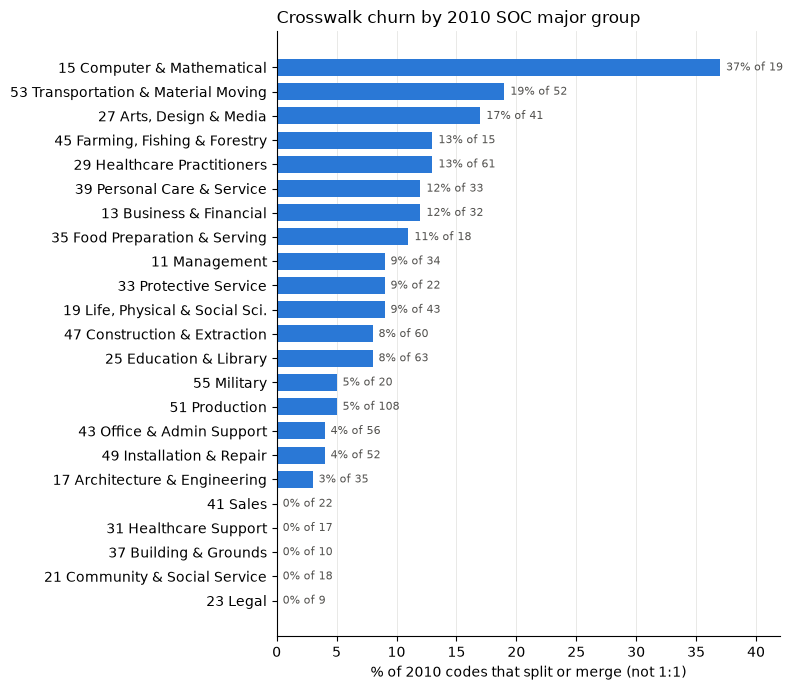

In [10]:
# Plot the complement (% changed) so the unstable groups are the long bars.
plot = by_mg.assign(pct_changed=1 - by_mg.pct_1to1).sort_values("pct_changed")
labels = [f"{mg} {MAJOR_GROUPS[mg]}" for mg in plot.index]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(labels, plot.pct_changed * 100, color="#2a78d6", height=0.7)
for y, (v, n) in enumerate(zip(plot.pct_changed, plot.codes_2010)):
    ax.text(v * 100 + 0.5, y, f"{v:.0%} of {n}", va="center", fontsize=8, color="#52514e")
ax.set_xlim(0, 42)
ax.set_xlabel("% of 2010 codes that split or merge (not 1:1)")
ax.set_title("Crosswalk churn by 2010 SOC major group", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#e5e5e3", linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(OUT / "crosswalk_churn_by_major_group.png", dpi=150)

### 5. Structural outliers

In [11]:
# Largest fan-out (one 2010 occupation -> many 2018 occupations)
fan_out = cw.groupby(["soc10", "title10"]).soc18.nunique().sort_values(ascending=False)
fan_out[fan_out > 2]

soc10    title10                                                                                       
29-1069  Physicians and Surgeons, All Other (#)                                                            8
15-1199  Computer Occupations, All Other (#)                                                               5
11-9199  Managers, All Other (#)                                                                           4
25-3099  Teachers and Instructors, All Other (#)                                                           3
29-1067  Surgeons (#)                                                                                      3
25-9041  Teacher Assistants (#)                                                                            3
29-9099  Healthcare Practitioners and Technical Workers, All Other (#)                                     3
39-1021  First-Line Supervisors of Personal Service Workers (#)                                            3
51-9199  Production Work

In [12]:
cw.loc[cw.soc10 == fan_out.index[0][0], ["soc18", "title18"]]

,soc18,title18
342,29-1212,Cardiologists
343,29-1213,Dermatologists
344,29-1214,Emergency Medicine Physicians
345,29-1217,Neurologists
346,29-1222,"Physicians, Pathologists"
347,29-1224,Radiologists
348,29-1229,"Physicians, All Other"
349,29-1241,"Ophthalmologists, Except Pediatric"


In [13]:
# Largest fan-in (many 2010 occupations -> one 2018 occupation)
fan_in = cw.groupby(["soc18", "title18"]).soc10.nunique().sort_values(ascending=False)
fan_in[fan_in > 1].head(10)

soc18    title18                                                                   
13-1082  Project Management Specialists (##)                                           3
15-1253  Software Quality Assurance Analysts and Testers (##)                          3
15-1299  Computer Occupations, All Other (##)                                          2
29-9021  Health Information Technologists and Medical Registrars (##)                  2
27-3023  News Analysts, Reporters, and Journalists (##)                                2
27-3099  Media and Communication Workers, All Other (##)                               2
19-4044  Hydrologic Technicians (##)                                                   2
17-3029  Engineering Technologists and Technicians, Except Drafters, All Other (##)    2
13-2054  Financial Risk Specialists (##)                                               2
15-1243  Database Architects (##)                                                      2
Name: soc10, dtype: int64

In [14]:
# Many-to-many tangles: rows where the 2010 code splits AND the 2018 code is a merge.
cw.loc[(cw.fanout > 1) & (cw.fanin > 1), ["soc10", "title10", "soc18", "title18"]]

,soc10,title10,soc18,title18
38,11-9199,"Managers, All Other (#)",13-1082,Project Management Specialists (##)
57,13-1199,"Business Operations Specialists, All Other (#)",13-1082,Project Management Specialists (##)
65,13-2051,Financial Analysts (#),13-2054,Financial Risk Specialists (##)
73,13-2099,"Financial Specialists, All Other (#)",13-2054,Financial Risk Specialists (##)
79,15-1132,"Software Developers, Applications (#)",15-1252,Software Developers (##)
80,15-1132,"Software Developers, Applications (#)",15-1253,Software Quality Assurance Analysts and Testers (##)
81,15-1133,"Software Developers, Systems Software (#)",15-1252,Software Developers (##)
82,15-1133,"Software Developers, Systems Software (#)",15-1253,Software Quality Assurance Analysts and Testers (##)
84,15-1134,Web Developers (#),15-1255,Web and Digital Interface Designers (##)
86,15-1141,Database Administrators (#),15-1243,Database Architects (##)


In [15]:
# Codes that move to a different major group
cw.loc[cw.mg10 != cw.mg18, ["soc10", "title10", "soc18", "title18"]]

,soc10,title10,soc18,title18
38,11-9199,"Managers, All Other (#)",13-1082,Project Management Specialists (##)
91,15-1199,"Computer Occupations, All Other (#)",13-1082,Project Management Specialists (##)
210,23-2091,Court Reporters,27-3092,Court Reporters and Simultaneous Captioners
317,27-4013,Radio Operators,43-2099,"Communications Equipment Operators, All Other (##)"
393,29-9011,Occupational Health and Safety Specialists,19-5011,Occupational Health and Safety Specialists
394,29-9012,Occupational Health and Safety Technicians,19-5012,Occupational Health and Safety Technicians
473,39-1021,First-Line Supervisors of Personal Service Workers (#),53-1044,First-line Supervisors of Passenger Attendants (##)
499,39-9021,Personal Care Aides,31-1122,Personal Care Aides
566,43-5081,Stock Clerks and Order Fillers,53-7065,Stockers and Order Fillers
572,43-9011,Computer Operators,15-1299,"Computer Occupations, All Other (##)"


### 6. What this means for the index merge
Frey-Osborne is keyed to 2010 SOC; Eloundou (O*NET-SOC 2019) rolls up to 2018 SOC.

> **Note (added with Part 4):** `data/frey_osborne_probabilities.csv` used in this section is a
> 653-row subset of the 702 occupations in the Frey & Osborne appendix. 49 occupations are missing
> from it, 32 of which are valid SOC 2010 codes (e.g. Judges, Dancers, Team Assemblers). The
> pipeline (Milestone 1, Task 3b) parses the PDF directly, so counts here slightly understate
> Frey-Osborne coverage. See Part 4, section 5.

In [16]:
fo = pd.read_csv(data_file("frey_osborne_probabilities.csv"), dtype={"soc_code_2010": str})
elo = pd.read_csv(data_file("raw/occ_level.csv"))
elo6 = elo["O*NET-SOC Code"].str[:7].unique()

fo_codes = set(fo.soc_code_2010)
print("FO codes:", len(fo_codes), "| not in crosswalk 2010 side:", len(fo_codes - set(cw.soc10)))
print("FO codes by mapping type:\n", type10[type10.index.isin(fo_codes)].value_counts().sort_index().to_string())

# 2018 codes reachable from at least one FO-scored 2010 code
fo18 = set(cw.loc[cw.soc10.isin(fo_codes), "soc18"])
print("\n2018 codes with an FO ancestor:", len(fo18), "of", n_soc18)

elo_set = set(elo6)
print("Eloundou six-digit codes:", len(elo_set), "| not in crosswalk 2018 side:",
      len(elo_set - set(cw.soc18)))
both = fo18 & elo_set
print("2018 codes with both FO and Eloundou:", len(both))

FO codes: 653 | not in crosswalk 2010 side: 0
FO codes by mapping type:
 1:1              608
split              8
into merge        21
split + merge     16

2018 codes with an FO ancestor: 668 of 867
Eloundou six-digit codes: 798 | not in crosswalk 2018 side: 0
2018 codes with both FO and Eloundou: 663


In [17]:
# 2018 codes scored by Eloundou whose FO value would have to come through a split or merge
# (provenance flag candidates), and 2018 codes with a partial FO ancestry in merges.
cw_fo = cw.assign(has_fo=cw.soc10.isin(fo_codes))
partial = cw_fo.groupby("soc18").has_fo.agg(["sum", "size"])
partial = partial[(partial["sum"] > 0) & (partial["sum"] < partial["size"])]
print("2018 merges where only some 2010 ancestors have an FO score:", len(partial))
inherited = cw_fo[cw_fo.has_fo & cw_fo.soc18.isin(elo_set) & ((cw_fo.fanout > 1) | (cw_fo.fanin > 1))]
print("Eloundou-scored 2018 codes whose FO value comes through a split/merge:", inherited.soc18.nunique())
print(partial.rename(columns={"sum": "ancestors_with_fo", "size": "ancestors"})
      .join(cw.drop_duplicates("soc18").set_index("soc18").title18))

2018 merges where only some 2010 ancestors have an FO score: 15
Eloundou-scored 2018 codes whose FO value comes through a split/merge: 55
         ancestors_with_fo  ancestors                                                                title18
soc18                                                                                                       
13-1082                  2          3                                    Project Management Specialists (##)
15-1243                  1          2                                               Database Architects (##)
15-1253                  2          3                   Software Quality Assurance Analysts and Testers (##)
15-1299                  1          2                                   Computer Occupations, All Other (##)
17-3029                  1          2  Engineering Technologists and Technicians, Except Drafters, All Ot...
27-3099                  1          2                        Media and Communication Workers, All O

In [18]:
# Value-conflict outliers: merges whose 2010 ancestors disagree on FO probability.
# Whatever aggregation rule the team picks (mean, employment-weighted, max) decides these scores.
m = cw.merge(fo, left_on="soc10", right_on="soc_code_2010", how="left")
spread = (m.groupby(["soc18", "title18"]).fo_computerization_probability.agg(["count", "min", "max"])
          .query("count > 1").assign(spread=lambda d: d["max"] - d["min"])
          .sort_values("spread", ascending=False))
spread.head(15)

,,count,min,max,spread
soc18,title18,,,,
47-5032,"Explosives Workers, Ordnance Handling Experts, and Blasters (##)",2,0.480,0.85,0.370
19-4044,Hydrologic Technicians (##),2,0.610,0.91,0.300
25-4022,Librarians and Media Collections Specialists (##),2,0.390,0.65,0.260
51-9124,"Coating, Painting, and Spraying Machine Setters, Operators, and Tenders (##)",2,0.690,0.91,0.220
47-5044,"Loading and Moving Machine Operators, Underground Mining (##)",2,0.370,0.50,0.130
53-4022,"Railroad Brake, Signal, and Switch Operators and Locomotive Firers (##)",2,0.830,0.93,0.100
13-2054,Financial Risk Specialists (##),2,0.230,0.33,0.100
15-1252,Software Developers (##),2,0.042,0.13,0.088
15-1253,Software Quality Assurance Analysts and Testers (##),2,0.042,0.13,0.088


In [19]:
# Worked example: Software Developers. Two 2010 codes feed two 2018 codes, each 2018 code
# receives from both, so any FO/AIOE value assigned here is an average by construction.
sw = cw[cw.soc10.isin(["15-1132", "15-1133"])][["soc10", "title10", "soc18", "title18"]]
sw.merge(fo, left_on="soc10", right_on="soc_code_2010", how="left").drop(columns="soc_code_2010")

,soc10,title10,soc18,title18,fo_computerization_probability
0,15-1132,"Software Developers, Applications (#)",15-1252,Software Developers (##),0.042
1,15-1132,"Software Developers, Applications (#)",15-1253,Software Quality Assurance Analysts and Testers (##),0.042
2,15-1133,"Software Developers, Systems Software (#)",15-1252,Software Developers (##),0.130
3,15-1133,"Software Developers, Systems Software (#)",15-1253,Software Quality Assurance Analysts and Testers (##),0.130


### 7. Summary: key trends, merging, and outliers

**General trends**
- The crosswalk is complete: 900 rows link all 840 SOC 2010 codes to all 867 SOC 2018 codes, with no nulls, duplicates, or badly formatted codes.
- 766 codes map 1:1, but only 681 of those are truly unchanged: 48 kept their code but were renamed, and 37 kept the occupation under a **new code** (most computer occupations, the physician block, nursing/home health aides).
- The BLS flags are reliable: `(#)` on a 2010 title marks a split and `(##)` on a 2018 title marks a merge, matching the computed structure exactly (102 and 64 rows).
- Churn is concentrated: Computer & Mathematical (group 15) has 37% of its codes split or merged, Transportation (53) 19%, Arts & Media (27) 17%. Legal, Sales, Healthcare Support, Building & Grounds, and Community & Social Service have none.
- "All Other" catch-all codes drive the churn: 66% of them map 1:1, against 94% of all other codes.

**Merging**
- Always join 2010-keyed indices (Frey-Osborne, AIOE) to 2018 codes through the crosswalk, never on raw code or title; a raw-code join silently drops the 37 recoded occupations.
- 663 of the 2018 codes end up with both a Frey-Osborne score and an Eloundou score, within the expected 650-750 range.
- For 55 of those codes, the Frey-Osborne value comes through a split or merge; flag them in a provenance column.
- A rule is needed for merges (mean, max, or employment-weighted); document the choice.

**Outliers (structural, not statistical)**
- Largest split: `29-1069` Physicians and Surgeons, All Other becomes 8 codes.
- Largest merges: `13-1082` Project Management Specialists and `15-1253` Software QA Analysts and Testers each draw on 3 codes.
- 14 rows change major group (e.g. Court Reporters 23 -> 27, Radar and Sonar Technicians 55 -> 17).
- 12 merges have source jobs that disagree on Frey-Osborne score, most sharply Hydrologic Technicians (0.61-0.91), Explosives Workers (0.48-0.85), and Librarians (0.39-0.65). Their merged score depends on the rule chosen.

### EDA techniques applied (crosswalk)

| Technique | What it was used for | Section |
|---|---|---|
| Header detection / skipping preamble rows | The sheet has 8 rows of BLS notes above the real header (`header=8`) | 1 |
| Reading codes as strings (`dtype=str`) | Keeps leading zeros and the `##-####` format intact | 1 |
| Missing-value and duplicate-row checks | `isna().sum()`, `duplicated().sum()` | 1 |
| Format validation with regex + `assert` | Every code matches `\d{2}-\d{4}` | 1 |
| Cardinality checks against a published reference | 840 / 867 unique codes match the official SOC 2010 / 2018 counts, so no codes are missing | 1 |
| Relationship (cardinality) analysis | Fan-out and fan-in per code with `groupby().nunique()`, classifying each code as 1:1, split, merge, or both | 2 |
| Reconciliation asserts | Category counts must sum to exactly 840 and 867 | 2 |
| Text cleaning + string comparison | Stripping `(#)`/`(##)` markers to separate unchanged, renamed, and recoded occupations | 2 |
| Cross-tabulation to validate source flags | `pd.crosstab` of the BLS markers vs the computed splits/merges | 3 |
| Group-by aggregation on a derived feature | Major group = first two digits of the code; churn rate per group | 4 |
| Segment comparison | "All Other" catch-all codes vs specific codes | 4 |
| Visualization | Horizontal bar chart of churn by major group, sorted so outliers stand out | 4 |
| Structural outlier detection | Top fan-out, top fan-in, many-to-many tangles, cross-major-group moves (not z-scores: the crosswalk is a mapping, not a sample) | 5 |
| Coverage / join analysis | Joining the crosswalk to Frey-Osborne and Eloundou to count matched, unmatched, and crosswalk-dependent codes | 6 |
| Value-conflict detection | Min/max spread of Frey-Osborne scores within each merged 2018 code | 6 |

## Part 2 — Eloundou et al. exposure ratings (`occ_level.csv`)

GPT-4 (`dv_`) and human (`human_`) ratings of each O\*NET occupation's exposure to LLMs, as the share
of its tasks that are exposed, on three measures:
- **alpha** (E1): tasks an LLM alone can speed up by at least half
- **beta** (E1 + 0.5·E2): the paper's headline measure; E2 is exposure through LLM-powered tools
- **gamma** (E1 + E2)

Rankings below use `dv_rating_beta`.

### 1. Load + integrity checks

In [20]:
elo_raw = pd.read_csv(data_file("raw/occ_level.csv"))
RATINGS = [c for c in elo_raw.columns if "rating" in c]

print("rows:", len(elo_raw), "| columns:", list(elo_raw.columns))
print("nulls:", elo_raw.isna().sum().sum(), "| duplicate codes:", elo_raw["O*NET-SOC Code"].duplicated().sum())
assert elo_raw["O*NET-SOC Code"].str.fullmatch(r"\d{2}-\d{4}\.\d{2}").all()
assert elo_raw[RATINGS].apply(lambda s: s.between(0, 1)).all().all()

# alpha <= beta <= gamma must hold by construction (E1 <= E1 + 0.5*E2 <= E1 + E2)
for who in ("dv", "human"):
    a, b, g = (elo_raw[f"{who}_rating_{m}"] for m in ("alpha", "beta", "gamma"))
    print(f"{who}: alpha <= beta <= gamma in {((a <= b + 1e-9) & (b <= g + 1e-9)).mean():.0%} of rows")

elo_raw["soc6"] = elo_raw["O*NET-SOC Code"].str[:7]
print("\nO*NET sub-occupations (code not ending .00):", (~elo_raw["O*NET-SOC Code"].str.endswith(".00")).sum())
print("distinct 6-digit SOC codes:", elo_raw.soc6.nunique())
print("O*NET occupations per 6-digit code:", elo_raw.soc6.value_counts().value_counts().sort_index().to_dict())

rows: 923 | columns: ['O*NET-SOC Code', 'Title', 'dv_rating_alpha', 'dv_rating_beta', 'dv_rating_gamma', 'human_rating_alpha', 'human_rating_beta', 'human_rating_gamma']
nulls: 0 | duplicate codes: 0
dv: alpha <= beta <= gamma in 100% of rows
human: alpha <= beta <= gamma in 100% of rows

O*NET sub-occupations (code not ending .00): 149
distinct 6-digit SOC codes: 798
O*NET occupations per 6-digit code: {1: 731, 2: 42, 3: 11, 4: 7, 5: 1, 6: 3, 7: 1, 8: 1, 9: 1}


### 2. Distributions

       dv_rating_alpha  dv_rating_beta  dv_rating_gamma  human_rating_alpha  human_rating_beta  human_rating_gamma
count          923.000         923.000          923.000             923.000            923.000             923.000
mean             0.142           0.345            0.548               0.144              0.303               0.461
std              0.166           0.221            0.345               0.145              0.207               0.297
min              0.000           0.000            0.000               0.000              0.000               0.000
25%              0.041           0.145            0.200               0.000              0.109               0.185
50%              0.097           0.361            0.600               0.115              0.306               0.458
75%              0.182           0.500            0.875               0.235              0.472               0.727
max              1.000           1.000            1.000               0.800     

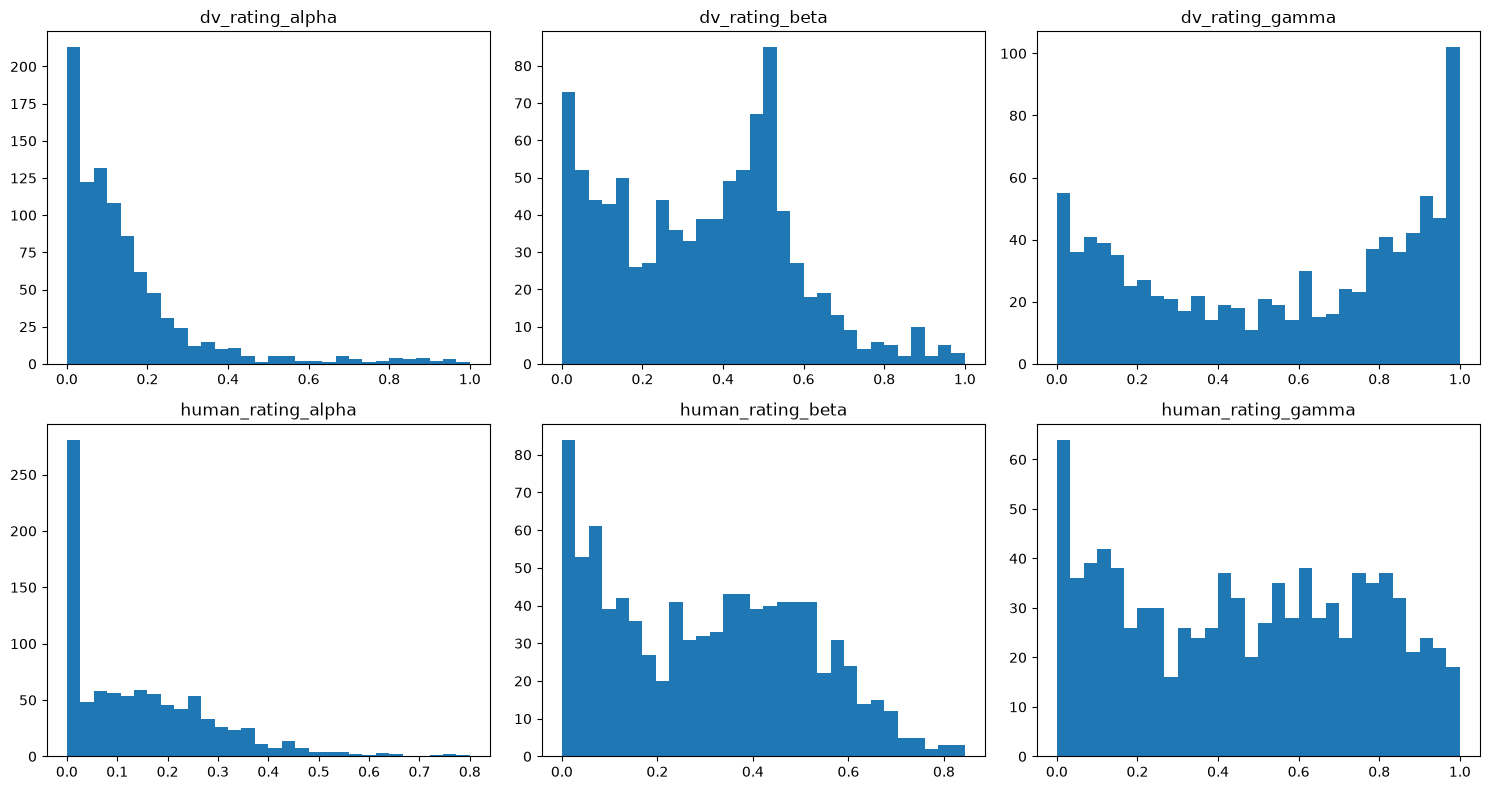

In [21]:
print(elo_raw[RATINGS].describe().round(3))
print("\nratings exactly 0:", (elo_raw[RATINGS] == 0).sum().to_dict())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, RATINGS):
    ax.hist(elo_raw[col], bins=30)
    ax.set_title(col)
fig.tight_layout()
plt.show()

### 3. GPT-4 vs. human agreement

alpha: Spearman(GPT-4, human) = 0.455 | mean(GPT-4 - human) = -0.002
beta: Spearman(GPT-4, human) = 0.901 | mean(GPT-4 - human) = +0.042
gamma: Spearman(GPT-4, human) = 0.915 | mean(GPT-4 - human) = +0.086


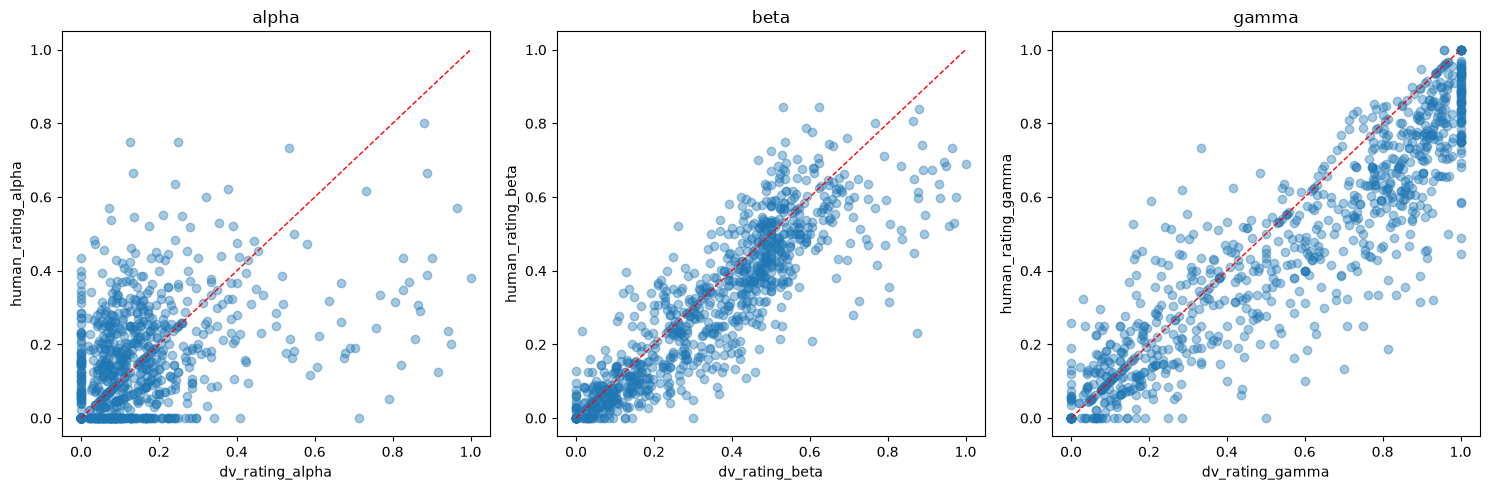

In [22]:
pairs = [(m, f"dv_rating_{m}", f"human_rating_{m}") for m in ("alpha", "beta", "gamma")]
for label, dv_col, human_col in pairs:
    rho = elo_raw[[dv_col, human_col]].corr(method="spearman").iloc[0, 1]
    diff = (elo_raw[dv_col] - elo_raw[human_col]).mean()
    print(f"{label}: Spearman(GPT-4, human) = {rho:.3f} | mean(GPT-4 - human) = {diff:+.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, dv_col, human_col) in zip(axes, pairs):
    ax.scatter(elo_raw[dv_col], elo_raw[human_col], alpha=0.4)
    ax.plot([0, 1], [0, 1], "r--", linewidth=1)
    ax.set_xlabel(dv_col)
    ax.set_ylabel(human_col)
    ax.set_title(label)
fig.tight_layout()
plt.show()

In [23]:
elo_raw[RATINGS].corr(method="spearman").round(3)

,dv_rating_alpha,dv_rating_beta,dv_rating_gamma,human_rating_alpha,human_rating_beta,human_rating_gamma
dv_rating_alpha,1.000,0.637,0.449,0.455,0.514,0.495
dv_rating_beta,0.637,1.000,0.963,0.745,0.901,0.908
dv_rating_gamma,0.449,0.963,1.000,0.728,0.898,0.915
human_rating_alpha,0.455,0.745,0.728,1.000,0.888,0.781
human_rating_beta,0.514,0.901,0.898,0.888,1.000,0.978
human_rating_gamma,0.495,0.908,0.915,0.781,0.978,1.000


### 4. Extremes and major groups

In [24]:
show = ["O*NET-SOC Code", "Title", "dv_rating_beta"]
print("Most exposed:")
print(elo_raw.nlargest(10, "dv_rating_beta")[show].to_string(index=False))
print("\nLeast exposed:")
print(elo_raw.nsmallest(10, "dv_rating_beta")[show].to_string(index=False))

Most exposed:
O*NET-SOC Code                                       Title  dv_rating_beta
    15-2021.00                              Mathematicians        1.000000
    43-9081.00               Proofreaders and Copy Markers        0.975000
    15-1299.07                        Blockchain Engineers        0.970588
    43-4021.00                       Correspondence Clerks        0.964286
    27-3092.00 Court Reporters and Simultaneous Captioners        0.958333
    15-1251.00                        Computer Programmers        0.950000
    15-1243.01                Data Warehousing Specialists        0.944444
    15-1242.00                     Database Administrators        0.935484
    15-1254.00                              Web Developers        0.932692
    15-1299.01                          Web Administrators        0.913043

Least exposed:
O*NET-SOC Code                                                         Title  dv_rating_beta
    27-2021.00                               Athlete

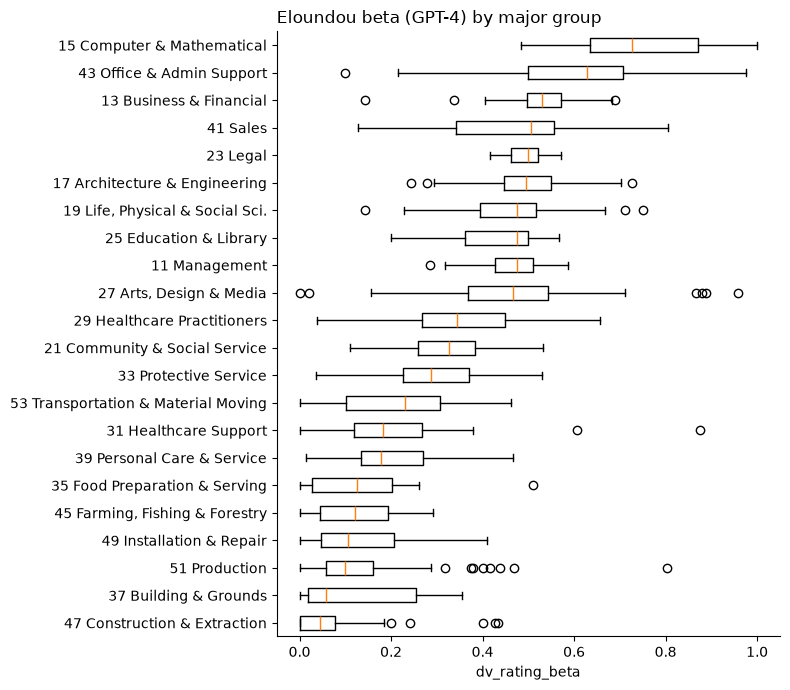

In [25]:
boxplot_by_group(elo_raw, "O*NET-SOC Code", "dv_rating_beta", "Eloundou beta (GPT-4) by major group")

### 5. Coverage against SOC 2018

In [26]:
soc18 = set(cw.soc18)
print("6-digit codes not in SOC 2018:", sorted(set(elo_raw.soc6) - soc18))
missing18 = sorted(soc18 - set(elo_raw.soc6))
print("SOC 2018 codes with no Eloundou rating:", len(missing18))
print(pd.Series([c[:2] for c in missing18]).value_counts().to_string())

6-digit codes not in SOC 2018: []
SOC 2018 codes with no Eloundou rating: 69
55    19
51     6
25     5
27     5
53     5
21     4
43     4
39     3
47     3
29     2
35     2
37     2
45     2
11     1
17     1
19     1
23     1
33     1
41     1
49     1


### 6. Summary: key trends, merging, and outliers

**General trends**
- 923 O\*NET occupations, no nulls or duplicate codes, every rating in [0, 1], and alpha ≤ beta ≤ gamma
  holds on every row for both raters, as it should by construction.
- Exposure is low for most jobs under alpha (median ≈ 0.10) and rises sharply once tools count
  (beta ≈ 0.36, gamma ≈ 0.60). 48 occupations have beta = 0 (cooks, dishwashers, athletes, orderlies).
- GPT-4 and humans agree well on beta and gamma (Spearman ≈ 0.90 and 0.92) but only moderately on
  alpha (≈ 0.46). GPT-4 rates slightly higher on beta (+0.04) and gamma (+0.09).
- Clear white-collar vs. manual split: computer/math (median beta 0.73) and office/admin (0.63) are most
  exposed; construction (0.05), building/grounds (0.06) and production (0.10) least. Top single
  occupations: Mathematicians (1.0), Proofreaders, Blockchain Engineers, Correspondence Clerks.

**Merging**
- The file is keyed to O\*NET-SOC 2019 (8-digit), which rolls up to SOC 2018. 149 rows are O\*NET
  sub-occupations, so the 923 rows collapse to 798 6-digit codes, all of which exist in SOC 2018:
  **no crosswalk is needed for Eloundou**.
- Most codes have one O\*NET child, but some have many (up to 9 for `15-1299`), and the roll-up averages
  them; see `eda_interim.ipynb` for how much that hides.
- 69 SOC 2018 codes have no Eloundou rating; the largest block is military (19 codes in group 55), which
  O\*NET does not cover, and the rest are spread thinly across groups.

**Outliers**
- No invalid values. The zero-exposure block (48 rows) and single 1.0 (Mathematicians) are real
  scores, not errors, and should be kept.
- The low alpha agreement is the main caution: use beta (or gamma) as the Eloundou headline.

### EDA techniques applied (Eloundou)

| Technique | What it was used for | Section |
|---|---|---|
| Missing-value and duplicate checks | `isna()`, `duplicated()` on codes | 1 |
| Format validation with regex + `assert` | Every code matches `##-####.##` | 1 |
| Range checks | Every rating is a share in [0, 1] | 1 |
| Logical consistency check | alpha ≤ beta ≤ gamma per row (nested definitions) | 1 |
| Cardinality analysis | O\*NET occupations per 6-digit SOC code (roll-up preview) | 1 |
| Summary statistics + histograms | Shape of each of the six ratings | 2 |
| Zero-inflation count | How many occupations have no exposure at all | 2 |
| Spearman rank correlation | GPT-4 vs. human agreement, and between measures | 3 |
| Bias check (mean difference) | Whether GPT-4 rates systematically higher than humans | 3 |
| Scatter plots with y = x reference | Visual agreement between raters | 3 |
| Top/bottom-N ranking | Sanity check on the extremes | 4 |
| Group-by major group + boxplots | Exposure trends by occupation family | 4 |
| Set comparison against SOC 2018 | Coverage: which occupations Eloundou does not rate | 5 |

## Part 3 — AI Occupational Exposure (`AIOE_DataAppendix.xlsx`)

Felten, Raj & Seamans link 10 AI applications to the O\*NET abilities each occupation uses.
AIOE is standardized (mean 0, sd 1), so it ranks occupations relative to each other rather than
giving an absolute level. Keyed to SOC 2010.

### 1. Sheets and integrity checks
Only Appendix A (occupation scores) feeds the pipeline; the other sheets are industry, county and
ability-level versions of the same measure.

In [27]:
aioe_xl = pd.ExcelFile(data_file("raw/AIOE_DataAppendix.xlsx"))
for sheet in aioe_xl.sheet_names:
    print(f"{sheet:<12} {aioe_xl.parse(sheet).shape}")

aioe_raw = aioe_xl.parse("Appendix A").rename(
    columns={"SOC Code": "soc2010", "Occupation Title": "title_2010"})

print("\nnulls:", aioe_raw.isna().sum().to_dict())
print("duplicate codes:", aioe_raw.soc2010.duplicated().sum(), "| duplicate titles:", aioe_raw.title_2010.duplicated().sum())
print("badly formatted codes:", (~aioe_raw.soc2010.str.fullmatch(r"\d{2}-\d{4}")).sum())
# Detailed SOC codes never end in 0; a trailing 0 means a broad (aggregate) code
print("broad codes:", aioe_raw.loc[aioe_raw.soc2010.str.endswith("0"), ["soc2010", "title_2010"]].values.tolist())

Index        (4, 1)


Appendix A   (774, 3)
Appendix B   (250, 3)
Appendix C   (3271, 3)


Appendix D   (52, 11)
Appendix E   (52, 2)



nulls: {'soc2010': 0, 'title_2010': 0, 'AIOE': 0}
duplicate codes: 0 | duplicate titles: 0
badly formatted codes: 0
broad codes: [['19-1020', 'Biologists']]


### 2. Distribution and outliers

count    7.740000e+02
mean    -6.847545e-09
std      1.000000e+00
min     -2.669758e+00
25%     -8.645451e-01
50%     -5.119285e-02
75%      1.014434e+00
max      1.527667e+00
Name: AIOE, dtype: float64
skew: -0.067 | excess kurtosis: -1.269
1.5x IQR outliers: 0


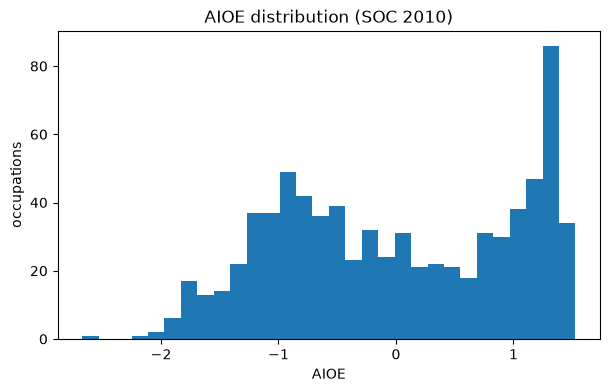

In [28]:
print(aioe_raw.AIOE.describe())
print(f"skew: {aioe_raw.AIOE.skew():.3f} | excess kurtosis: {aioe_raw.AIOE.kurt():.3f}")

q1, q3 = aioe_raw.AIOE.quantile([0.25, 0.75])
iqr = q3 - q1
print("1.5x IQR outliers:", ((aioe_raw.AIOE < q1 - 1.5 * iqr) | (aioe_raw.AIOE > q3 + 1.5 * iqr)).sum())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(aioe_raw.AIOE, bins=30)
ax.set_xlabel("AIOE")
ax.set_ylabel("occupations")
ax.set_title("AIOE distribution (SOC 2010)")
plt.show()

In [29]:
show = ["soc2010", "title_2010", "AIOE"]
print("Most exposed:")
print(aioe_raw.nlargest(10, "AIOE")[show].to_string(index=False))
print("\nLeast exposed:")
print(aioe_raw.nsmallest(10, "AIOE")[show].to_string(index=False))

Most exposed:
soc2010                                                     title_2010     AIOE
29-9092                                             Genetic Counselors 1.527667
13-2061                                            Financial Examiners 1.526064
15-2011                                                      Actuaries 1.516474
13-1023 Purchasing Agents, Except Wholesale, Retail, and Farm Products 1.509181
13-2031                                                Budget Analysts 1.502988
23-1023                     Judges, Magistrate Judges, and Magistrates 1.496494
43-3061                                             Procurement Clerks 1.487838
13-2011                                       Accountants and Auditors 1.481956
15-2021                                                 Mathematicians 1.472319
23-1012                                            Judicial Law Clerks 1.462973

Least exposed:
soc2010                                                                  title_2010      A

         count  mean  median   std
soc2010                           
47          57 -1.34   -1.40  0.45
37           8 -1.15   -1.16  0.52
45          13 -1.06   -1.11  0.53
51         103 -0.83   -0.90  0.45
49          51 -0.88   -0.89  0.37
53          48 -0.74   -0.80  0.57
35          16 -0.77   -0.67  0.50
31          17 -0.51   -0.53  0.63
33          21 -0.36   -0.51  0.50
39          30 -0.29   -0.36  0.66
29          59  0.19    0.10  0.51
27          36  0.27    0.62  0.95
41          21  0.64    0.89  0.69
17          34  0.81    0.94  0.46
21          14  0.88    0.95  0.39
43          52  0.65    1.00  0.78
19          43  0.83    1.01  0.56
11          33  0.96    1.05  0.43
15          18  1.11    1.22  0.33
25          60  0.99    1.22  0.47
13          32  1.17    1.34  0.41
23           8  1.31    1.35  0.21


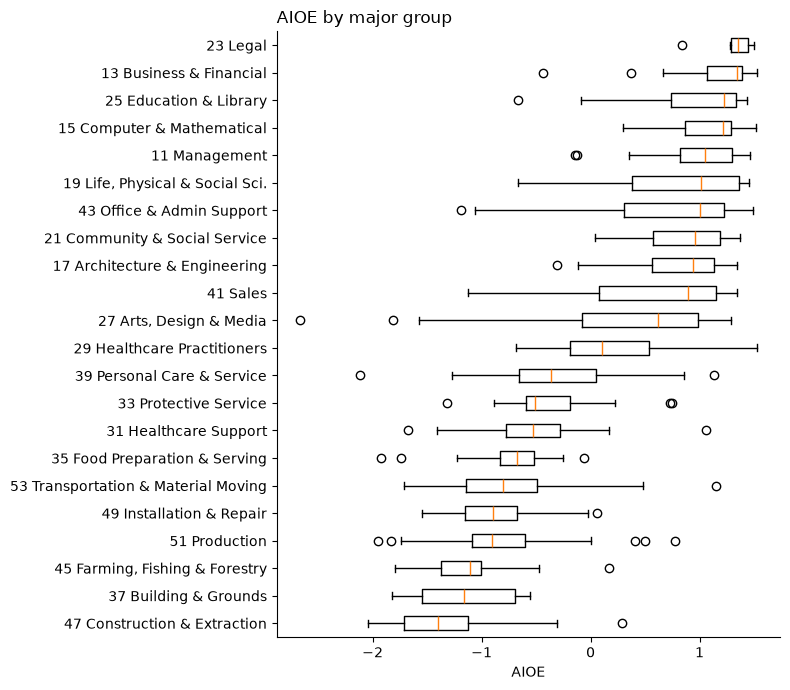

In [30]:
print(aioe_raw.groupby(aioe_raw.soc2010.str[:2]).AIOE.agg(["count", "mean", "median", "std"])
      .sort_values("median").round(2).to_string())
boxplot_by_group(aioe_raw, "soc2010", "AIOE", "AIOE by major group")

### 3. Coverage against the SOC 2010 side of the crosswalk

In [31]:
cw10 = set(cw.soc10)
print(f"crosswalk 2010 codes: {len(cw10)} | scored by AIOE: {len(cw10 & set(aioe_raw.soc2010))}"
      f" | not scored: {len(cw10 - set(aioe_raw.soc2010))}")
print("AIOE codes not on the crosswalk:", sorted(set(aioe_raw.soc2010) - cw10))

unscored = cw[~cw.soc10.isin(aioe_raw.soc2010)].drop_duplicates("soc10")
print("\nUnscored 2010 codes by major group:")
print(unscored.soc10.str[:2].value_counts().to_string())

crosswalk 2010 codes: 840 | scored by AIOE: 773 | not scored: 67
AIOE codes not on the crosswalk: ['19-1020']

Unscored 2010 codes by major group:
soc10
55    20
27     5
51     5
21     4
43     4
53     4
25     3
39     3
47     3
29     2
35     2
37     2
45     2
11     1
15     1
17     1
19     1
23     1
33     1
41     1
49     1


### 4. Summary: key trends, merging, and outliers

**General trends**
- 774 occupations with no nulls, duplicates or badly formatted codes. Scores are standardized
  (mean 0, sd 1): flat and slightly left-skewed (excess kurtosis ≈ -1.27, skew ≈ -0.07), with a ceiling
  near 1.53 and a longer low tail down to -2.67.
- Exposure follows job type: legal, business/financial, education, computer/math and management
  are most exposed (median > 1); construction, grounds maintenance, farming, production and repair least
  (median < -0.8). Top: Genetic Counselors, Financial Examiners, Actuaries. Bottom: Dancers, Fitness
  Trainers, construction helpers.
- Arts & media (27) is the most spread-out group (sd 0.95), so a group average hides a lot there.

**Merging**
- AIOE is keyed to SOC 2010, so it must go through the crosswalk (Part 1) to reach SOC 2018.
- 773 of the 840 crosswalk 2010 codes are scored; 67 are not, 20 of them military (group 55).
- One code, `19-1020` Biologists, is a *broad* code with no crosswalk row. It covers four detailed codes
  (`19-1021`, `19-1022`, `19-1023`, `19-1029`) and could be recovered by assigning its score to them.

**Outliers**
- No statistical outliers by the 1.5×IQR rule. The extremes are plausible low-exposure physical jobs
  and should be kept.

### EDA techniques applied (AIOE)

| Technique | What it was used for | Section |
|---|---|---|
| Sheet inventory (`ExcelFile.sheet_names`) | Confirm which appendix holds occupation scores | 1 |
| Null, duplicate and format checks (regex on `##-####`) | Integrity of codes, titles and scores | 1 |
| Broad-code detection (code ends in 0) | Find aggregate codes that won't match the crosswalk | 1 |
| Summary statistics, skew, kurtosis | Shape of the standardized score | 2 |
| Histogram | Distribution shape | 2 |
| 1.5×IQR rule | Statistical outlier screen | 2 |
| Top/bottom-N ranking | Sanity check that extremes are plausible | 2 |
| Group-by major group + boxplots | Trends and spread by occupation family | 2 |
| Set comparison against the crosswalk | Coverage: which 2010 occupations AIOE never scored | 3 |

## Part 4 — Frey & Osborne probability of computerisation (`The_Future_of_Employment.pdf`)

The raw data is the appendix table of the paper (pages 57-72): rank, probability, a training label
for the 70 occupations the authors hand-labelled (1 = automatable, 0 = not), SOC 2010 code and title.
It is parsed with the same regex as Milestone 1, Task 3b.

### 1. Parse the appendix table

In [32]:
import re

try:
    import pdfplumber
except ImportError:  # not preinstalled on Colab
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pdfplumber"])
    import pdfplumber

FO_ROW = re.compile(r"^(\d+)\.\s+([\d.]+)\s+(?:(\d)\s+)?(\d{2}-\d{4})\s+(.+)$")

rows = []
with pdfplumber.open(data_file("raw/The_Future_of_Employment.pdf")) as pdf:
    n_pages = len(pdf.pages)
    for page in pdf.pages[56:]:
        for line in (page.extract_text() or "").split("\n"):
            m = FO_ROW.match(line.strip())
            if m:
                rank, prob, label, soc, title = m.groups()
                rows.append({"rank": int(rank), "probability": float(prob),
                             "training_label": label, "soc2010": soc, "title_2010": title})

fo_raw = pd.DataFrame(rows)
print(f"pages: {n_pages} | rows parsed: {len(fo_raw)}")
fo_raw.head()

pages: 72 | rows parsed: 702


,rank,probability,training_label,soc2010,title_2010
0,1,0.0028,NaN,29-1125,RecreationalTherapists
1,2,0.0030,NaN,49-1011,"First-LineSupervisorsofMechanics,Installers,andRepairers"
2,3,0.0030,NaN,11-9161,EmergencyManagementDirectors
3,4,0.0031,NaN,21-1023,MentalHealthandSubstanceAbuseSocialWorkers
4,5,0.0033,NaN,29-1181,Audiologists


### 2. Integrity checks

In [33]:
print("ranks contiguous 1..N:", sorted(fo_raw["rank"]) == list(range(1, len(fo_raw) + 1)))
print("probability non-decreasing in rank:", fo_raw.sort_values("rank").probability.is_monotonic_increasing)
print("probability range:", fo_raw.probability.min(), "-", fo_raw.probability.max())
print("duplicate codes:", fo_raw.soc2010.duplicated().sum())
print("training labels:", fo_raw.training_label.value_counts(dropna=False).to_dict())

# pdfplumber drops most spaces from titles, so titles are only usable via the crosswalk
print("titles with no spaces:", (~fo_raw.title_2010.str.contains(" ")).sum(), "of", len(fo_raw))
print(fo_raw.title_2010.head(3).tolist())

ranks contiguous 1..N: True
probability non-decreasing in rank: True
probability range: 0.0028 - 0.99
duplicate codes: 0
training labels: {nan: 632, '1': 37, '0': 33}
titles with no spaces: 685 of 702
['RecreationalTherapists', 'First-LineSupervisorsofMechanics,Installers,andRepairers', 'EmergencyManagementDirectors']


In [34]:
not_on_cw = fo_raw[~fo_raw.soc2010.isin(cw.soc10)].copy()
not_on_cw["kind"] = "not a SOC 2010 detailed code"
not_on_cw.loc[not_on_cw.soc2010.str.endswith("0"), "kind"] = "broad code (ends in 0)"
print("codes not on the SOC 2010 side of the crosswalk:", len(not_on_cw))
not_on_cw[["rank", "probability", "soc2010", "title_2010", "kind"]]

codes not on the SOC 2010 side of the crosswalk: 17


,rank,probability,soc2010,title_2010,kind
14,15,0.0042,29-1060,PhysiciansandSurgeons,broad code (ends in 0)
45,46,0.0090,29-1111,RegisteredNurses,not a SOC 2010 detailed code
47,48,0.0095,25-3999,"TeachersandInstructors,AllOther",not a SOC 2010 detailed code
111,112,0.0320,25-1000,PostsecondaryTeachers,broad code (ends in 0)
141,142,0.0550,29-9799,"HealthcarePractitionersandTechnicalWorkers,AllOther",not a SOC 2010 detailed code
206,207,0.2000,39-4831,"FuneralServiceManagers,Directors,Morticians,andUndertakers",not a SOC 2010 detailed code
207,208,0.2100,15-1179,"Information Security Analysts, Web Developers, and Computer Net-",not a SOC 2010 detailed code
211,212,0.2200,15-1799,"ComputerOccupations,AllOther",not a SOC 2010 detailed code
217,218,0.2300,29-2037,RadiologicTechnologistsandTechnicians,not a SOC 2010 detailed code
241,242,0.3100,13-1078,"HumanResources,Training,andLaborRelationsSpecialists,AllOther",not a SOC 2010 detailed code


### 3. Distribution and risk bands
Frey & Osborne's bands: low < 0.3, medium 0.3-0.7, high > 0.7.

count    702.000000
mean       0.535550
std        0.368149
min        0.002800
25%        0.110000
50%        0.640000
75%        0.890000
max        0.990000
Name: probability, dtype: float64
probability
low (<0.3)          241
medium (0.3-0.7)    145
high (>0.7)         316


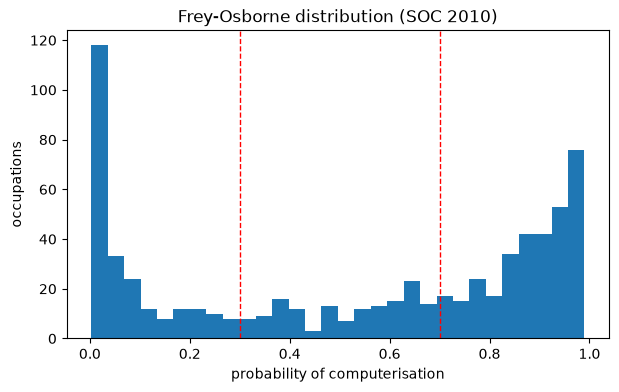

In [35]:
print(fo_raw.probability.describe())
bands = pd.cut(fo_raw.probability, [0, 0.3, 0.7, 1], include_lowest=True,
               labels=["low (<0.3)", "medium (0.3-0.7)", "high (>0.7)"])
print(bands.value_counts().sort_index().to_string())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(fo_raw.probability, bins=30)
for x in (0.3, 0.7):
    ax.axvline(x, color="r", linestyle="--", linewidth=1)
ax.set_xlabel("probability of computerisation")
ax.set_ylabel("occupations")
ax.set_title("Frey-Osborne distribution (SOC 2010)")
plt.show()

In [36]:
# Hand-labelled training occupations vs. the model's output
fo_raw.groupby(fo_raw.training_label.fillna("unlabelled")).probability.describe().round(2)

,count,mean,std,min,25%,50%,75%,max
training_label,,,,,,,,
0,33.0,0.19,0.25,0.00,0.02,0.08,0.30,0.94
1,37.0,0.85,0.16,0.38,0.81,0.89,0.96,0.99
unlabelled,632.0,0.54,0.37,0.00,0.13,0.64,0.88,0.99


### 4. Extremes and major groups

In [37]:
titles10 = cw.drop_duplicates("soc10").set_index("soc10").title10
fo_raw["title_clean"] = fo_raw.soc2010.map(titles10).fillna(fo_raw.title_2010)
show = ["rank", "soc2010", "title_clean", "probability"]
print("Highest risk:")
print(fo_raw.nlargest(10, "probability")[show].to_string(index=False))
print("\nLowest risk:")
print(fo_raw.nsmallest(10, "probability")[show].to_string(index=False))

Highest risk:
 rank soc2010                                                   title_clean  probability
  691 43-9021                                             Data Entry Keyers         0.99
  692 25-4031                                           Library Technicians         0.99
  693 43-4141                                           New Accounts Clerks         0.99
  694 51-9151 Photographic Process Workers and Processing Machine Operators         0.99
  695 13-2082                                                 Tax Preparers         0.99
  696 43-5011                                      Cargo and Freight Agents         0.99
  697 49-9064                                               Watch Repairers         0.99
  698 13-2053                                        Insurance Underwriters         0.99
  699 15-2091                                      Mathematical Technicians         0.99
  700 51-6051                                                  Sewers, Hand         0.99

Lowest

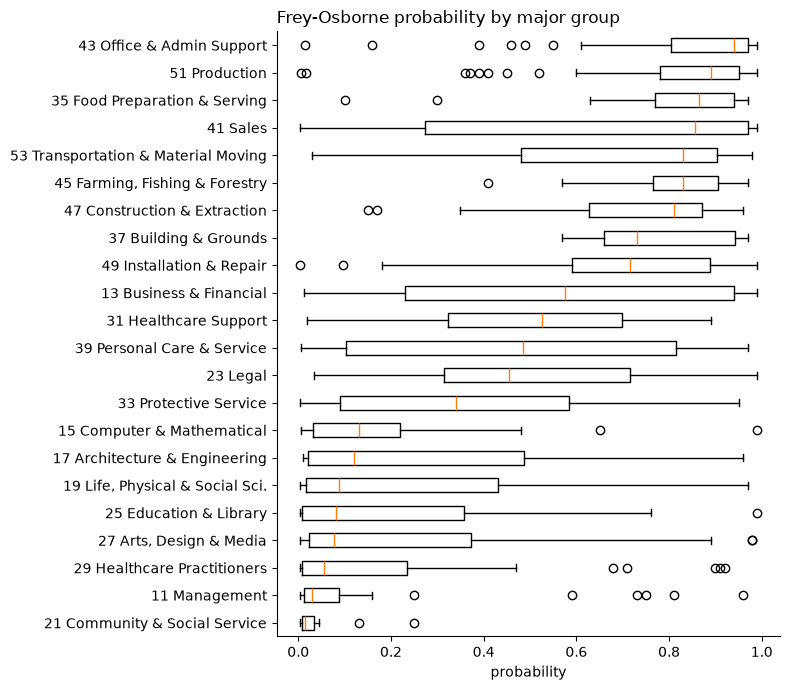

In [38]:
boxplot_by_group(fo_raw, "soc2010", "probability", "Frey-Osborne probability by major group")

### 5. Comparison with `data/frey_osborne_probabilities.csv`

In [39]:
fo_csv = pd.read_csv(data_file("frey_osborne_probabilities.csv"), dtype={"soc_code_2010": str})
cmp = fo_raw.merge(fo_csv, left_on="soc2010", right_on="soc_code_2010", how="outer", indicator=True)
print(cmp._merge.value_counts().to_string())
both = cmp[cmp._merge == "both"]
print("value mismatches:", (both.probability - both.fo_computerization_probability).abs().gt(1e-9).sum())

pdf_only = cmp[cmp._merge == "left_only"]
print(f"PDF-only codes on the crosswalk: {pdf_only.soc2010.isin(cw.soc10).sum()} of {len(pdf_only)}")
pdf_only[pdf_only.soc2010.isin(cw.soc10)][["rank", "soc2010", "title_clean", "probability"]].head(10)

_merge
both          653
left_only      49
right_only      0
value mismatches: 0
PDF-only codes on the crosswalk: 32 of 49


,rank,soc2010,title_clean,probability
32,506,13-1021,"Buyers and Purchasing Agents, Farm Products",0.8700
33,237,13-1022,"Wholesale and Retail Buyers, Except Farm Products",0.2900
34,423,13-1023,"Purchasing Agents, Except Wholesale, Retail, and Farm Products",0.7700
75,699,15-2091,Mathematical Technicians,0.9900
152,114,21-1011,Substance Abuse and Behavioral Disorder Counselors,0.0330
155,25,21-1014,Mental Health Counselors,0.0048
166,276,23-1012,Judicial Law Clerks,0.4100
167,353,23-1021,"Administrative Law Judges, Adjudicators, and Hearing Officers",0.6400
169,271,23-1023,"Judges, Magistrate Judges, and Magistrates",0.4000
206,259,27-2011,Actors,0.3700


### 6. Summary: key trends, merging, and outliers

**General trends**
- The appendix parses cleanly: 702 occupations, ranks 1-702 with no gaps, no duplicate codes, and
  probability non-decreasing in rank.
- The distribution is strongly **bimodal** (median 0.64, mean 0.54): 316 occupations are high risk
  (> 0.7), 241 low risk (< 0.3), only 145 in between. This differs from AIOE and Eloundou, which are
  continuous scores.
- Risk is the mirror image of the AI-exposure indices: office/admin (median 0.94), production (0.89)
  and food service (0.86) are highest; community/social service (0.01), management (0.03) and healthcare
  practitioners (0.06) lowest.
- The 70 hand-labelled training occupations sit where expected (label 1: median 0.89; label 0: median
  0.08), a basic sanity check on the model output.

**Merging**
- Keyed to SOC 2010, so it goes through the crosswalk like AIOE.
- **17 codes are not SOC 2010 detailed codes** and will not match the crosswalk. Four are broad codes
  (`29-1060` Physicians and Surgeons, `25-1000` Postsecondary Teachers, `15-1150`, `45-2090`); the rest
  are SOC 2000 or BLS aggregate codes (e.g. `29-1111` Registered Nurses, now `29-1141`; `x-x799`
  "All Other" groups). These are large, low-risk healthcare and education occupations, so losing them
  biases the merged table; most can be mapped by hand.
- Titles lose their spaces in PDF extraction (685 of 702), so join on code and take titles from the
  crosswalk, never join on title.
- `data/frey_osborne_probabilities.csv` is an incomplete 653-row subset of this table (49 occupations
  missing, 32 of them mappable); values that are present match exactly. Use the PDF, as the pipeline does.

**Outliers**
- No invalid values: every probability is in (0, 1). Bimodality means mean/sd summaries and z-score
  outlier rules are not appropriate here; rank-based comparisons (Spearman, percentiles) are.

### EDA techniques applied (Frey-Osborne)

| Technique | What it was used for | Section |
|---|---|---|
| PDF table extraction (`pdfplumber` + regex) | Turn the appendix into a table | 1 |
| Reconciliation checks (contiguous ranks, monotonic probability) | Confirm no rows were lost or mis-parsed | 2 |
| Duplicate and label-count checks | Integrity of codes and training labels | 2 |
| Text-quality check | Detect titles mangled by PDF extraction | 2 |
| Set comparison against the crosswalk + code classification | Find and explain codes that will not map to SOC 2018 | 2 |
| Summary statistics + histogram with threshold lines | Bimodality and the paper's risk bands | 3 |
| Binning (`pd.cut`) | Count occupations per risk band | 3 |
| Label vs. output comparison | Sanity check on hand-labelled training occupations | 3 |
| Top/bottom-N ranking | Plausibility of extremes | 4 |
| Group-by major group + boxplots | Risk trends by occupation family | 4 |
| Outer join with indicator + value comparison | Validate the CSV copy against the source | 5 |

## Part 5 — O\*NET 30.3 feature files

O\*NET describes every occupation with standardised ratings. Milestone 3 turns these ratings into the 20-40 grouped
features (Job Zone plus ability, skill, work-activity and work-context aggregates) that the disagreement-drivers model
uses. This part checks the files are fit for that job and records the decisions the feature build needs.

| File | What it is |
|---|---|
| `abilities.csv` | 52 abilities (cognitive, psychomotor, physical, sensory): Importance (IM, 1-5) and Level (LV, 0-7) |
| `essential_skills.csv`, `transferable_skills.csv` | the 35 O\*NET Skills, which O\*NET 30.x splits into 10 essential (`2.A`) and 25 transferable (`2.B`) skills; IM and LV |
| `work_activities.csv` | 41 generalized work activities; IM and LV |
| `work_context.csv` | 57 work-context elements: mean context (CX 1-5, CT 1-3) and the % of respondents per answer category (CXP, CTP) |
| `job_zones.csv` | one preparation level (Job Zone) per occupation |

All are keyed to eight-digit O\*NET-SOC 2019 codes (`11-1011.00`). `occupation.xlsx` (BLS projections) and
`occ_level.csv` (Eloundou) sit in the same folder but are not O\*NET files.

**Analysis decisions**
- **Skills are one domain.** The two skills files are checked separately but analysed together, matching the
  O\*NET Content Model and DATA-DICTIONARY §2.5.
- **Headline scale = IM** for abilities, skills and work activities, and **CX** for work context (section 4 shows why
  LV adds little).
- **Element groups come from the O\*NET Content Model.** Element IDs are hierarchical (`1.A.1.b.2` sits in group
  `1.A.1.b` *Idea Generation and Reasoning Abilities*); group names are copied from the O\*NET 30.3 *Content Model
  Reference* file.
- **Roll-up to six digits** uses the unweighted mean over the detail occupations that have ratings, the same rule as
  the Eloundou roll-up in Milestone 1.

### 1. Load, version and structure

In [40]:
import numpy as np

# The first two lines of the README give the O*NET version
readme_lines = data_file("raw/ONET_30.3_README.txt").read_text(encoding="utf-8").splitlines()
print(readme_lines[0])
print(readme_lines[1])

CODE = "O*NET-SOC Code"

# The five rating files, and the O*NET domain each one belongs to
RATING_FILES = {
    "abilities": "Abilities",
    "essential_skills": "Skills",
    "transferable_skills": "Skills",
    "work_activities": "Work Activities",
    "work_context": "Work Context",
}

# Read each rating file. Codes, element IDs and categories are labels, so they are read as text.
TEXT_COLUMNS = {CODE: str, "Element ID": str, "Category": str}
onet = {}
for file_name in RATING_FILES:
    onet[file_name] = pd.read_csv(data_file(f"raw/{file_name}.csv"), dtype=TEXT_COLUMNS)

job_zones = pd.read_csv(data_file("raw/job_zones.csv"), dtype={CODE: str})

# Stack every rating row into one long table, remembering which file and domain it came from
tables = []
for file_name, table in onet.items():
    table = table.copy()
    table["file"] = file_name
    table["domain"] = RATING_FILES[file_name]
    tables.append(table)
ratings = pd.concat(tables, ignore_index=True)


def month_range(dates):
    """First and last month in a column of 'MM/YYYY' dates."""
    months = pd.to_datetime(dates, format="%m/%Y")
    return f"{months.min():%Y-%m} to {months.max():%Y-%m}"


# One summary row per file
inventory = []
for file_name, table in onet.items():
    inventory.append({
        "file": file_name,
        "rows": len(table),
        "columns": table.shape[1],
        "onet_codes": table[CODE].nunique(),
        "elements": table["Element ID"].nunique(),
        "scales": ", ".join(sorted(table["Scale ID"].unique())),
        "dates": month_range(table["Date"]),
        "domain_sources": ", ".join(sorted(table["Domain Source"].unique())),
    })
inventory.append({
    "file": "job_zones",
    "rows": len(job_zones),
    "columns": job_zones.shape[1],
    "onet_codes": job_zones[CODE].nunique(),
    "elements": 1,
    "scales": "Job Zone",
    "dates": month_range(job_zones["Date"]),
    "domain_sources": ", ".join(sorted(job_zones["Domain Source"].unique())),
})
pd.DataFrame(inventory)

O*NET 30.3 Database
May 2026 Release


,file,rows,columns,onet_codes,elements,scales,dates,domain_sources
0,abilities,92976,15,894,52,"IM, LV",2004-12 to 2025-08,Analyst
1,essential_skills,17880,15,894,10,"IM, LV",2010-06 to 2025-08,Analyst
2,transferable_skills,44700,15,894,25,"IM, LV",2010-06 to 2025-08,Analyst
3,work_activities,73308,15,894,41,"IM, LV",2004-12 to 2025-08,"Analyst - Transition, Incumbent, Occupational Expert"
4,work_context,297676,16,894,57,"CT, CTP, CX, CXP",2004-12 to 2025-08,"Analyst - Transition, Incumbent, Occupational Expert"
5,job_zones,923,5,923,1,Job Zone,2008-06 to 2026-05,"Analyst, Analyst - Preliminary"


In [41]:
# Columns and dtypes of each file (blank = the file has no such column).
# N is float where some rows have no sample size; Not Relevant is float in work_context because it is entirely blank there.
all_files = dict(onet)
all_files["job_zones"] = job_zones

dtypes = {}
for file_name, table in all_files.items():
    dtypes[file_name] = table.dtypes.astype(str)
dtypes = pd.DataFrame(dtypes)

# Show the columns in work_context's order, then the columns only job_zones has
column_order = list(onet["work_context"].columns)
for column in job_zones.columns:
    if column not in column_order:
        column_order.append(column)
dtypes.loc[column_order].fillna("")

,abilities,essential_skills,transferable_skills,work_activities,work_context,job_zones
O*NET-SOC Code,str,str,str,str,str,str
Title,str,str,str,str,str,str
Element ID,str,str,str,str,str,
Element Name,str,str,str,str,str,
Scale ID,str,str,str,str,str,
Scale Name,str,str,str,str,str,
Category,,,,,str,
Data Value,float64,float64,float64,float64,float64,
N,int64,int64,int64,float64,float64,
Standard Error,float64,float64,float64,float64,float64,


In [42]:
# Elements and value range of every scale in every file
# (documented ranges: IM 1-5, LV 0-7, CX 1-5, CT 1-3, CXP/CTP 0-100 %)
by_scale = ratings.groupby(["file", "Scale ID", "Scale Name"], sort=False)
scale_summary = pd.DataFrame({
    "elements": by_scale["Element ID"].nunique(),
    "rows": by_scale["Data Value"].size(),
    "min": by_scale["Data Value"].min(),
    "median": by_scale["Data Value"].median(),
    "max": by_scale["Data Value"].max(),
})
scale_summary.round(2)

elements    rows  min  median     max
file                Scale ID Scale Name                                                     
abilities           IM       Importance                      52   46488  1.0    2.62    5.00
                    LV       Level                           52   46488  0.0    2.38    6.00
essential_skills    IM       Importance                      10    8940  1.0    3.12    5.00
                    LV       Level                           10    8940  0.0    3.12    6.00
transferable_skills IM       Importance                      25   22350  1.0    2.38    5.00
                    LV       Level                           25   22350  0.0    2.25    5.75
work_activities     IM       Importance                      41   36654  1.0    3.23    4.99
                    LV       Level                           41   36654  0.0    3.38    6.81
work_context        CX       Context                         55   49170  1.0    2.80    5.00
                    CXP      Context (Categories 1-5)        55  241450  0.0   11.46  100.00
                    CT       Context                          2    1788  1.0    1.70    3.00
                    CTP      Context (Categories 1-3)         2    5268  0.0   25.94  100.00

In [43]:
# Content-model groups: the natural unit for the 20-40 aggregates (section 6).
# Names are copied from the O*NET 30.3 Content Model Reference.
GROUP_NAMES = {
    "1.A.1.a": "Verbal Abilities",
    "1.A.1.b": "Idea Generation and Reasoning Abilities",
    "1.A.1.c": "Quantitative Abilities",
    "1.A.1.d": "Memory",
    "1.A.1.e": "Perceptual Abilities",
    "1.A.1.f": "Spatial Abilities",
    "1.A.1.g": "Attentiveness",
    "1.A.2.a": "Fine Manipulative Abilities",
    "1.A.2.b": "Control Movement Abilities",
    "1.A.2.c": "Reaction Time and Speed Abilities",
    "1.A.3.a": "Physical Strength Abilities",
    "1.A.3.b": "Endurance",
    "1.A.3.c": "Flexibility, Balance, and Coordination",
    "1.A.4.a": "Visual Abilities",
    "1.A.4.b": "Auditory and Speech Abilities",
    "2.A.1": "Foundational Areas (Basic Skills: Content)",
    "2.A.2": "Ways of Working (Basic Skills: Process)",
    "2.B.1": "Social Skills",
    "2.B.2": "Complex Problem Solving Skills",
    "2.B.3": "Technical Skills",
    "2.B.4": "Systems Skills",
    "2.B.5": "Resource Management Skills",
    "4.A.1.a": "Looking for and Receiving Job-Related Information",
    "4.A.1.b": "Identifying and Evaluating Job-Relevant Information",
    "4.A.2.a": "Information and Data Processing",
    "4.A.2.b": "Reasoning and Decision Making",
    "4.A.3.a": "Performing Physical and Manual Work Activities",
    "4.A.3.b": "Performing Complex and Technical Activities",
    "4.A.4.a": "Communicating and Interacting",
    "4.A.4.b": "Coordinating, Developing, Managing, and Advising",
    "4.A.4.c": "Administering",
    "4.C.1.a": "Communication",
    "4.C.1.b": "Role Relationships",
    "4.C.1.c": "Responsibility for Others",
    "4.C.1.d": "Conflictual Contact",
    "4.C.2.a": "Work Setting",
    "4.C.2.b": "Environmental Conditions",
    "4.C.2.c": "Job Hazards",
    "4.C.2.d": "Body Positioning",
    "4.C.2.e": "Work Attire",
    "4.C.3.a": "Criticality of Position",
    "4.C.3.b": "Routine versus Challenging Work",
    "4.C.3.c": "Competition",
    "4.C.3.d": "Pace and Scheduling",
}


def element_group(element_id):
    """Content-model group of an element, e.g. '1.A.1.b.2' -> '1.A.1.b'.

    Skills are grouped at 3 levels ('2.A.1'); everything else at 4 levels ('1.A.1.b').
    """
    parts = element_id.split(".")
    if element_id.startswith("2."):
        return ".".join(parts[:3])
    return ".".join(parts[:4])


# One row per element, with its domain and group
elements = ratings.drop_duplicates("Element ID")[["domain", "Element ID", "Element Name"]].copy()
elements["group"] = elements["Element ID"].apply(element_group)
assert elements["group"].isin(GROUP_NAMES).all(), "an element group has no name"

# Lookups used later: element ID -> group, and element ID -> element name
group_of = elements.set_index("Element ID")["group"]
element_names = elements.set_index("Element ID")["Element Name"]

# Number of groups and elements per domain
elements.groupby("domain", sort=False).agg(groups=("group", "nunique"), elements=("Element ID", "size"))

,groups,elements
domain,,
Abilities,15,52
Skills,7,35
Work Activities,9,41
Work Context,13,57


In [44]:
# Who produced the ratings in each file
print(pd.crosstab(ratings["file"], ratings["Domain Source"]).to_string())

# Job Zone values, and who assigned them
print()
print("Job Zone values:", job_zones["Job Zone"].value_counts().sort_index().to_dict())
print("Job Zone sources:", job_zones["Domain Source"].value_counts().to_dict())

Domain Source        Analyst  Analyst - Transition  Incumbent  Occupational Expert
file                                                                              
abilities              92976                     0          0                    0
essential_skills       17880                     0          0                    0
transferable_skills    44700                     0          0                    0
work_activities            0                  1312      54776                17220
work_context               0                   912     225784                70980

Job Zone values: {2: 331, 3: 212, 4: 226, 5: 154}
Job Zone sources: {'Analyst': 902, 'Analyst - Preliminary': 21}


### 2. Integrity checks
**Missing values.** `Not Relevant` exists only on LV rows, and `Category` only on the category-percentage scales.
The precision columns (N, standard error, CIs, `Recommend Suppress`) depend on who produced the rating, so the
counts are broken down by source.

In [45]:
# The headline columns should never be blank
blank_headline = ratings[["Data Value", CODE, "Element ID"]].isna().sum().sum()
print("missing Data Value / code / element:", blank_headline)
print("missing values in job_zones:", job_zones.isna().sum().sum())

# Count blanks in the precision columns for each file, rating source and scale
PRECISION_COLS = ["N", "Standard Error", "Lower CI Bound", "Upper CI Bound", "Recommend Suppress", "Not Relevant", "Category"]
GROUP_COLS = ["file", "Domain Source", "Scale ID"]
is_blank = ratings[PRECISION_COLS].isna()
is_blank[GROUP_COLS] = ratings[GROUP_COLS]
missing = is_blank.groupby(GROUP_COLS).sum()
missing.insert(0, "rows", ratings.groupby(GROUP_COLS).size())

# Show only the combinations where N, the standard error, a CI bound or Recommend Suppress is blank
has_blanks = missing[["N", "Standard Error", "Lower CI Bound", "Upper CI Bound", "Recommend Suppress"]].sum(axis=1) > 0
missing[has_blanks]

missing Data Value / code / element: 0
missing values in job_zones: 0


rows    N  Standard Error  Lower CI Bound  Upper CI Bound  Recommend Suppress  Not Relevant  Category
file            Domain Source        Scale ID                                                                                                         
work_activities Analyst - Transition IM           656  656             656             656             656                  41           656       656
                                     LV           656  656             656             656             656                  41             0       656
                Incumbent            IM         27388    0               0               8               8                   0         27388     27388
                                     LV         27388    0               0              10              10                   0             0     27388
                Occupational Expert  IM          8610    0            8610            8610            8610                8610          8610      8610
                                     LV          8610    0            8610            8610            8610                8610             0      8610
work_context    Analyst - Transition CT            32   32              32              32              32                   2            32        32
                                     CX           880  880             880             880             880                  55           880       880
                Incumbent            CT          1336    0               0              33              33                   0          1336      1336
                                     CTP         4008    0               0             633             633                   0          4008         0
                                     CX         36740    0               0            1540            1540                   0         36740     36740
                                     CXP       183700    0               0           40354           40354                   0        183700         0
                Occupational Expert  CT           420    0             420             420             420                 420           420       420
                                     CTP         1260    0            1260            1260            1260                1260          1260         0
                                     CX         11550    0           11550           11550           11550               11550         11550     11550
                                     CXP        57750    0           57750           57750           57750               57750         57750         0

In [46]:
# Incumbent rows with blank CIs: is that because the standard error is 0 (every respondent gave the same answer)?
is_incumbent = ratings["Domain Source"] == "Incumbent"
has_no_ci = ratings["Lower CI Bound"].isna()
incumbent_no_ci = ratings[is_incumbent & has_no_ci]
print("Incumbent rows without CI:", len(incumbent_no_ci))
print("their standard errors:", incumbent_no_ci["Standard Error"].unique())

Incumbent rows without CI: 42578
their standard errors: [0.]


In [47]:
# Duplicates: each code x element x scale x category should appear once
KEY = [CODE, "Element ID", "Scale ID", "Category"]
for file_name, table in onet.items():
    key_columns = []
    for column in KEY:
        if column in table.columns:
            key_columns.append(column)
    n_duplicate_rows = table.duplicated().sum()
    n_duplicate_keys = table.duplicated(subset=key_columns).sum()
    print(f"{file_name:<20} duplicate rows: {n_duplicate_rows} | duplicate keys: {n_duplicate_keys}")
print(f"{'job_zones':<20} duplicate codes: {job_zones[CODE].duplicated().sum()}")

# Complete grid: every code has every element (and every category), so rows = codes x elements x categories
grid = ratings.groupby(["file", "Scale ID"]).agg(
    rows=(CODE, "size"),
    codes=(CODE, "nunique"),
    elements=("Element ID", "nunique"),
    categories=("Category", "nunique"),
)
categories = grid["categories"].clip(lower=1)  # scales without categories count as 1
expected_rows = grid["codes"] * grid["elements"] * categories
print("grid complete (codes x elements x categories = rows):", (grid["rows"] == expected_rows).all())

# Each code should have the same title in every file
title_tables = []
for table in all_files.values():
    title_tables.append(table[[CODE, "Title"]])
titles = pd.concat(title_tables).drop_duplicates()
print("codes with more than one title across files:", titles[CODE].duplicated().sum())

# Every code should look like 11-1011.00
for table in all_files.values():
    assert table[CODE].str.fullmatch(r"\d{2}-\d{4}\.\d{2}").all()

abilities            duplicate rows: 0 | duplicate keys: 0
essential_skills     duplicate rows: 0 | duplicate keys: 0
transferable_skills  duplicate rows: 0 | duplicate keys: 0


work_activities      duplicate rows: 0 | duplicate keys: 0


work_context         duplicate rows: 0 | duplicate keys: 0
job_zones            duplicate codes: 0


grid complete (codes x elements x categories = rows): True


codes with more than one title across files: 0


**Out-of-range and inconsistent values.** Each `Data Value` is checked against its scale's documented range. CI bounds
outside the range are counted separately, because a normal-approximation CI can spill over the end of a bounded scale
without the data being wrong. Work context also allows two consistency checks: the five category percentages should
sum to 100, and CX should equal their weighted mean.

In [48]:
# Documented range of each scale
VALID_MIN = {"IM": 1, "LV": 0, "CX": 1, "CT": 1, "CXP": 0, "CTP": 0}
VALID_MAX = {"IM": 5, "LV": 7, "CX": 5, "CT": 3, "CXP": 100, "CTP": 100}
low = ratings["Scale ID"].map(VALID_MIN)
high = ratings["Scale ID"].map(VALID_MAX)

value_out_of_range = ~ratings["Data Value"].between(low, high)
ci_out_of_range = (ratings["Lower CI Bound"] < low) | (ratings["Upper CI Bound"] > high)
print("Data Value out of range:", value_out_of_range.sum())
print("CI bound out of range:", ci_out_of_range.sum())
print("Job Zone outside 1-5:", (~job_zones["Job Zone"].between(1, 5)).sum())

# Work context check 1: the category percentages of each code x element should sum to 100
percentages = ratings[ratings["Scale ID"].isin(["CXP", "CTP"])]
sums = percentages.groupby([CODE, "Element ID"])["Data Value"].sum()
print(f"category % sets: {len(sums):,} | max |sum - 100|: {(sums - 100).abs().max():.2f}")

# Work context check 2: CX should equal the weighted mean of the categories (category number x share)
cxp = percentages[percentages["Scale ID"] == "CXP"].copy()
cxp["weighted"] = cxp["Category"].astype(int) * cxp["Data Value"] / 100
weighted_mean = cxp.groupby([CODE, "Element ID"])["weighted"].sum()
cx = ratings[ratings["Scale ID"] == "CX"].set_index([CODE, "Element ID"])["Data Value"]
gap = (cx - weighted_mean.reindex(cx.index)).abs()
print(f"CX vs weighted category mean: max |gap| = {gap.max():.3f}")

Data Value out of range: 0
CI bound out of range: 0
Job Zone outside 1-5: 0
category % sets: 50,046 | max |sum - 100|: 0.02


CX vs weighted category mean: max |gap| = 0.006


**Precision flags.**
- **Recommend Suppress = Y** is O\*NET's "low precision, use with caution" flag. Occupational Expert rows have no flag,
  so blanks are counted separately.
- **Not Relevant = Y** (LV rows only) means raters judged the element irrelevant.
- **Low N:** Analyst ratings always use 8 analysts, so the N < 10 screen applies only to survey rows.
- **Wide CI:** CI wider than half the scale's range.

In [49]:
# Sample size by rating source
print(ratings.groupby("Domain Source")["N"].describe()[["min", "50%", "max"]].to_string())
print()

# One True/False column per flag
is_survey = ratings["Domain Source"].isin(["Incumbent", "Occupational Expert"])
ci_width = ratings["Upper CI Bound"] - ratings["Lower CI Bound"]
flags = pd.DataFrame({
    "file": ratings["file"],
    "scale": ratings["Scale ID"],
    "suppress_Y": ratings["Recommend Suppress"] == "Y",
    "suppress_blank": ratings["Recommend Suppress"].isna(),
    "not_relevant_Y": ratings["Not Relevant"] == "Y",
    "low_N_survey": is_survey & (ratings["N"] < 10),
    "wide_CI": ci_width > (high - low) / 2,
})

# Count each flag per file and scale, plus a total row
flag_table = flags.groupby(["file", "scale"], sort=False).sum()
flag_table.insert(0, "rows", flags.groupby(["file", "scale"], sort=False).size())
flag_table.loc[("TOTAL", ""), :] = flag_table.sum()
flag_table.astype(int)

                       min   50%   max
Domain Source                         
Analyst                8.0   8.0   8.0
Analyst - Transition   NaN   NaN   NaN
Incumbent              9.0  23.0  99.0
Occupational Expert   16.0  22.0  38.0



rows  suppress_Y  suppress_blank  not_relevant_Y  low_N_survey  wide_CI
file                scale                                                                           
abilities           IM      46488           0               0               0             0        0
                    LV      46488          68               0            7410             0        0
essential_skills    IM       8940           0               0               0             0        0
                    LV       8940          16               0             285             0        0
transferable_skills IM      22350           0               0               0             0        0
                    LV      22350         131               0            3098             0        0
work_activities     IM      36654           1            8651               0             0     2095
                    LV      36654        1062            8651            1094             2     1232
work_context        CX      49170          18           11605               0             0     3003
                    CXP    241450        7205           57750               0             0    32629
                    CT       1788           0             422               0             0      110
                    CTP      5268         261            1260               0             0     1023
TOTAL                      526540        8762           88339           11887             2    40092

In [50]:
# Headline rows only: IM for abilities, skills and work activities; CX for work context
headline = ratings[ratings["Scale ID"].isin(["IM", "CX"])]

# How many headline values are flagged Recommend Suppress?
suppressed = headline[headline["Recommend Suppress"] == "Y"]
print("suppressed headline values:", len(suppressed), "in", suppressed[CODE].nunique(), "occupations")
suppressed_and_wide = flags["suppress_Y"] & flags["wide_CI"]
print("suppressed rows that also have a wide CI:", suppressed_and_wide.sum(), "of", flags["suppress_Y"].sum())

# What do Not Relevant ratings look like? Their LV, and the IM of the same code x element
lv_rows = ratings[ratings["Scale ID"] == "LV"]
im_rows = ratings[ratings["Scale ID"] == "IM"]
not_relevant = lv_rows[lv_rows["Not Relevant"] == "Y"]
im_of_not_relevant = im_rows.merge(not_relevant[[CODE, "Element ID"]], on=[CODE, "Element ID"])["Data Value"]
print("Not Relevant = Y:", len(not_relevant), "rows")
print("  LV median", not_relevant["Data Value"].median(), "| max", not_relevant["Data Value"].max())
print("  matching IM median", im_of_not_relevant.median(), "| max", im_of_not_relevant.max())

suppressed headline values: 19 in 8 occupations
suppressed rows that also have a wide CI: 7140 of 8762
Not Relevant = Y: 11887 rows
  LV median 0.0 | max 1.79
  matching IM median 1.0 | max 1.95


In [51]:
def share_of_outliers(values):
    """Share of values outside 1.5 x IQR (the usual boxplot rule)."""
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    is_outlier = (values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)
    return is_outlier.mean()


# Share of outlier occupations for every element (headline scale)
outlier_share = headline.groupby(["domain", "Element Name"])["Data Value"].agg(share_of_outliers)
print("median share of outlier occupations per element:", outlier_share.groupby("domain").median().round(3).to_dict())
print(outlier_share.sort_values(ascending=False).head(5).round(3).to_string())

# The occupations behind the element with the most outliers
top_domain, top_element = outlier_share.idxmax()
top_element_rows = headline[headline["Element Name"] == top_element]
top_element_rows.nlargest(4, "Data Value")[[CODE, "Title", "Element Name", "Data Value"]]

median share of outlier occupations per element: {'Abilities': 0.001, 'Skills': 0.002, 'Work Activities': 0.004, 'Work Context': 0.006}
domain        Element Name                     
Skills        Installation                         0.209
Abilities     Category Flexibility                 0.152
Skills        Management of Financial Resources    0.139
              Management of Material Resources     0.130
Work Context  Exposed to Disease or Infections     0.122


,O*NET-SOC Code,Title,Element Name,Data Value
143526,47-2152.04,Solar Thermal Installers and Technicians,Installation,4.75
146876,49-9044.00,Millwrights,Installation,3.75
144276,47-4021.00,Elevator and Escalator Installers and Repairers,Installation,3.50
143826,47-2231.00,Solar Photovoltaic Installers,Installation,3.38


### 3. Coverage: which occupations are rated

In [52]:
# Codes with ratings: check that all five rating files cover the same codes
rated = set(onet["abilities"][CODE])
same_codes_everywhere = True
for table in onet.values():
    if set(table[CODE]) != rated:
        same_codes_everywhere = False
print("all five rating files cover the same codes:", same_codes_everywhere)
print("rated codes:", len(rated), "| job_zones codes:", len(job_zones))
print("rated but missing from job_zones:", len(rated - set(job_zones[CODE])))

# The six-digit SOC code of every O*NET-SOC code, and whether O*NET rated it
job_zones["soc6"] = job_zones[CODE].str[:7]
job_zones["rated"] = job_zones[CODE].isin(rated)
rated_6 = set(job_zones.loc[job_zones["rated"], "soc6"])

# The codes that have a Job Zone but no ratings
unrated = job_zones[~job_zones["rated"]].copy()
unrated["in_occ_level"] = unrated[CODE].isin(elo_raw["O*NET-SOC Code"])  # scored by Eloundou?
unrated["new_in_soc2018"] = ~unrated["soc6"].isin(cw.soc10)  # six-digit code new in SOC 2018?
unrated["soc6_has_rated_sibling"] = unrated["soc6"].isin(rated_6)  # another detail row of the code is rated?

print("unrated:", len(unrated))
print("  also in occ_level.csv (Eloundou):", unrated["in_occ_level"].sum())
print("  six-digit code new in SOC 2018:", unrated["new_in_soc2018"].sum())
print("  six-digit code has a rated sibling:", unrated["soc6_has_rated_sibling"].sum())
unrated[[CODE, "Title", "Job Zone", "in_occ_level", "new_in_soc2018", "soc6_has_rated_sibling"]]

all five rating files cover the same codes: True
rated codes: 894 | job_zones codes: 923
rated but missing from job_zones: 0
unrated: 29
  also in occ_level.csv (Eloundou): 29
  six-digit code new in SOC 2018: 27
  six-digit code has a rated sibling: 5


,O*NET-SOC Code,Title,Job Zone,in_occ_level,new_in_soc2018,soc6_has_rated_sibling
3,11-1031.00,Legislators,4,True,False,False
7,11-2032.00,Public Relations Managers,4,True,True,False
76,13-1082.00,Project Management Specialists,4,True,True,False
93,13-2051.00,Financial and Investment Analysts,4,True,False,False
96,13-2054.00,Financial Risk Specialists,4,True,True,False
120,15-1255.00,Web and Digital Interface Designers,4,True,True,True
125,15-1299.04,Penetration Testers,4,True,True,True
127,15-1299.06,Digital Forensics Analysts,4,True,True,True
128,15-1299.07,Blockchain Engineers,4,True,True,True
136,15-2051.00,Data Scientists,4,True,True,True


### 4. Distributions and relationships

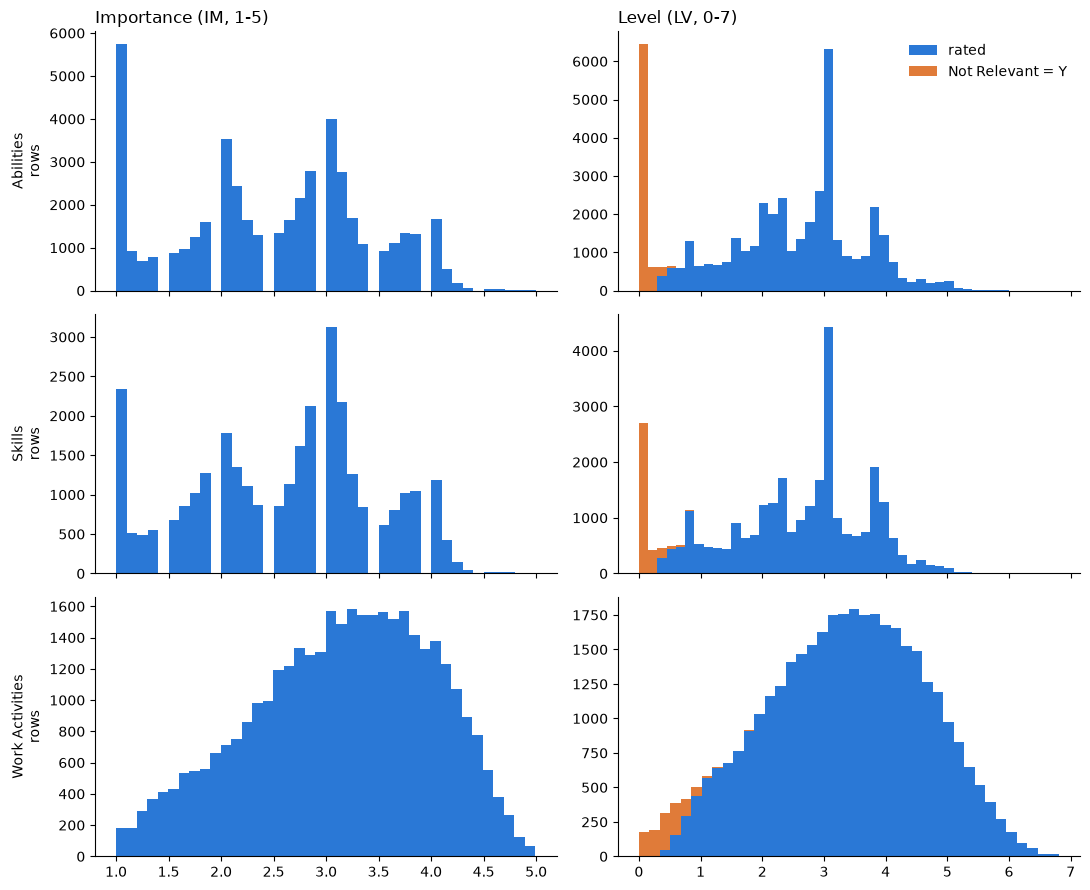

In [53]:
IMLV_DOMAINS = ["Abilities", "Skills", "Work Activities"]

fig, axes = plt.subplots(3, 2, figsize=(11, 9), sharex="col")
for row, domain in enumerate(IMLV_DOMAINS):
    domain_rows = ratings[ratings["domain"] == domain]
    importance = domain_rows[domain_rows["Scale ID"] == "IM"]["Data Value"]
    level = domain_rows[domain_rows["Scale ID"] == "LV"]
    is_not_relevant = level["Not Relevant"] == "Y"

    # Left: Importance. Right: Level, with the Not Relevant rows stacked on top in orange.
    axes[row, 0].hist(importance, bins=40, color="#2a78d6")
    axes[row, 1].hist([level.loc[~is_not_relevant, "Data Value"], level.loc[is_not_relevant, "Data Value"]],
                      bins=40, stacked=True, color=["#2a78d6", "#e07b39"], label=["rated", "Not Relevant = Y"])
    axes[row, 0].set_ylabel(f"{domain}\nrows")

axes[0, 0].set_title("Importance (IM, 1-5)", loc="left")
axes[0, 1].set_title("Level (LV, 0-7)", loc="left")
axes[0, 1].legend(frameon=False)
for ax in axes.flat:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "onet_im_lv_distributions.png", dpi=150)

In [54]:
# Summary statistics of IM and LV per domain
imlv_rows = ratings[ratings["domain"].isin(IMLV_DOMAINS)]
values_by_scale = imlv_rows.groupby(["domain", "Scale ID"])["Data Value"]
imlv_stats = values_by_scale.describe()[["mean", "std", "25%", "50%", "75%"]]
imlv_stats["skew"] = values_by_scale.skew()
imlv_stats.round(2)

mean   std   25%   50%   75%  skew
domain          Scale ID                                    
Abilities       IM        2.48  0.91  1.88  2.62  3.12 -0.08
                LV        2.21  1.32  1.25  2.38  3.12 -0.26
Skills          IM        2.59  0.87  2.00  2.75  3.12 -0.18
                LV        2.38  1.27  1.50  2.62  3.25 -0.38
Work Activities IM        3.15  0.86  2.55  3.23  3.82 -0.32
                LV        3.31  1.32  2.41  3.38  4.29 -0.20

**Importance vs Level.** IM and LV are rated separately. If they move together, one of them is enough. The
correlation is computed over all occupation × element pairs, with and without the Not Relevant rows (whose LV is
forced to about 0), and per element across occupations.

,domain,spearman_all,spearman_excl_not_relevant,per_element_median,per_element_min
0,Abilities,0.978,0.964,0.928,0.727
1,Skills,0.970,0.958,0.941,0.840
2,Work Activities,0.901,0.892,0.900,0.715


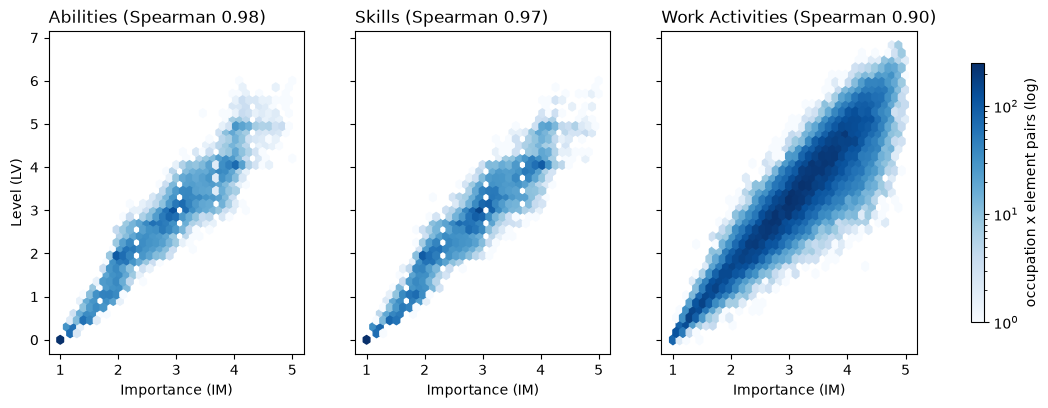

In [55]:
def spearman(a, b):
    """Spearman rank correlation, computed as the Pearson correlation of the ranks.

    pandas' built-in Spearman needs scipy, which the project doesn't use.
    """
    return a.rank().corr(b.rank())


# Put IM and LV side by side: one row per domain x code x element
PAIR_KEY = ["domain", CODE, "Element ID"]
im_values = ratings[ratings["Scale ID"] == "IM"].set_index(PAIR_KEY)["Data Value"].rename("IM")
lv_values = ratings[ratings["Scale ID"] == "LV"].set_index(PAIR_KEY)[["Data Value", "Not Relevant"]]
lv_values = lv_values.rename(columns={"Data Value": "LV"})
imlv = pd.concat([im_values, lv_values], axis=1).reset_index()

# Per domain: correlation over all pairs, without the Not Relevant pairs, and per element across occupations
imlv_results = []
for domain, domain_pairs in imlv.groupby("domain"):
    kept = domain_pairs[domain_pairs["Not Relevant"] != "Y"]
    per_element = []
    for element_id, element_pairs in kept.groupby("Element ID"):
        per_element.append(spearman(element_pairs["IM"], element_pairs["LV"]))
    per_element = pd.Series(per_element)
    imlv_results.append({
        "domain": domain,
        "spearman_all": spearman(domain_pairs["IM"], domain_pairs["LV"]),
        "spearman_excl_not_relevant": spearman(kept["IM"], kept["LV"]),
        "per_element_median": per_element.median(),
        "per_element_min": per_element.min(),
    })

# Hexbin of IM against LV for each domain
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
for ax, domain in zip(axes, IMLV_DOMAINS):
    domain_pairs = imlv[imlv["domain"] == domain]
    hexbins = ax.hexbin(domain_pairs["IM"], domain_pairs["LV"], gridsize=35, mincnt=1, bins="log", cmap="Blues")
    ax.set_title(f"{domain} (Spearman {spearman(domain_pairs['IM'], domain_pairs['LV']):.2f})", loc="left")
    ax.set_xlabel("Importance (IM)")
axes[0].set_ylabel("Level (LV)")
fig.colorbar(hexbins, ax=axes, label="occupation x element pairs (log)", shrink=0.8)
fig.savefig(OUT / "onet_im_vs_lv.png", dpi=150, bbox_inches="tight")
pd.DataFrame(imlv_results).round(3)

**Job Zones** (1 = little preparation, 5 = extensive preparation).

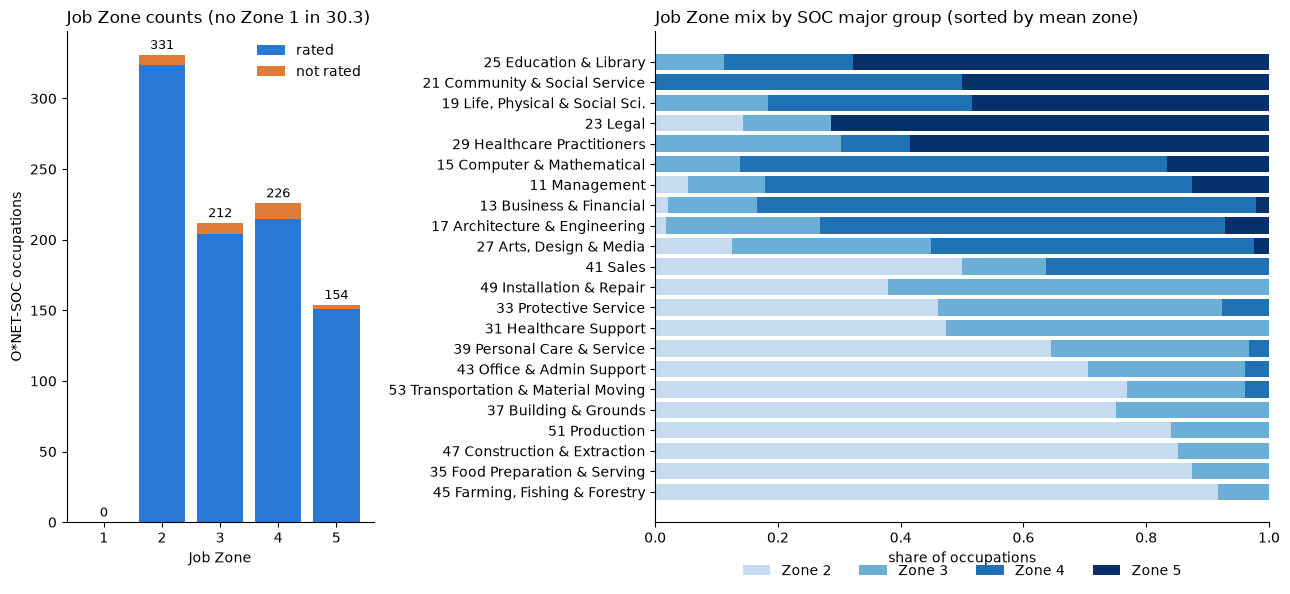

In [56]:
# Share of each Job Zone within each SOC major group, sorted by the group's mean zone
major_group = job_zones[CODE].str[:2]
zone_counts = pd.crosstab(major_group, job_zones["Job Zone"])
zone_share = zone_counts.div(zone_counts.sum(axis=1), axis=0)
zone_share["mean_zone"] = job_zones.groupby(major_group)["Job Zone"].mean()
zone_share = zone_share.sort_values("mean_zone")

fig, axes = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={"width_ratios": [1, 2]})

# Left: occupations per Job Zone, split into rated and not rated
counts = pd.crosstab(job_zones["Job Zone"], job_zones["rated"]).reindex(range(1, 6), fill_value=0)
axes[0].bar(counts.index, counts[True], color="#2a78d6", label="rated")
axes[0].bar(counts.index, counts[False], bottom=counts[True], color="#e07b39", label="not rated")
for zone, total in counts.sum(axis=1).items():
    axes[0].text(zone, total + 4, str(total), ha="center", fontsize=9)
axes[0].set_xticks(range(1, 6))
axes[0].set_xlabel("Job Zone")
axes[0].set_ylabel("O*NET-SOC occupations")
axes[0].set_title("Job Zone counts (no Zone 1 in 30.3)", loc="left")
axes[0].legend(frameon=False)

# Right: one stacked bar per major group
ZONE_COLORS = {2: "#c6dbef", 3: "#6baed6", 4: "#2171b5", 5: "#08306b"}
labels = []
for group in zone_share.index:
    labels.append(f"{group} {MAJOR_GROUPS[group]}")
left = np.zeros(len(zone_share))
for zone in zone_counts.columns:
    axes[1].barh(labels, zone_share[zone], left=left, color=ZONE_COLORS[zone], label=f"Zone {zone}")
    left = left + zone_share[zone].to_numpy()
axes[1].set_xlabel("share of occupations")
axes[1].set_title("Job Zone mix by SOC major group (sorted by mean zone)", loc="left")
axes[1].legend(frameon=False, ncol=4, loc="lower center", bbox_to_anchor=(0.5, -0.14))

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "onet_job_zones.png", dpi=150)

### 5. Identifiers: rolling 8-digit O\*NET-SOC up to 6-digit SOC 2018
An O\*NET-SOC code is a SOC 2018 code plus a two-digit suffix. `.00` is the SOC occupation itself; other suffixes
are O\*NET detail occupations (e.g. `15-1299.04` Penetration Testers under `15-1299` Computer Occupations, All Other).
Rolling up means dropping the suffix and averaging.

In [57]:
def has_00_row(codes):
    """True if one of the codes ends in .00 (the SOC occupation itself)."""
    return codes.str.endswith(".00").any()


# One row per six-digit code: number of O*NET detail occupations, how many are rated, and whether one is .00
families = job_zones.groupby("soc6").agg(
    n_children=(CODE, "size"),
    n_rated=("rated", "sum"),
    has_00=(CODE, has_00_row),
)
soc2018_codes = set(cw.soc18)
print("O*NET-SOC codes:", len(job_zones), "-> six-digit codes:", len(families))
print("six-digit codes that are not valid SOC 2018:", len(set(families.index) - soc2018_codes))

# SOC 2018 codes that O*NET does not cover: military (55-) and the rest
missing_from_onet = soc2018_codes - set(families.index)
is_missing = cw.soc18.isin(missing_from_onet)
is_military = cw.soc18.str.startswith("55")
civilian_missing = cw[is_missing & ~is_military].drop_duplicates("soc18")
n_all_other = civilian_missing.title18.str.contains("All Other").sum()
print("SOC 2018 codes with no O*NET occupation:", len(missing_from_onet))
print("  military:", len(missing_from_onet) - len(civilian_missing))
print("  other:", len(civilian_missing), f"(of which 'All Other' residuals: {n_all_other})")

print("six-digit codes without a .00 row:", (~families["has_00"]).sum())
print("detail rows per six-digit code:", families["n_children"].value_counts().sort_index().to_dict())
print("six-digit codes with more than one detail row:", (families["n_children"] > 1).sum())


def family_status(family):
    """Are all, some or none of a six-digit code's detail occupations rated?"""
    if family["n_rated"] == 0:
        return "no rated child"
    if family["n_rated"] < family["n_children"]:
        return "some children unrated"
    return "all children rated"


families["status"] = families.apply(family_status, axis=1)
print(families["status"].value_counts().to_string())

# The partly rated six-digit codes, with their unrated detail occupations
unrated_children = unrated.groupby("soc6")[CODE].agg(", ".join).rename("unrated_children")
partly_rated = families[families["status"] == "some children unrated"]
partly_rated.join(unrated_children)

O*NET-SOC codes: 923 -> six-digit codes: 798
six-digit codes that are not valid SOC 2018: 0
SOC 2018 codes with no O*NET occupation: 69
  military: 19
  other: 50 (of which 'All Other' residuals: 50)
six-digit codes without a .00 row: 24
detail rows per six-digit code: {1: 731, 2: 42, 3: 11, 4: 7, 5: 1, 6: 3, 7: 1, 8: 1, 9: 1}
six-digit codes with more than one detail row: 67
status
all children rated       771
no rated child            24
some children unrated      3


,n_children,n_rated,has_00,status,unrated_children
soc6,,,,,
15-1255,2,1,True,some children unrated,15-1255.00
15-1299,9,6,False,some children unrated,"15-1299.04, 15-1299.06, 15-1299.07"
15-2051,3,2,True,some children unrated,15-2051.00


In [58]:
# The headline scale of each domain
HEADLINE = {"Abilities": "IM", "Skills": "IM", "Work Activities": "IM", "Work Context": "CX"}
is_headline = ratings["Scale ID"] == ratings["domain"].map(HEADLINE)

# Wide table: one row per O*NET-SOC code, one column per element
wide8 = ratings[is_headline].pivot(index=CODE, columns="Element ID", values="Data Value")

# Roll up to six digits: the mean of each code's rated detail occupations
wide6 = wide8.groupby(wide8.index.str[:7]).mean()

# How much does averaging hide? Compare the spread inside each six-digit code with the spread across all codes.
codes_with_2plus_rated = families.index[families["n_rated"] > 1]
multi = wide8[wide8.index.str[:7].isin(codes_with_2plus_rated)]
within_sd = multi.groupby(multi.index.str[:7]).std().mean()
between_sd = wide6.std()
sd_ratio = within_sd / between_sd
print("six-digit codes averaging 2+ rated occupations:", multi.index.str[:7].nunique())
print(f"median within/between SD ratio across elements: {sd_ratio.median():.2f}")

six-digit codes averaging 2+ rated occupations: 66
median within/between SD ratio across elements: 0.44


**Join coverage against the index tables.** *Full features* = at least one rated detail occupation. *Job zone only* =
the code is in O\*NET but none of its detail occupations is rated. *Not in O\*NET* = no O\*NET-SOC code at all.
Which rows of the merged table this drops is left to the coverage report (issue #15).

In [59]:
# The Milestone 1 index tables, and the column that holds their six-digit code
INDEX_TABLES = {
    "eloundou_soc6": ("interim/eloundou_soc6.csv", "soc6"),
    "aioe_soc2018": ("interim/aioe_soc2018.csv", "soc2018"),
    "frey_osborne_soc2018": ("interim/frey_osborne_soc2018.csv", "soc2018"),
}


def onet_status(code):
    """How much O*NET data a six-digit code gets."""
    if code in rated_6:
        return "full features"
    if code in families.index:
        return "job zone only"
    return "not in O*NET"


coverage = []
for table_name, (path, code_column) in INDEX_TABLES.items():
    index_table = pd.read_csv(data_file(path), dtype={code_column: str})
    statuses = []
    for code in set(index_table[code_column]):
        statuses.append(onet_status(code))
    coverage.append({
        "table": table_name,
        "rows": len(statuses),
        "full features": statuses.count("full features"),
        "job zone only": statuses.count("job zone only"),
        "not in O*NET": statuses.count("not in O*NET"),
    })
pd.DataFrame(coverage).set_index("table")

,rows,full features,job zone only,not in O*NET
table,,,,
eloundou_soc6,798,774,24,0
aioe_soc2018,800,771,19,10
frey_osborne_soc2018,699,680,13,6


In [60]:
# What happens to the 29 unrated (all Eloundou) occupations
has_rated_sibling = unrated["soc6_has_rated_sibling"]
print("unrated O*NET codes in occ_level.csv:", unrated["in_occ_level"].sum(), "of", len(unrated))
print("  six-digit code loses all features:", (~has_rated_sibling).sum())
print("  averaged into a six-digit Eloundou score but missing from its O*NET features:",
      has_rated_sibling.sum(), unrated.loc[has_rated_sibling, "Title"].tolist())

unrated O*NET codes in occ_level.csv: 29 of 29
  six-digit code loses all features: 24
  averaged into a six-digit Eloundou score but missing from its O*NET features: 5 ['Web and Digital Interface Designers', 'Penetration Testers', 'Digital Forensics Analysts', 'Blockchain Engineers', 'Data Scientists']


### 6. Candidate aggregates for the disagreement model
The project brief asks for 20-40 grouped features. The starting point is the content-model groups, averaged on the
headline scale at the six-digit level. Small or closely related groups are combined and *Work Attire* is left out,
which gives **34 aggregates plus Job Zone**. Two checks matter before modelling:
- **Coherence:** do the elements inside an aggregate point the same way?
- **Redundancy:** how strongly do the aggregates correlate with each other?

In [61]:
AGGREGATES = {  # name -> (domain, content-model groups)
    "abl_verbal": ("Abilities", ["1.A.1.a"]),
    "abl_reasoning": ("Abilities", ["1.A.1.b"]),
    "abl_quantitative": ("Abilities", ["1.A.1.c"]),
    "abl_memory_perception": ("Abilities", ["1.A.1.d", "1.A.1.e", "1.A.1.f", "1.A.1.g"]),
    "abl_fine_manipulation": ("Abilities", ["1.A.2.a"]),
    "abl_control_reaction": ("Abilities", ["1.A.2.b", "1.A.2.c"]),
    "abl_physical": ("Abilities", ["1.A.3.a", "1.A.3.b", "1.A.3.c"]),
    "abl_visual": ("Abilities", ["1.A.4.a"]),
    "abl_auditory_speech": ("Abilities", ["1.A.4.b"]),
    "skl_foundational": ("Skills", ["2.A.1"]),
    "skl_ways_of_working": ("Skills", ["2.A.2"]),
    "skl_social": ("Skills", ["2.B.1"]),
    "skl_complex_problem_solving": ("Skills", ["2.B.2"]),
    "skl_technical": ("Skills", ["2.B.3"]),
    "skl_systems": ("Skills", ["2.B.4"]),
    "skl_resource_mgmt": ("Skills", ["2.B.5"]),
    "wa_get_information": ("Work Activities", ["4.A.1.a"]),
    "wa_evaluate_information": ("Work Activities", ["4.A.1.b"]),
    "wa_data_processing": ("Work Activities", ["4.A.2.a"]),
    "wa_reasoning_decisions": ("Work Activities", ["4.A.2.b"]),
    "wa_physical_manual": ("Work Activities", ["4.A.3.a"]),
    "wa_complex_technical": ("Work Activities", ["4.A.3.b"]),
    "wa_communicating": ("Work Activities", ["4.A.4.a"]),
    "wa_coordinating_managing": ("Work Activities", ["4.A.4.b"]),
    "wa_administering": ("Work Activities", ["4.A.4.c"]),
    "wc_communication": ("Work Context", ["4.C.1.a"]),
    "wc_role_responsibility": ("Work Context", ["4.C.1.b", "4.C.1.c"]),
    "wc_conflict": ("Work Context", ["4.C.1.d"]),
    "wc_work_setting": ("Work Context", ["4.C.2.a"]),
    "wc_environment_hazards": ("Work Context", ["4.C.2.b", "4.C.2.c"]),
    "wc_body_positioning": ("Work Context", ["4.C.2.d"]),
    "wc_criticality": ("Work Context", ["4.C.3.a"]),
    "wc_routine_vs_challenging": ("Work Context", ["4.C.3.b"]),
    "wc_competition_pace": ("Work Context", ["4.C.3.c", "4.C.3.d"]),
}


def elements_in(groups):
    """The element IDs (columns of wide6) that belong to any of the given content-model groups."""
    columns = []
    for element_id in wide6.columns:
        if group_of[element_id] in groups:
            columns.append(element_id)
    return columns


# Build the six-digit feature table (one column per aggregate) and check each aggregate's coherence
features = pd.DataFrame(index=wide6.index)
coherence = []
for name, (domain, groups) in AGGREGATES.items():
    columns = elements_in(groups)

    # The aggregate is the plain mean of its elements
    features[name] = wide6[columns].mean(axis=1)

    # Coherence: the correlation of every pair of its elements
    element_corr = wide6[columns].corr()
    pair_r = []
    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            pair_r.append(element_corr.iloc[i, j])

    group_names = []
    for group in groups:
        group_names.append(GROUP_NAMES[group])

    coherence.append({
        "aggregate": name,
        "groups": " + ".join(group_names),
        "elements": len(columns),
        "mean_r": np.mean(pair_r) if pair_r else np.nan,
        "min_r": np.min(pair_r) if pair_r else np.nan,
    })

# Job Zone is the 35th feature (mean over the six-digit code's detail occupations)
features["job_zone"] = job_zones.groupby("soc6")["Job Zone"].mean().reindex(features.index)

# Domain of every feature, used for the heatmap and the redundancy check
feature_domain = {}
for name, (domain, groups) in AGGREGATES.items():
    feature_domain[name] = domain
feature_domain["job_zone"] = "Job Zone"

print("six-digit codes with features:", len(features), "| columns:", features.shape[1])
pd.DataFrame(coherence).round(2)

six-digit codes with features:

 774 | columns: 35


,aggregate,groups,elements,mean_r,min_r
0,abl_verbal,Verbal Abilities,4,0.87,0.83
1,abl_reasoning,Idea Generation and Reasoning Abilities,7,0.69,0.48
2,abl_quantitative,Quantitative Abilities,2,0.94,0.94
3,abl_memory_perception,Memory + Perceptual Abilities + Spatial Abilities + Attentiveness,8,0.35,-0.25
4,abl_fine_manipulation,Fine Manipulative Abilities,3,0.93,0.91
5,abl_control_reaction,Control Movement Abilities + Reaction Time and Speed Abilities,7,0.80,0.55
6,abl_physical,"Physical Strength Abilities + Endurance + Flexibility, Balance, an...",9,0.81,0.57
7,abl_visual,Visual Abilities,7,0.49,-0.09
8,abl_auditory_speech,Auditory and Speech Abilities,5,0.11,-0.44
9,skl_foundational,Foundational Areas (Basic Skills: Content),6,0.62,0.34


In [62]:
# The least coherent aggregates: which two elements pull in opposite directions?
for name in ["wc_body_positioning", "wc_work_setting"]:
    domain, groups = AGGREGATES[name]
    element_corr = wide6[elements_in(groups)].corr()

    # Find the most negative pair of elements
    lowest_r = 1
    lowest_pair = None
    for a in element_corr.index:
        for b in element_corr.columns:
            if element_corr.loc[a, b] < lowest_r:
                lowest_r = element_corr.loc[a, b]
                lowest_pair = (a, b)
    a, b = lowest_pair
    print(f"{name}: r = {lowest_r:.2f} between '{element_names[a]}' and '{element_names[b]}'")

wc_body_positioning: r = -0.97 between 'Spend Time Sitting' and 'Spend Time Standing'
wc_work_setting: r = -0.69 between 'Indoors, Environmentally Controlled' and 'In an Open Vehicle or Operating Equipment'


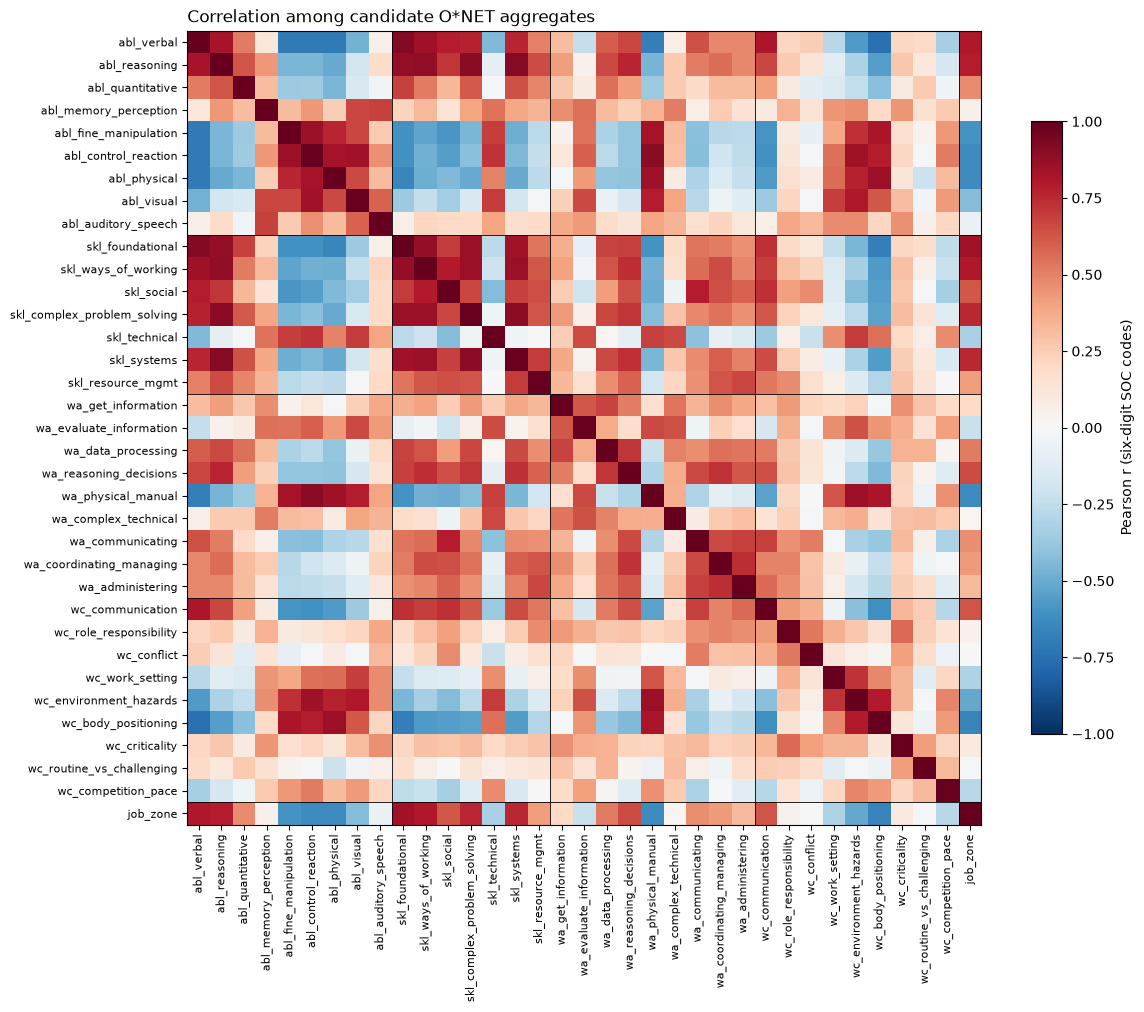

In [63]:
feature_corr = features.corr()

fig, ax = plt.subplots(figsize=(12, 10.5))
image = ax.imshow(feature_corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_corr)), feature_corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(feature_corr)), feature_corr.index, fontsize=8)

# Black lines between the domains (abilities | skills | work activities | work context | job zone)
domains_in_order = list(feature_domain.values())
boundary = 0
for domain in HEADLINE:
    boundary = boundary + domains_in_order.count(domain)
    ax.axhline(boundary - 0.5, color="k", linewidth=0.6)
    ax.axvline(boundary - 0.5, color="k", linewidth=0.6)

fig.colorbar(image, ax=ax, shrink=0.7, label="Pearson r (six-digit SOC codes)")
ax.set_title("Correlation among candidate O*NET aggregates", loc="left")
fig.tight_layout()
fig.savefig(OUT / "onet_aggregate_correlations.png", dpi=150)

In [64]:
# Every pair of features once (the upper triangle of the correlation matrix)
feature_names = list(feature_corr.columns)
pairs = []
for i in range(len(feature_names)):
    for j in range(i + 1, len(feature_names)):
        a = feature_names[i]
        b = feature_names[j]
        pairs.append({
            "feature_a": a,
            "feature_b": b,
            "r": feature_corr.iloc[i, j],
            "same_domain": feature_domain[a] == feature_domain[b],
        })
pairs = pd.DataFrame(pairs)
pairs["abs_r"] = pairs["r"].abs()

print("pairs:", len(pairs), "| |r| >= 0.9:", (pairs["abs_r"] >= 0.9).sum(), "| |r| >= 0.8:", (pairs["abs_r"] >= 0.8).sum())
within_domain = pairs.loc[pairs["same_domain"], "abs_r"].mean()
between_domains = pairs.loc[~pairs["same_domain"], "abs_r"].mean()
print(f"mean |r| within domain: {within_domain:.2f} | between domains: {between_domains:.2f}")

# Principal components: the eigenvalues of the correlation matrix give each component's share of the variance
eigenvalues = np.linalg.eigvalsh(feature_corr.to_numpy())
variance_share = np.sort(eigenvalues)[::-1] / len(feature_corr)
cumulative_share = np.cumsum(variance_share)
components_for_90 = (cumulative_share < 0.9).sum() + 1
print("variance share of the first 3 principal components:", variance_share[:3].round(3))
print("components needed for 90% of the variance:", components_for_90)

# The most strongly correlated pairs
strongest = pairs.sort_values("abs_r", ascending=False).head(6)
strongest[["feature_a", "feature_b", "r"]].round(3)

pairs: 595 | |r| >= 0.9: 4 | |r| >= 0.8: 28
mean |r| within domain: 0.43 | between domains: 0.36
variance share of the first 3 principal components: [0.396 0.228 0.074]
components needed for 90% of the variance: 12


,feature_a,feature_b,r
8,abl_verbal,skl_foundational,0.914
46,abl_reasoning,skl_systems,0.911
174,abl_control_reaction,wa_physical_manual,0.906
44,abl_reasoning,skl_complex_problem_solving,0.905
343,skl_complex_problem_solving,skl_systems,0.892
42,abl_reasoning,skl_ways_of_working,0.884


**Profiles by major group** (six-digit codes, so an occupation with many O\*NET detail rows counts once). Each aggregate
is standardised across occupations so the colours are comparable.

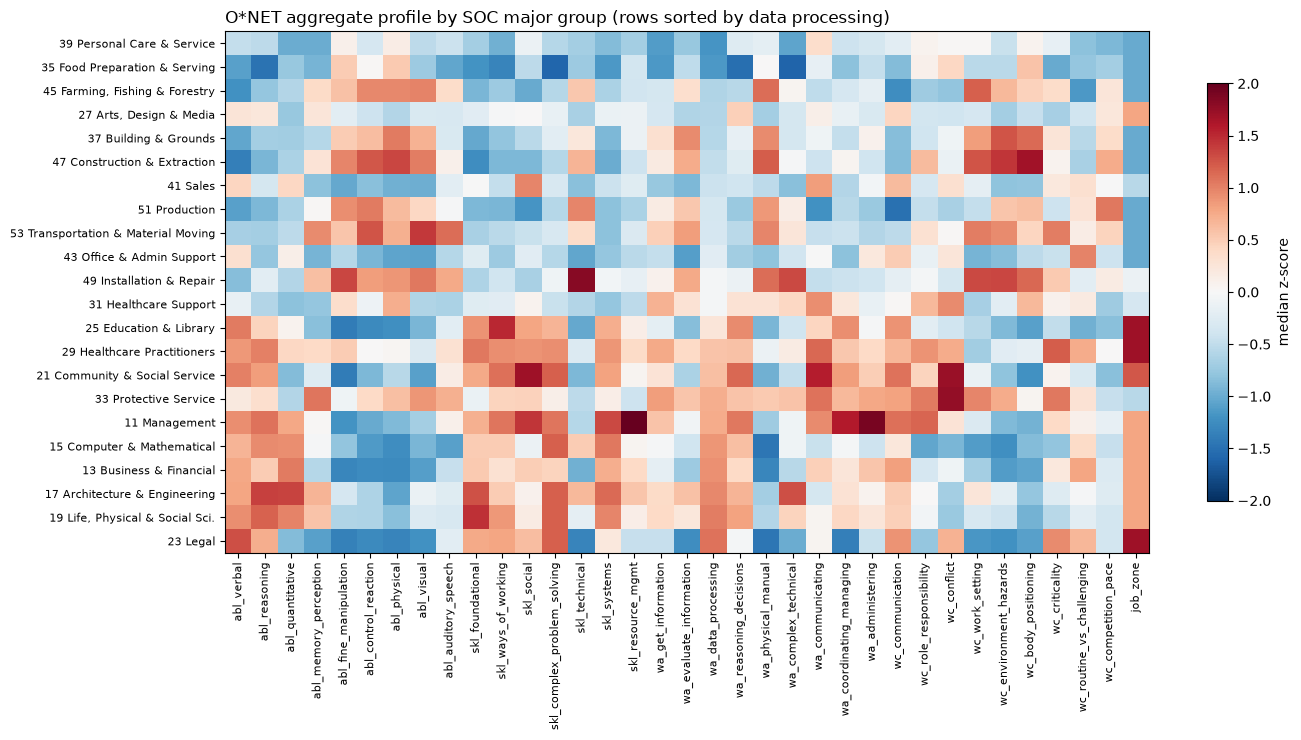

In [65]:
# Standardise each feature (z-score), then take the median per SOC major group
z_scores = (features - features.mean()) / features.std()
profile = z_scores.groupby(z_scores.index.str[:2]).median()
profile = profile.sort_values("wa_data_processing")

group_labels = []
for group in profile.index:
    group_labels.append(f"{group} {MAJOR_GROUPS[group]}")

fig, ax = plt.subplots(figsize=(14, 7.5))
image = ax.imshow(profile, cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(profile.shape[1]), profile.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(profile)), group_labels, fontsize=8)
fig.colorbar(image, ax=ax, shrink=0.8, label="median z-score")
ax.set_title("O*NET aggregate profile by SOC major group (rows sorted by data processing)", loc="left")
fig.tight_layout()
fig.savefig(OUT / "onet_aggregates_by_major_group.png", dpi=150)

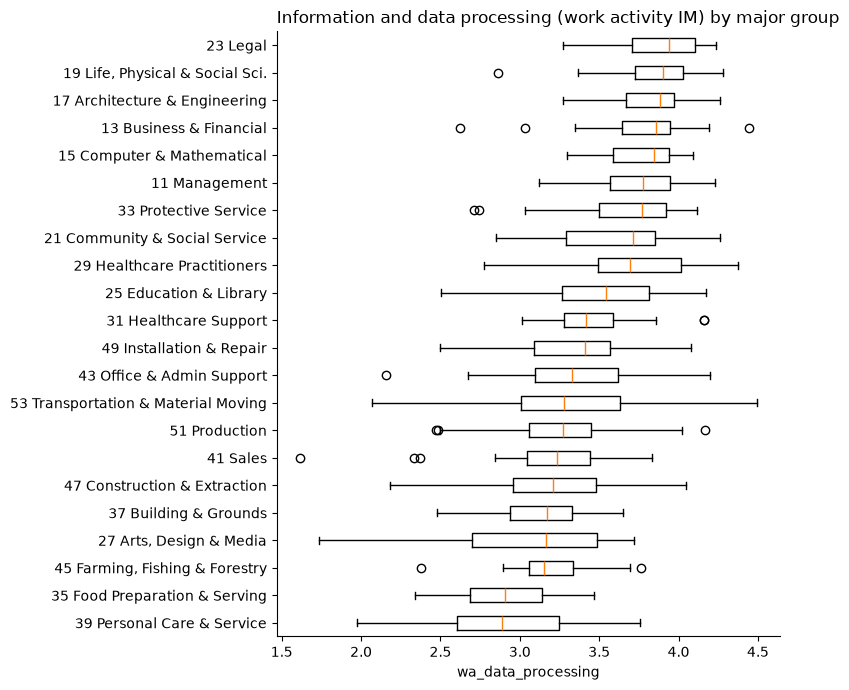

In [66]:
features_table = features.reset_index(names="soc6")
boxplot_by_group(features_table, "soc6", "wa_data_processing",
                 "Information and data processing (work activity IM) by major group")

### 7. Vintage: O\*NET 30.3 vs the 27.2 release Eloundou used
Eloundou et al. built their task ratings on O\*NET **27.2**, released **February 2023** according to the
[O\*NET release archive](https://onetcenter.org/db_releases.html). This project uses 30.3 (May 2026). `Date` records
when each rating was last updated, so it shows how much has changed since then.

In [67]:
# Are the occupations and titles the same as in Eloundou's occ_level.csv (built on O*NET 27.2)?
titles = job_zones[[CODE, "Title"]].merge(elo_raw[["O*NET-SOC Code", "Title"]], on=CODE, how="left",
                                          suffixes=("", "_eloundou"))
same_codes = set(job_zones[CODE]) == set(elo_raw["O*NET-SOC Code"])
print("job_zones codes == occ_level.csv codes:", same_codes)
print("titles that differ:", (titles["Title"] != titles["Title_eloundou"]).sum())

RELEASE_27_2 = pd.Period("2023-02", "M")

# The month each rating (and each Job Zone) was last updated
rating_month = pd.to_datetime(ratings["Date"], format="%m/%Y").dt.to_period("M")
job_zone_month = pd.to_datetime(job_zones["Date"], format="%m/%Y").dt.to_period("M")

# An occupation counts as updated if any of its rows in that file is newer than 27.2
row_is_new = rating_month > RELEASE_27_2
latest_month = rating_month.groupby([ratings["file"], ratings[CODE]]).max()
occupation_is_new = latest_month > RELEASE_27_2

vintage = pd.DataFrame({
    "share_rows_after_27_2": row_is_new.groupby(ratings["file"]).mean(),
    "occupations_updated_after_27_2": occupation_is_new.groupby("file").sum(),
})
job_zone_is_new = job_zone_month > RELEASE_27_2
vintage.loc["job_zones"] = [job_zone_is_new.mean(), job_zone_is_new.sum()]
vintage.round(3).astype({"occupations_updated_after_27_2": int})

job_zones codes == occ_level.csv codes: True
titles that differ: 0


,share_rows_after_27_2,occupations_updated_after_27_2
file,,
abilities,0.295,264
essential_skills,0.295,264
transferable_skills,0.295,264
work_activities,0.277,248
work_context,0.282,248
job_zones,0.558,515


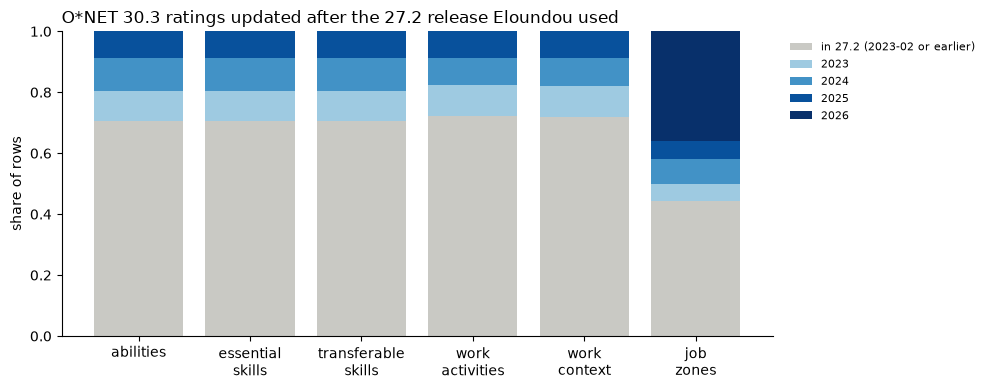

In [68]:
IN_27_2 = "in 27.2 (2023-02 or earlier)"


def release_bucket(months):
    """'in 27.2' for ratings from February 2023 or earlier, otherwise the year of the update."""
    years = months.dt.year.astype(str)
    return years.where(months > RELEASE_27_2, IN_27_2)


# Share of rows in each bucket, per file
share_by_file = pd.crosstab(release_bucket(rating_month), ratings["file"], normalize="columns")
share_job_zones = release_bucket(job_zone_month).value_counts(normalize=True).rename("job_zones")
shares = pd.concat([share_by_file, share_job_zones], axis=1).fillna(0)

# One stacked bar per file, oldest bucket at the bottom
BUCKET_COLORS = {IN_27_2: "#c9c9c4", "2023": "#9ecae1", "2024": "#4292c6", "2025": "#08519c", "2026": "#08306b"}
fig, ax = plt.subplots(figsize=(10, 4))
bottom = np.zeros(len(shares.columns))
for bucket, color in BUCKET_COLORS.items():
    if bucket not in shares.index:
        continue
    ax.bar(range(len(shares.columns)), shares.loc[bucket], bottom=bottom, color=color, label=bucket)
    bottom = bottom + shares.loc[bucket].to_numpy()

# "work_activities" -> "work\nactivities" so the labels fit under the bars
tick_labels = []
for file_name in shares.columns:
    tick_labels.append(file_name.replace("_", " ").replace(" ", "\n", 1))
ax.set_xticks(range(len(shares.columns)), tick_labels)

ax.set_ylabel("share of rows")
ax.set_title("O*NET 30.3 ratings updated after the 27.2 release Eloundou used", loc="left")
ax.legend(frameon=False, fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "onet_rating_dates.png", dpi=150)

### 8. Summary: key trends, merging, and outliers

**General trends**
- **Release:** O\*NET 30.3 (May 2026).
- **Size:** five long-format rating files (526,540 rows) cover the same **894** occupations with identical titles.
  `job_zones.csv` covers **923**.
- **Content:** 52 abilities, 35 skills, 41 work activities and 57 work-context elements, which nest into 44
  content-model groups.
- **Who rated what:** abilities and skills are 100% Analyst ratings (8 analysts, so values move in steps of 0.125).
  Work activities and context are surveys of Incumbents (~76%) and Occupational Experts (~24%).
- **Job Zones take only the values 2-5:** 331 / 212 / 226 / 154 occupations. There is **no Job Zone 1** in 30.3.
  They follow the expected education gradient: Legal and Education are mostly Zone 5; Food Preparation, Farming,
  Construction and Production are mostly Zone 2.
- **IM and LV are close to redundant:**
  - Spearman 0.98 (abilities), 0.97 (skills), 0.90 (work activities).
  - 0.96 / 0.96 / 0.89 without the Not Relevant rows.
  - Median 0.90-0.94 per element.
- **The candidate aggregates are strongly collinear:**
  - Two principal components explain 62% of their variance: a cognitive / information axis and a physical / manual axis.
  - 4 pairs have |r| ≥ 0.9, e.g. verbal abilities ~ foundational skills, reasoning abilities ~ systems skills.
  - Abilities and skills measure the same cognitive gradient twice.
- **Major-group profiles follow the same two axes:**
  - Legal, Business, Computer, Engineering and Science score high on the cognitive / information features and Job Zone.
  - Construction, Installation & Repair, Transportation and Building & Grounds score high on physical abilities,
    manual work, hazards and body positioning.
  - Community & Social Service stands out on social skills and communicating. It and Protective Service also
    score high on conflictual contact.

**Merging**
- **No crosswalk is needed.** O\*NET-SOC 2019 rolls up to SOC 2018 by truncating to `code[:7]`. 923 codes give 798
  six-digit codes, all valid SOC 2018. Never filter to `.00`: 24 six-digit codes have no `.00` row.
- **Detail rows per code:** 67 six-digit codes have more than one (up to 9 for `15-1299`). Averaging them hides real
  variation: the within-code SD is a median of 0.44× the SD across all occupations.
- **29 occupations have a Job Zone but no ratings.** 27 of them are occupations new in SOC 2018 that O\*NET has not
  surveyed yet. **All 29 are in `occ_level.csv`**, so Eloundou scored them without O\*NET features to match.
  - 24 of them leave a six-digit Eloundou code with **no features**, e.g. Project Management Specialists, Financial
    and Investment Analysts, Paramedics, Taxi Drivers.
  - The other 5 (Data Scientists, Penetration Testers, Blockchain Engineers, Digital Forensics Analysts,
    Web and Digital Interface Designers) sit in partly rated codes (`15-1255`, `15-1299`, `15-2051`). Those codes keep
    features from rated siblings, but **Eloundou's six-digit score averages in an occupation the O\*NET features leave out**.
- **Feature coverage of each index table:**
  - Eloundou 774 of 798 codes.
  - AIOE 771 of 800 (10 are "All Other" codes O\*NET does not profile).
  - Frey-Osborne 680 of 699.
  - Which rows of the merged table lose features is left to the coverage report (issue #15).
- **Vintage:** the taxonomy is the same as Eloundou's 27.2 (identical 923 codes and titles). The ratings are not:
  ~28-30% of occupations' ratings and 56% of Job Zones were updated after 27.2 (Feb 2023).

**Outliers and data quality**
- **No defects:**
  - no duplicates on code × element × scale × category
  - complete grid
  - no out-of-range values or CI bounds
  - no missing headline values
  - category percentages sum to 100 (±0.02)
  - CX equals their weighted mean
- **Structural blanks:** every missing precision field has a structural cause.
  - Occupational Expert rows publish no SE, CI or suppress flag.
  - Analyst - Transition rows have no N.
  - The 42,578 Incumbent rows without CIs all have SE = 0.
- **Recommend Suppress = Y** is on 8,762 rows (1.7%), almost all LV or category percentages. **Only 19 headline
  (IM/CX) values are flagged, in 8 occupations.**
- **Not Relevant = Y** is on 11,887 LV rows, with LV ≈ 0 and IM ≈ 1, which is consistent.
- **Low N is not an issue:** only 2 survey rows have N < 10.
- **Statistical outliers** (per-element 1.5×IQR, median 0.1-0.6% per element) sit in specialised elements
  (Installation, Category Flexibility, Exposed to Disease) where a few occupations genuinely score high. Keep them.
- **Structural outliers in the grouping:**
  - Body Positioning mixes *sitting* and *standing* (r = -0.97).
  - Work Setting mixes *indoors* and *open vehicle / outdoors* (r = -0.69).
  - Routine vs Challenging, Auditory & Speech, Technical Skills and Complex & Technical Activities also contain
    opposite-signed elements, so a plain mean is not a valid aggregate for them.

**Decisions for the rest of the project (Milestone 3 feature build)**
1. **Scale:** use IM for abilities, skills and work activities, and CX for work context. Drop LV, the category
   percentages and the two CT schedule items.
2. **Suppressed / Not Relevant values:** keep them. Only 19 headline values are flagged and none are missing. Record a
   per-occupation count of flagged values instead of masking them.
3. **Roll-up:** `soc6 = code[:7]`, unweighted mean over rated detail occupations. Keep `n_children`, `n_rated` and a
   partial-coverage flag for `15-1255`, `15-1299` and `15-2051`.
4. **Occupations without features:** the disagreement model cannot use index rows with no O\*NET features. The
   coverage report (issue #15) should count them; exclude them, or impute from the SOC broad group and flag them.
5. **Features:** start from the 34 aggregates above plus Job Zone (35 columns). Before modelling:
   - Sign-align or split the incoherent groups.
   - Use grouped permutation importance or ~10-12 principal components rather than single Random-Forest
     importances, because of the collinearity.
6. **Job Zone:** treat it as ordinal 2-5. DATA-DICTIONARY §3 (`job_zone int 1-5`) should be updated.
7. **Vintage:** keep 30.3. Taxonomy is identical and the data is newer. State in the memo that ~30% of occupations'
   features post-date Eloundou's 27.2 snapshot. Rebuilding the features from the 27.2 archive is an optional
   robustness check.

**Limitations and follow-ups**
- **No task data:** Task Statements and Task Ratings are not in `data/raw/`, so task-level analysis is not covered here.
  Suggested follow-up issue: add and profile them, since Eloundou's scores are built from exactly those tasks.
- **Unweighted:** all statistics are unweighted across occupations, not employment-weighted (DATA-DICTIONARY §4.3).
- **Work-context levels:** CX items use different response anchors (frequency, importance, degree), so a work-context
  aggregate's level is not interpretable, only its ranking.

### EDA techniques applied (O\*NET)

| Technique | What it was used for | Section |
|---|---|---|
| Version and source metadata | README version, `Date` ranges, `Domain Source` crosstab | 1 |
| Inventory (shape, columns, dtypes, cardinality) | Codes, elements and scales per file | 1 |
| Grouped range summaries | Min/median/max per file × scale | 1 |
| Hierarchy parsing of Element IDs | Content-model groups for aggregation | 1 |
| Missing-value profile by source and scale | Separating structural blanks from real gaps | 2 |
| Duplicate-key and grid-completeness checks | code × element × scale × category | 2 |
| Range validation | Data values vs CI bounds, reported separately | 2 |
| Internal-consistency checks | Category percentages sum to 100; CX = weighted category mean | 2 |
| Precision-flag table | Recommend Suppress, Not Relevant, low N, wide CI | 2 |
| Per-element 1.5×IQR rule | Statistical outliers within each element | 2 |
| Set comparison | Rated vs job-zone codes; codes vs SOC 2018 and Eloundou | 3, 5, 7 |
| Histograms stacked by flag | IM/LV shape and the Not Relevant spike | 4 |
| Spearman correlation + hexbin | IM vs LV redundancy | 4 |
| Stacked bar charts | Job Zone counts and mix by major group | 4 |
| Long → wide pivot and roll-up | Six-digit feature frame; within vs between SD | 5 |
| Join-coverage table | Which index-table codes have O\*NET features | 5 |
| Inter-element correlation | Coherence of each candidate aggregate | 6 |
| Correlation heatmap + eigenvalues | Redundancy among aggregates | 6 |
| z-score heatmap and boxplot by major group | Occupational profiles | 6 |
| Date-based vintage analysis | Ratings updated after O\*NET 27.2 | 7 |

## Part 6 — BLS Employment Projections 2025-35 (`occupation.xlsx`)

The BLS Employment Projections workbook gives, for every occupation, employment in 2025, projected employment in 2035,
wages, typical entry requirements, and the reasons BLS expects an occupation's share of employment to change.
The project can use it in two ways:
- **Employment weights.** DATA-DICTIONARY §4.3: an unweighted occupation-level statistic is not an employment-weighted
  one, and every result should say which it is. This file supplies the weights.
- **The stretch check against projected employment change** (DATA-DICTIONARY §3 `emp_change_pct_2024_34`, Milestone 3).

This part checks whether the file is fit for those uses and records what the team needs to decide. It profiles the
BLS data only: **no AI-exposure index scores appear here.** Comparing exposure or agreement with employment change
belongs to later issues and to Milestone 3.

| Sheet | What it is |
|---|---|
| Table 1.2 | **The main table:** one row per occupation, with employment, change, self-employment, openings, wage and entry requirements |
| Tables 1.1, 1.3-1.6 | Extracts of Table 1.2: major groups, and the 30 fastest-growing / most-growing / fastest-declining / most-declining occupations |
| Table 1.8, 1.9 | Links to the detailed industry-occupation matrix (no data) |
| Table 1.10 | Separations (labour-force exits and occupational transfers) and openings |
| Table 1.11 | STEM vs non-STEM totals |
| Table 1.12 | Factors affecting occupational utilization: BLS's written reason for each projected change in an occupation's share |

**Analysis decisions**
- **Line items only.** Table 1.2 mixes detailed occupations ("Line item") with subtotal rows ("Summary"). All
  statistics use the line items; summary rows are used only to check totals.
- **Weighting is always stated.** *Unweighted* = each occupation counts once. *Employment-weighted* = each occupation
  counts in proportion to its 2025 employment.
- **Employment is in thousands**, as published.

### 1. Load, version and structure

In [69]:
BLS_FILE = data_file("raw/occupation.xlsx")
workbook = pd.ExcelFile(BLS_FILE)

# Every sheet has a title in its first row and column headers in its second.
# Data rows have a value in the second column; footnote rows do not.
sheet_inventory = []
for sheet in workbook.sheet_names:
    if sheet == "Index":  # table of contents
        continue
    raw_sheet = pd.read_excel(workbook, sheet_name=sheet, header=None)
    body = raw_sheet.iloc[2:]
    is_data_row = body[1].notna()
    sheet_inventory.append({
        "sheet": sheet,
        "title": raw_sheet.iloc[0, 0],
        "columns": raw_sheet.shape[1],
        "data_rows": is_data_row.sum(),
        "footnote_rows": (~is_data_row).sum(),
    })
pd.DataFrame(sheet_inventory)

,sheet,title,columns,data_rows,footnote_rows
0,Table 1.1,"Table 1.1 Employment by major occupational group, 2025 and project...",7,23,4
1,Table 1.2,"Table 1.2 Occupational projections, 2025–35, and worker characteri...",17,1112,5
2,Table 1.3,"Table 1.3 Fastest growing occupations, 2025 and projected 2035 (Em...",7,31,3
3,Table 1.4,"Table 1.4 Occupations with the most job growth, 2025 and projected...",7,31,3
4,Table 1.5,"Table 1.5 Fastest declining occupations, 2025 and projected 2035 (...",7,31,3
5,Table 1.6,"Table 1.6 Occupations with the largest job declines, 2025 and proj...",7,31,3
6,Table 1.8,"Table 1.8 2025–35 Industry-occupation matrix data, by occupation",4,1112,1
7,Table 1.9,"Table 1.9 2025–35 Industry-occupation matrix data, by industry",4,423,1
8,Table 1.10,"Table 1.10 Occupational separations and openings, projected 2025–3...",14,1112,3
9,Table 1.11,"Table 1.11 Employment in STEM occupations, 2025 and projected 2035...",6,3,5


**Vintage.** The titles say **2025-35**, with 2025 employment and 2025 wages. The project overview and
DATA-DICTIONARY §3 (`emp_change_pct_2024_34`) name the previous 2024-34 edition, so that column name should be updated.

In [70]:
# Short names for the long BLS column headers (used for every sheet)
COLUMN_NAMES = {
    "2025 National Employment Matrix title": "title",
    "2025 National Employment Matrix code": "code",
    "Occupation type": "occ_type",
    "Employment, 2025": "emp_2025",
    "Employment, 2035": "emp_2035",
    "Employment distribution, percent, 2025": "emp_share_2025",
    "Employment distribution, percent, 2035": "emp_share_2035",
    "Employment change, numeric, 2025–35": "emp_change",
    "Employment change, percent, 2025–35": "emp_change_pct",
    "Percent self-employed, 2025": "self_employed_pct",
    "Occupational openings, 2025–35 annual average": "openings",
    "Median annual wage, dollars, 2025": "median_wage",
    "Typical education needed for entry": "education",
    "Work experience in a related occupation": "experience",
    "Typical on-the-job training needed to attain competency in the occupation": "training",
    "Related Occupational Outlook Handbook (OOH) content": "ooh",
    "Related Occupational Outlook Handbook (OOH) content.1": "ooh_link",
    "Labor force exit rate, 2025–35 annual average": "exit_rate",
    "Occupational transfer rate, 2025–35 annual average": "transfer_rate",
    "Total occupational separations rate, 2025–35 annual average": "separation_rate",
    "Labor force exits, 2025–35 annual average": "exits",
    "Occupational transfers, 2025–35 annual average": "transfers",
    "Total occupational separations, 2025–35 annual average": "separations",
    "2025 National Employment Matrix occupation title": "title",
    "2025 National Employment Matrix occupation code": "code",
    "2025 National Employment Matrix industry title": "industry",
    "2025 National Employment Matrix industry code": "industry_code",
    "Factors affecting occupational utilization": "factor",
}


def read_bls_table(sheet):
    """One occupation sheet of occupation.xlsx, with short column names and the footnote rows dropped.

    Only "—" and empty cells mean missing. pandas' default missing-value list is switched off because it also
    turns the real answer "None" (no experience / no training needed) into a blank.
    """
    table = pd.read_excel(BLS_FILE, sheet_name=sheet, header=1, keep_default_na=False, na_values=["—", ""])
    table = table.rename(columns=COLUMN_NAMES)
    is_occupation_row = table["code"].astype(str).str.fullmatch(r"\d{2}-\d{4}")
    return table[is_occupation_row].reset_index(drop=True)


projections = read_bls_table("Table 1.2")

# BLS shows the hierarchy by indenting titles, two spaces per level
leading_spaces = projections["title"].str.len() - projections["title"].str.lstrip().str.len()
projections["level"] = leading_spaces // 2
projections["title"] = projections["title"].str.strip()
projections["major_group"] = projections["code"].str[:2]

print("occupation rows:", len(projections))
print(pd.crosstab(projections["level"], projections["occ_type"]).to_string())
projections.dtypes

occupation rows: 1112
occ_type  Line item  Summary
level                       
0                 0        1
1                 0       22
2                 0       95
3               313      163
4               518        0


title                    str
code                     str
occ_type                 str
emp_2025             float64
emp_2035             float64
emp_share_2025       float64
emp_share_2035       float64
emp_change           float64
emp_change_pct       float64
self_employed_pct    float64
openings             float64
median_wage          float64
education                str
experience               str
training                 str
ooh                      str
ooh_link                 str
level                  int64
major_group              str
dtype: object

Level 0 is the total, level 1 the 22 major groups, levels 2-3 minor and broad groups. Detailed occupations sit at
level 3 or 4, depending on whether BLS publishes their broad group.

In [71]:
# The two kinds of row
occupations = projections[projections["occ_type"] == "Line item"].copy()
summary_rows = projections[projections["occ_type"] == "Summary"].copy()
print("line items (detailed occupations):", len(occupations), "| summary rows:", len(summary_rows))

# The categorical columns and their values (line items)
for column in ["education", "experience", "training"]:
    print(f"\n{column}:")
    print(occupations[column].value_counts(dropna=False).to_string())

line items (detailed occupations): 831 | summary rows: 281

education:
education
High school diploma or equivalent    326
Bachelor's degree                    177
No formal educational credential     109
Doctoral or professional degree       73
Postsecondary nondegree award         51
Associate's degree                    48
Master's degree                       40
Some college, no degree                7

experience:
experience
None                 716
Less than 5 years     87
5 years or more       28

training:
training
None                                 321
Moderate-term on-the-job training    231
Short-term on-the-job training       174
Long-term on-the-job training         54
Internship/residency                  36
Apprenticeship                        15


### 2. Integrity checks
**Missing values, duplicates and value ranges.**

In [72]:
# Blank cells ("—") per column, for line items and summary rows separately
missing = pd.DataFrame({
    "line items": occupations.isna().sum(),
    "summary rows": summary_rows.isna().sum(),
})
missing = missing[missing.sum(axis=1) > 0]
print(missing.to_string())

# Which occupations have no wage?
print("\nno median wage:", occupations.loc[occupations["median_wage"].isna(), "title"].tolist())

# Which major groups have the occupations without a self-employment share?
no_self_employed = occupations[occupations["self_employed_pct"].isna()]
print("no self-employment share, by major group:", no_self_employed["major_group"].value_counts().head(6).to_dict())

                   line items  summary rows
self_employed_pct         197            23
median_wage                 6             3
education                   0           281
experience                  0           281
training                    0           281
ooh                       225           281
ooh_link                  225           281

no median wage: ['Actors', 'Dancers', 'Musicians and singers', 'Disc jockeys, except radio', 'Entertainers and performers, sports and related workers, all other', 'Fishing and hunting workers']
no self-employment share, by major group: {'51': 34, '25': 24, '53': 20, '33': 17, '43': 15, '47': 14}


In [73]:
# Duplicates and code format
print("duplicate codes:", projections["code"].duplicated().sum())
print("duplicate titles among line items:", occupations["title"].duplicated().sum())
# A summary row whose only child is one line item can share its title (e.g. Cashiers)
repeated_titles = projections.loc[projections["title"].duplicated(), "title"].tolist()
print("titles shared by a summary row and its single line item:", repeated_titles)

# Value ranges: employment positive, percentages between 0 and 100, wages positive
print("employment 2025 <= 0:", (occupations["emp_2025"] <= 0).sum())
print("employment 2035 <= 0:", (occupations["emp_2035"] <= 0).sum())
print("self-employed % outside 0-100:", (~occupations["self_employed_pct"].dropna().between(0, 100)).sum())
print("wage <= 0:", (occupations["median_wage"] <= 0).sum())
print("openings < 0:", (occupations["openings"] < 0).sum())
occupations[["emp_2025", "emp_2035", "emp_change", "emp_change_pct", "self_employed_pct", "openings",
             "median_wage"]].describe().T.round(1)

duplicate codes: 0
duplicate titles among line items: 0
titles shared by a summary row and its single line item: ['Tour and travel guides', 'Cashiers', 'Fishing and hunting workers']
employment 2025 <= 0: 0
employment 2035 <= 0: 0
self-employed % outside 0-100: 0
wage <= 0: 0
openings < 0: 0


,count,mean,std,min,25%,50%,75%,max
emp_2025,831.0,204.9,470.9,0.2,16.5,50.4,164.0,4677.1
emp_2035,831.0,212.0,491.2,0.2,16.5,51.4,168.1,5524.4
emp_change,831.0,7.1,39.7,-200.6,-0.1,0.8,5.4,847.3
emp_change_pct,831.0,2.1,7.2,-34.4,-0.4,2.7,5.5,41.0
self_employed_pct,634.0,9.6,15.7,0.0,0.9,2.8,9.8,94.6
openings,831.0,21.0,61.7,0.0,1.4,4.1,14.0,827.4
median_wage,825.0,75010.8,52548.8,30890.0,47120.0,61390.0,81490.0,559030.0


**Internal consistency.** Several columns are derived from others, so they can be recomputed. Small gaps are expected
because BLS rounds the published numbers (employment to the nearest hundred jobs).

In [74]:
total_2025 = projections.loc[projections["code"] == "00-0000", "emp_2025"].iloc[0]
total_2035 = projections.loc[projections["code"] == "00-0000", "emp_2035"].iloc[0]

# Change = 2035 employment - 2025 employment
change_gap = (occupations["emp_2035"] - occupations["emp_2025"] - occupations["emp_change"]).abs()
print(f"numeric change: max gap {change_gap.max():.2f} thousand")

# Percent change, recomputed from the rounded employment figures
recomputed_pct = 100 * (occupations["emp_2035"] - occupations["emp_2025"]) / occupations["emp_2025"]
pct_gap = (recomputed_pct - occupations["emp_change_pct"]).abs()
is_large = occupations["emp_2025"] >= 10  # 10,000 jobs or more
print(f"percent change: max gap {pct_gap.max():.1f} points overall, {pct_gap[is_large].max():.2f} for occupations "
      f"with 10,000+ jobs")

# Employment share = employment / total
share_gap = (100 * occupations["emp_2025"] / total_2025 - occupations["emp_share_2025"]).abs()
print(f"employment share: max gap {share_gap.max():.3f} points")

# Line items should add up to the total, and to each major group's summary row
print(f"line items sum to {occupations['emp_2025'].sum():,.1f} thousand vs total {total_2025:,.1f} (2025)")
major_group_rows = summary_rows[summary_rows["level"] == 1].set_index("major_group")
line_item_sums = occupations.groupby("major_group")["emp_2025"].sum()
group_gap = (line_item_sums - major_group_rows["emp_2025"]).abs()
print(f"major groups: max gap between line-item sum and summary row: {group_gap.max():.1f} thousand")

numeric change: max gap 0.10 thousand
percent change: max gap 7.3 points overall, 0.82 for occupations with 10,000+ jobs
employment share: max gap 0.050 points
line items sum to 170,267.2 thousand vs total 170,280.8 (2025)
major groups: max gap between line-item sum and summary row: 13.4 thousand


In [75]:
# Table 1.10: openings = separations + growth, and separations = exits + transfers
separations = read_bls_table("Table 1.10")
separations = separations[separations["occ_type"] == "Line item"]
openings_gap = (separations["separations"] + separations["emp_change"] / 10 - separations["openings"]).abs()
separations_gap = (separations["exits"] + separations["transfers"] - separations["separations"]).abs()
print(f"openings = separations + change / 10: max gap {openings_gap.max():.2f} thousand")
print(f"separations = exits + transfers: max gap {separations_gap.max():.2f} thousand")

# The other occupation tables repeat Table 1.2. Do their numbers match it exactly?
SHARED_COLUMNS = ["emp_2025", "emp_2035", "emp_change", "emp_change_pct"]
main = projections.set_index("code")
for sheet in ["Table 1.1", "Table 1.3", "Table 1.4", "Table 1.5", "Table 1.6", "Table 1.10"]:
    table = read_bls_table(sheet).set_index("code")
    in_main = table.index.isin(main.index).all()
    differences = (table[SHARED_COLUMNS] - main.loc[table.index, SHARED_COLUMNS]).abs().max().max()
    print(f"{sheet:<10} rows: {len(table):>5} | all codes in Table 1.2: {in_main} | max difference: {differences}")

# Tables 1.3-1.6 should be the top 30 line items of Table 1.2 by their measure
TOP_30 = {
    "Table 1.3": ("emp_change_pct", False),
    "Table 1.4": ("emp_change", False),
    "Table 1.5": ("emp_change_pct", True),
    "Table 1.6": ("emp_change", True),
}
for sheet, (column, ascending) in TOP_30.items():
    listed = set(read_bls_table(sheet)["code"]) - {"00-0000"}
    top = set(occupations.sort_values(column, ascending=ascending)["code"].head(30))
    print(f"{sheet}: {len(listed & top)} of 30 match the top 30 of Table 1.2 by {column}")

openings = separations + change / 10: max gap 0.10 thousand
separations = exits + transfers: max gap 0.10 thousand
Table 1.1  rows:    23 | all codes in Table 1.2: True | max difference: 0.0


Table 1.3  rows:    31 | all codes in Table 1.2: True | max difference: 0.0
Table 1.4  rows:    31 | all codes in Table 1.2: True | max difference: 0.0


Table 1.5  rows:    31 | all codes in Table 1.2: True | max difference: 0.0


Table 1.6  rows:    31 | all codes in Table 1.2: True | max difference: 0.0


Table 1.10 rows:  1112 | all codes in Table 1.2: True | max difference: 0.0
Table 1.3: 30 of 30 match the top 30 of Table 1.2 by emp_change_pct


Table 1.4: 30 of 30 match the top 30 of Table 1.2 by emp_change
Table 1.5: 30 of 30 match the top 30 of Table 1.2 by emp_change_pct


Table 1.6: 30 of 30 match the top 30 of Table 1.2 by emp_change


**Outliers.** Employment and wages are strongly right-skewed, so the 1.5×IQR rule is applied on a log scale as well.

In [76]:
def outlier_count(values):
    """Number of values outside 1.5 x IQR."""
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    return ((values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)).sum()


outliers = []
for column in ["emp_2025", "emp_change_pct", "median_wage", "self_employed_pct", "openings"]:
    values = occupations[column].dropna()
    row = {"column": column, "values": len(values), "outliers (raw scale)": outlier_count(values)}
    if (values > 0).all():  # a log scale only works for positive values
        row["outliers (log scale)"] = outlier_count(np.log10(values))
    else:
        row["outliers (log scale)"] = "-"
    outliers.append(row)
print(pd.DataFrame(outliers).to_string(index=False))


def print_extremes(label, rows, column):
    """One line per occupation: title (value)."""
    print(f"\n{label}:")
    for title, value in zip(rows["title"], rows[column]):
        print(f"  {title} ({value:,})")


print_extremes("largest (thousand jobs)", occupations.nlargest(3, "emp_2025"), "emp_2025")
print_extremes("smallest (thousand jobs)", occupations.nsmallest(3, "emp_2025"), "emp_2025")
print_extremes("highest median wage", occupations.nlargest(3, "median_wage"), "median_wage")
print_extremes("lowest median wage", occupations.nsmallest(3, "median_wage"), "median_wage")
print_extremes("fastest projected growth (%)", occupations.nlargest(3, "emp_change_pct"), "emp_change_pct")
print_extremes("fastest projected decline (%)", occupations.nsmallest(3, "emp_change_pct"), "emp_change_pct")

           column  values  outliers (raw scale) outliers (log scale)
         emp_2025     831                   110                    1
   emp_change_pct     831                    80                    -
      median_wage     825                    57                   25
self_employed_pct     634                    81                    -
         openings     831                   113                    -

largest (thousand jobs):
  Home health and personal care aides (4,677.1)
  Retail salespersons (3,998.1)
  Fast food and counter workers (3,855.9)

smallest (thousand jobs):
  Timing device assemblers and adjusters (0.2)
  Patternmakers, wood (0.6)
  Model makers, wood (0.7)

highest median wage:
  Pediatric surgeons (559,030.0)
  Cardiologists (496,010.0)
  Radiologists (420,860.0)

lowest median wage:
  Cooks, fast food (30,890.0)
  Fast food and counter workers (31,200.0)
  Hosts and hostesses, restaurant, lounge, and coffee shop (31,200.0)

fastest projected growth (%):
  Nu

### 3. Identifiers: BLS codes vs SOC 2018
The BLS National Employment Matrix uses SOC 2018 codes, but publishes some groups of occupations as a single
line item with its own code (e.g. `31-1120` Home health and personal care aides = `31-1121` + `31-1122`). Any join on
`soc2018` needs to know which codes these are.

In [77]:
soc2018_titles = cw.drop_duplicates("soc18").set_index("soc18")["title18"]
soc2018_codes = set(soc2018_titles.index)
bls_codes = set(occupations["code"])

# BLS line items that are not SOC 2018 detailed codes: these are BLS's combined codes
combined_codes = sorted(bls_codes - soc2018_codes)
print("BLS line items:", len(bls_codes), "| SOC 2018 detailed codes:", len(bls_codes & soc2018_codes),
      "| BLS combined codes:", len(combined_codes))

# SOC 2018 codes with no line item of their own. Each should belong to a combined code in the same
# broad group (same first five digits), unless BLS does not publish it at all.
mapping = []
for soc_code in sorted(soc2018_codes):
    if soc_code in bls_codes:
        mapping.append({"soc2018": soc_code, "bls_code": soc_code, "match": "direct"})
        continue
    same_broad_group = []
    for bls_code in combined_codes:
        if bls_code[:6] == soc_code[:6]:
            same_broad_group.append(bls_code)
    assert len(same_broad_group) <= 1, soc_code
    if same_broad_group:
        mapping.append({"soc2018": soc_code, "bls_code": same_broad_group[0], "match": "via combined code"})
    else:
        mapping.append({"soc2018": soc_code, "bls_code": None, "match": "not in BLS"})
mapping = pd.DataFrame(mapping)
mapping["title_2018"] = mapping["soc2018"].map(soc2018_titles)
print(mapping["match"].value_counts().to_string())

not_in_bls = mapping[mapping["match"] == "not in BLS"]
is_military = not_in_bls["soc2018"].str.startswith("55")
print("not in BLS:", is_military.sum(), "military codes +", not_in_bls.loc[~is_military, "title_2018"].tolist())

BLS line items: 831 | SOC 2018 detailed codes: 819 | BLS combined codes: 12
match
direct               819
via combined code     28
not in BLS            20
not in BLS: 19 military codes + ['Legislators']


In [78]:
# Every combined code, and the SOC 2018 occupations it stands for
bls_titles = occupations.set_index("code")["title"]
combined = mapping[mapping["match"] == "via combined code"]
combined_table = []
for bls_code in combined_codes:
    children = combined[combined["bls_code"] == bls_code]
    combined_table.append({
        "bls_code": bls_code,
        "bls_title": bls_titles[bls_code],
        "emp_2025": occupations.set_index("code").loc[bls_code, "emp_2025"],
        "n_soc2018": len(children),
        "soc2018_codes": ", ".join(children["soc2018"]),
    })
combined_table = pd.DataFrame(combined_table)
assert (combined_table["n_soc2018"] >= 2).all(), "a combined code covers fewer than two SOC codes"
combined_table

,bls_code,bls_title,emp_2025,n_soc2018,soc2018_codes
0,13-1020,Buyers and purchasing agents,516.1,3,"13-1021, 13-1022, 13-1023"
1,13-2020,Property appraisers and assessors,68.4,2,"13-2022, 13-2023"
2,21-1018,"Substance abuse, behavioral disorder, and mental health counselors",533.4,2,"21-1011, 21-1014"
3,25-2052,"Special education teachers, kindergarten and elementary school",259.1,2,"25-2055, 25-2056"
4,25-9045,"Teaching assistants, except postsecondary",1463.0,3,"25-9042, 25-9043, 25-9049"
5,29-2010,Clinical laboratory technologists and technicians,343.0,2,"29-2011, 29-2012"
6,31-1120,Home health and personal care aides,4677.1,2,"31-1121, 31-1122"
7,39-7010,Tour and travel guides,62.2,2,"39-7011, 39-7012"
8,47-4090,Miscellaneous construction and related workers,29.5,2,"47-4091, 47-4099"
9,51-2028,"Electrical, electronic, and electromechanical assemblers, except c...",246.3,2,"51-2022, 51-2023"


**Code coverage of the index tables.** How many six-digit codes of each Milestone 1 index table can find a BLS row.
These are counts of codes only; which rows of the merged table are affected is left to the coverage report (issue #15).

In [79]:
INDEX_TABLES = {
    "eloundou_soc6": ("interim/eloundou_soc6.csv", "soc6"),
    "aioe_soc2018": ("interim/aioe_soc2018.csv", "soc2018"),
    "frey_osborne_soc2018": ("interim/frey_osborne_soc2018.csv", "soc2018"),
}
match_of = mapping.set_index("soc2018")["match"]

bls_coverage = []
for table_name, (path, code_column) in INDEX_TABLES.items():
    index_codes = set(pd.read_csv(data_file(path), dtype={code_column: str})[code_column])
    matches = []
    for index_code in index_codes:
        matches.append(match_of.get(index_code, "not a SOC 2018 code"))
    bls_coverage.append({
        "table": table_name,
        "codes": len(matches),
        "direct": matches.count("direct"),
        "via combined code": matches.count("via combined code"),
        "not in BLS": matches.count("not in BLS"),
        "not a SOC 2018 code": matches.count("not a SOC 2018 code"),
    })
pd.DataFrame(bls_coverage).set_index("table")

,codes,direct,via combined code,not in BLS,not a SOC 2018 code
table,,,,,
eloundou_soc6,798,772,25,1,0
aioe_soc2018,800,773,27,0,0
frey_osborne_soc2018,699,675,24,0,0


### 4. Distributions and relationships

In [80]:
def weighted_mean(values, weights):
    """Mean of values, each counted in proportion to its weight (rows with a blank value are skipped)."""
    has_value = values.notna()
    return (values[has_value] * weights[has_value]).sum() / weights[has_value].sum()


# The same statistic unweighted (each occupation once) and employment-weighted (each job once)
weights = occupations["emp_2025"]
summary_stats = []
for column in ["emp_change_pct", "median_wage", "self_employed_pct"]:
    summary_stats.append({
        "column": column,
        "unweighted mean": occupations[column].mean(),
        "unweighted median": occupations[column].median(),
        "employment-weighted mean": weighted_mean(occupations[column], weights),
        "skew": occupations[column].skew(),
    })
print("total projected change:", round(100 * (total_2035 - total_2025) / total_2025, 2), "%")
top_10_share = occupations["emp_2025"].nlargest(10).sum() / occupations["emp_2025"].sum()
print(f"share of all jobs in the 10 largest occupations: {top_10_share:.1%}")
print(f"share of occupations projected to decline: {(occupations['emp_change_pct'] < 0).mean():.1%} "
      f"(employment-weighted: {weighted_mean((occupations['emp_change_pct'] < 0).astype(float), weights):.1%})")
pd.DataFrame(summary_stats).round(2)

total projected change: 3.48 %
share of all jobs in the 10 largest occupations: 19.8%
share of occupations projected to decline: 27.9% (employment-weighted: 25.5%)


,column,unweighted mean,unweighted median,employment-weighted mean,skew
0,emp_change_pct,2.08,2.70,3.48,-0.25
1,median_wage,75010.85,61390.00,64572.80,4.15
2,self_employed_pct,9.57,2.85,6.24,2.61


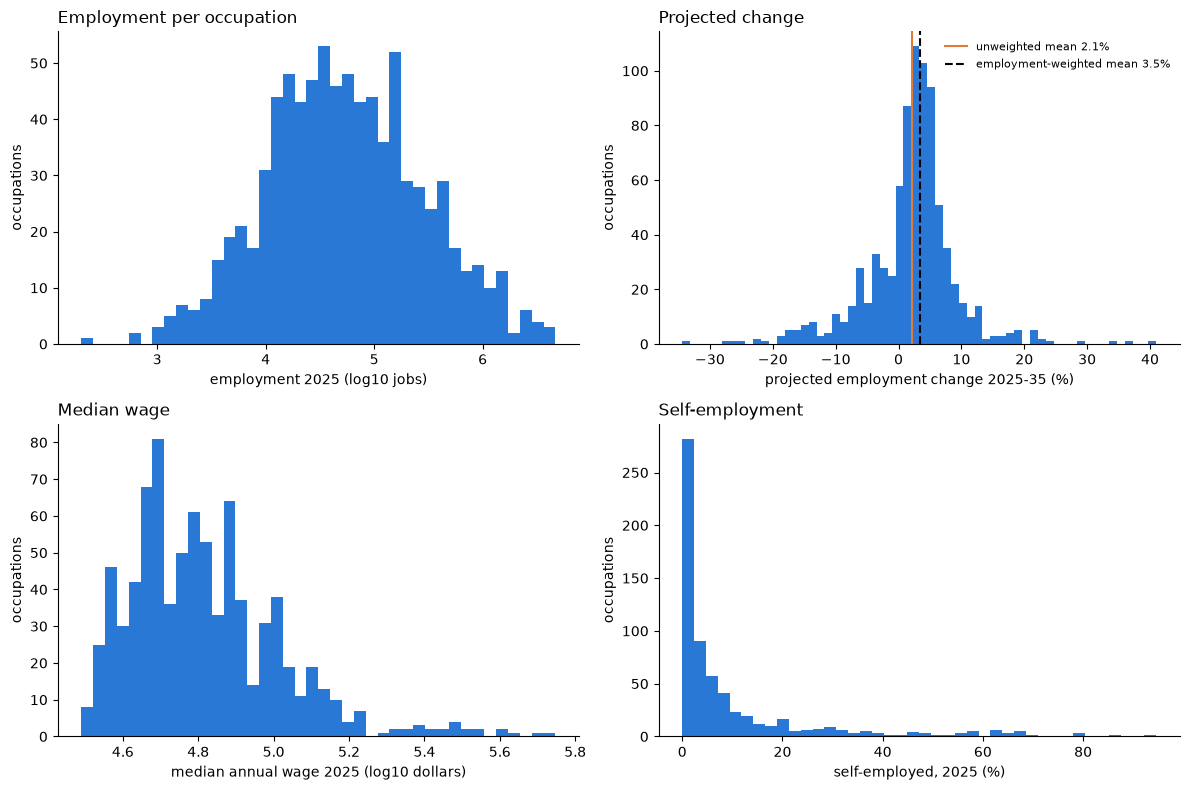

In [81]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Employment (log scale: from a few hundred jobs to several million)
axes[0, 0].hist(np.log10(occupations["emp_2025"] * 1000), bins=40, color="#2a78d6")
axes[0, 0].set_xlabel("employment 2025 (log10 jobs)")
axes[0, 0].set_title("Employment per occupation", loc="left")

# Projected change, with the unweighted and employment-weighted means
change = occupations["emp_change_pct"]
axes[0, 1].hist(change, bins=60, color="#2a78d6")
axes[0, 1].axvline(change.mean(), color="#e07b39", label=f"unweighted mean {change.mean():.1f}%")
axes[0, 1].axvline(weighted_mean(change, weights), color="k", linestyle="--",
                   label=f"employment-weighted mean {weighted_mean(change, weights):.1f}%")
axes[0, 1].set_xlabel("projected employment change 2025-35 (%)")
axes[0, 1].set_title("Projected change", loc="left")
axes[0, 1].legend(frameon=False, fontsize=8)

# Median wage (log scale)
axes[1, 0].hist(np.log10(occupations["median_wage"].dropna()), bins=40, color="#2a78d6")
axes[1, 0].set_xlabel("median annual wage 2025 (log10 dollars)")
axes[1, 0].set_title("Median wage", loc="left")

# Self-employment
axes[1, 1].hist(occupations["self_employed_pct"].dropna(), bins=40, color="#2a78d6")
axes[1, 1].set_xlabel("self-employed, 2025 (%)")
axes[1, 1].set_title("Self-employment", loc="left")

for ax in axes.flat:
    ax.set_ylabel("occupations")
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "bls_distributions.png", dpi=150)

**By major group.** These are BLS's own major-group totals (the level-1 summary rows), so they are employment
totals, not averages of occupations.

,label,emp_2025,emp_change_pct,median_wage
major_group,,,,
31,31 Healthcare Support,8421.5,13.3,38340.0
29,29 Healthcare Practitioners,10232.8,8.0,86530.0
19,"19 Life, Physical & Social Sci.",1628.7,7.5,82530.0
21,21 Community & Social Service,3270.1,7.4,58300.0
15,15 Computer & Mathematical,5493.6,7.3,109280.0
17,17 Architecture & Engineering,2690.0,6.8,99520.0
11,11 Management,13683.4,6.2,126520.0
13,13 Business & Financial,11368.5,5.5,82660.0
49,49 Installation & Repair,6494.4,5.4,59620.0


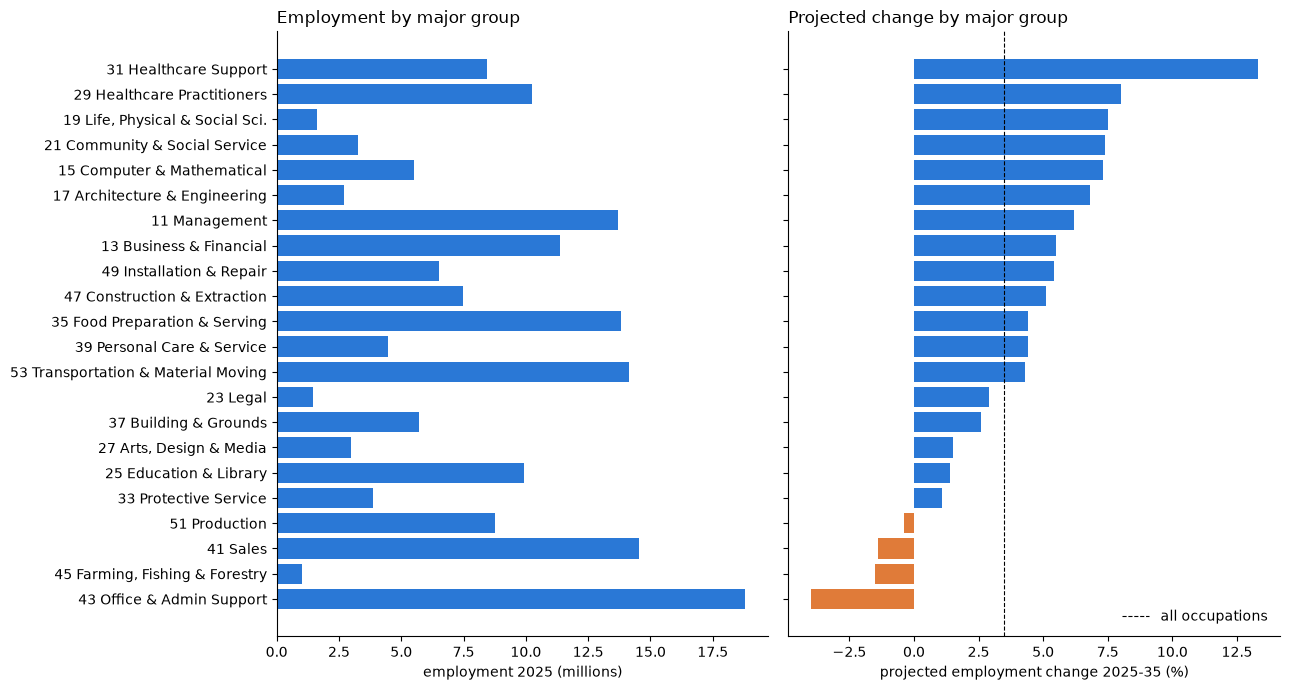

In [82]:
by_group = major_group_rows.copy()
by_group["label"] = by_group.index + " " + by_group.index.map(MAJOR_GROUPS)
by_group = by_group.sort_values("emp_change_pct")

fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True)
axes[0].barh(by_group["label"], by_group["emp_2025"] / 1000, color="#2a78d6")
axes[0].set_xlabel("employment 2025 (millions)")
axes[0].set_title("Employment by major group", loc="left")

colors = []
for value in by_group["emp_change_pct"]:
    if value < 0:
        colors.append("#e07b39")
    else:
        colors.append("#2a78d6")
axes[1].barh(by_group["label"], by_group["emp_change_pct"], color=colors)
axes[1].axvline(100 * (total_2035 - total_2025) / total_2025, color="k", linestyle="--", linewidth=0.8,
                label="all occupations")
axes[1].set_xlabel("projected employment change 2025-35 (%)")
axes[1].set_title("Projected change by major group", loc="left")
axes[1].legend(frameon=False)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "bls_by_major_group.png", dpi=150)
by_group[["label", "emp_2025", "emp_change_pct", "median_wage"]].sort_values("emp_change_pct", ascending=False).round(1)

**Entry requirements.** Education is ordinal, so it is shown in order. The share of occupations and the share of jobs
in each category differ when one kind of occupation is much larger than another.

,occupations,share_of_occupations,share_of_jobs,median_wage (unweighted median),emp_change_pct (employment-weighted)
education,,,,,
No formal educational credential,109,0.131,0.236,41220.0,2.337
High school diploma or equivalent,326,0.392,0.354,50080.0,1.961
Postsecondary nondegree award,51,0.061,0.063,60600.0,5.682
"Some college, no degree",7,0.008,0.025,46990.0,-3.184
Associate's degree,48,0.058,0.021,66985.0,4.911
Bachelor's degree,177,0.213,0.252,83680.0,5.651
Master's degree,40,0.048,0.023,88270.0,11.053
Doctoral or professional degree,73,0.088,0.027,103410.0,6.386


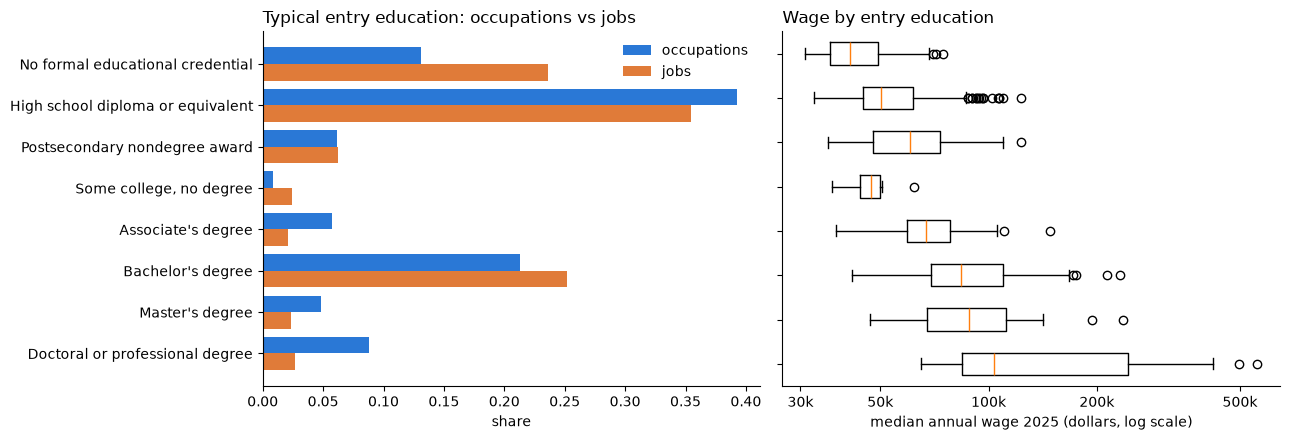

In [83]:
EDUCATION_ORDER = [
    "No formal educational credential",
    "High school diploma or equivalent",
    "Postsecondary nondegree award",
    "Some college, no degree",
    "Associate's degree",
    "Bachelor's degree",
    "Master's degree",
    "Doctoral or professional degree",
]
education_levels = []
for level in EDUCATION_ORDER:
    if level in set(occupations["education"]):
        education_levels.append(level)

all_jobs = occupations["emp_2025"].sum()
by_education = []
for level in education_levels:
    group = occupations[occupations["education"] == level]
    by_education.append({
        "education": level,
        "occupations": len(group),
        "share_of_occupations": len(group) / len(occupations),
        "share_of_jobs": group["emp_2025"].sum() / all_jobs,
        "median_wage (unweighted median)": group["median_wage"].median(),
        "emp_change_pct (employment-weighted)": weighted_mean(group["emp_change_pct"], group["emp_2025"]),
    })
by_education = pd.DataFrame(by_education).set_index("education")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
positions = np.arange(len(education_levels))
axes[0].barh(positions - 0.2, by_education["share_of_occupations"], height=0.4, color="#2a78d6", label="occupations")
axes[0].barh(positions + 0.2, by_education["share_of_jobs"], height=0.4, color="#e07b39", label="jobs")
axes[0].set_yticks(positions, education_levels)
axes[0].set_xlabel("share")
axes[0].set_title("Typical entry education: occupations vs jobs", loc="left")
axes[0].legend(frameon=False)

wages_by_level = []
for level in education_levels:
    wages_by_level.append(occupations.loc[occupations["education"] == level, "median_wage"].dropna())
try:
    axes[1].boxplot(wages_by_level, orientation="horizontal")  # matplotlib >= 3.10
except TypeError:
    axes[1].boxplot(wages_by_level, vert=False)
axes[1].set_yticks(range(1, len(education_levels) + 1), [])
axes[1].set_xscale("log")
axes[1].set_xticks([30000, 50000, 100000, 200000, 500000], ["30k", "50k", "100k", "200k", "500k"])
axes[1].minorticks_off()
axes[1].set_xlabel("median annual wage 2025 (dollars, log scale)")
axes[1].set_title("Wage by entry education", loc="left")
for ax in axes:
    ax.invert_yaxis()
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "bls_education_wage.png", dpi=150)
by_education.round(3)

In [84]:
# Relationships between the numeric variables (Spearman rank correlation, unweighted).
# Education is turned into its rank (0 = no formal credential ... 7 = doctoral degree).
education_rank = {}
for rank, level in enumerate(EDUCATION_ORDER):
    education_rank[level] = rank

variables = pd.DataFrame({
    "log_employment": np.log10(occupations["emp_2025"]),
    "emp_change_pct": occupations["emp_change_pct"],
    "openings_rate": occupations["openings"] / occupations["emp_2025"],
    "median_wage": occupations["median_wage"],
    "self_employed_pct": occupations["self_employed_pct"],
    "education_rank": occupations["education"].map(education_rank),
})
# Spearman = Pearson correlation of the ranks (pandas' method="spearman" needs scipy)
variables.rank().corr().round(2)

,log_employment,emp_change_pct,openings_rate,median_wage,self_employed_pct,education_rank
log_employment,1.00,0.19,0.10,-0.10,-0.27,-0.03
emp_change_pct,0.19,1.00,0.03,0.30,-0.05,0.31
openings_rate,0.10,0.03,1.00,-0.68,0.03,-0.53
median_wage,-0.10,0.30,-0.68,1.00,-0.04,0.73
self_employed_pct,-0.27,-0.05,0.03,-0.04,1.00,-0.10
education_rank,-0.03,0.31,-0.53,0.73,-0.10,1.00


### 5. Table 1.12: why BLS expects an occupation's share to change
Each row is one written reason, for one occupation, in one industry (or all industries). It starts with the type of
factor (demand change, productivity change, capital/labor substitution, ...) followed by whether the occupation's
**share of that industry's employment** increases or decreases, and why. This is a staffing-pattern change: an
occupation can lose share and still grow, if its industries grow. Some reasons name artificial intelligence.

In [85]:
factors = read_bls_table("Table 1.12")
factors["title"] = factors["title"].str.strip()
print("rows:", len(factors), "| occupations:", factors["code"].nunique(), "| industries:", factors["industry"].nunique())
print("rows for all industries combined:", (factors["industry"] == "Total, all industries").sum())
print("all codes are Table 1.2 line items:", factors["code"].isin(occupations["code"]).all())

# The factor type(s) come before the first dash; a row can name more than one type
factor_types = factors["factor"].str.split("-", n=1).str[0].str.strip()
type_counts = factor_types.str.split(", ").explode().str.lower().value_counts()
print("\nfactor types (a row can have more than one):")
print(type_counts.to_string())

# Direction: does the occupation's share increase or decrease?
factors["direction"] = factors["factor"].str.extract(r"share (increases|decreases)")[0]
print("\ndirection:", factors["direction"].value_counts(dropna=False).to_dict())

# Reasons that mention artificial intelligence
factors["mentions_ai"] = factors["factor"].str.contains(r"artificial intelligence|\bAI\b", case=True)
ai_rows = factors[factors["mentions_ai"]]
print("\nrows mentioning AI:", len(ai_rows), "| occupations:", ai_rows["code"].nunique(),
      "| direction:", ai_rows["direction"].value_counts().to_dict())
print("AI-mentioning occupations by major group:", ai_rows.drop_duplicates("code")["code"].str[:2].value_counts().to_dict())

rows: 935 | occupations: 447 | industries: 211
rows for all industries combined: 200
all codes are Table 1.2 line items: True

factor types (a row can have more than one):
factor
demand change                 486
productivity change           245
capital/labor substitution    117
occupational substitution      77
sourcing change                68

direction: {'decreases': 538, 'increases': 397}

rows mentioning AI: 54 | occupations: 48 | direction: {'decreases': 50, 'increases': 4}
AI-mentioning occupations by major group: {'27': 13, '43': 10, '15': 8, '41': 8, '13': 3, '29': 2, '11': 1, '23': 1, '25': 1, '31': 1}


In [86]:
# The occupations whose BLS reasons mention AI, with BLS's own projected change
ai_rows = ai_rows.copy()
ai_rows["is_decrease"] = ai_rows["direction"] == "decreases"
ai_occupations = ai_rows.groupby("code").agg(
    title=("title", "first"),
    ai_reasons=("factor", "size"),
    reasons_share_decreases=("is_decrease", "sum"),
)
ai_occupations = ai_occupations.join(occupations.set_index("code")[["emp_2025", "emp_change_pct"]])
ai_occupations.sort_values("emp_change_pct")

,title,ai_reasons,reasons_share_decreases,emp_2025,emp_change_pct
code,,,,,
43-9021,Data entry keyers,1,1,131.8,-25.5
13-1032,"Insurance appraisers, auto damage",1,1,13.5,-8.7
27-3011,Broadcast announcers and radio disc jockeys,2,2,21.8,-7.6
15-1251,Computer programmers,1,1,110.8,-7.3
43-6014,"Secretaries and administrative assistants, except legal, medical, ...",1,1,1889.8,-6.0
43-9061,"Office clerks, general",1,1,2600.0,-6.0
13-1031,"Claims adjusters, examiners, and investigators",1,1,376.1,-5.5
43-4051,Customer service representatives,1,1,2666.0,-5.3
43-6012,Legal secretaries and administrative assistants,1,1,157.6,-5.2


In [87]:
# Projected change for occupations with and without an AI reason (BLS data only)
has_ai_reason = occupations["code"].isin(ai_rows["code"])
has_any_reason = occupations["code"].isin(factors["code"])
groups = {
    "AI named as a reason": has_ai_reason,
    "other reasons only": has_any_reason & ~has_ai_reason,
    "no reason listed": ~has_any_reason,
}
comparison = []
for name, in_group in groups.items():
    group = occupations[in_group]
    comparison.append({
        "group": name,
        "occupations": len(group),
        "jobs (thousands)": group["emp_2025"].sum(),
        "median emp_change_pct (unweighted)": group["emp_change_pct"].median(),
        "emp_change_pct (employment-weighted)": weighted_mean(group["emp_change_pct"], group["emp_2025"]),
    })
pd.DataFrame(comparison).round(1)

,group,occupations,jobs (thousands),median emp_change_pct (unweighted),emp_change_pct (employment-weighted)
0,AI named as a reason,48,18711.6,-0.3,-1.7
1,other reasons only,399,92932.4,1.8,4.4
2,no reason listed,384,58623.2,3.5,3.7


### 6. Summary: key trends, merging, and outliers

**General trends**
- **Release:** BLS Employment Projections **2025-35** (2025 employment and wages). The project docs name the 2024-34
  edition, so DATA-DICTIONARY §3 `emp_change_pct_2024_34` should become `emp_change_pct_2025_35`.
- **Size:** 831 detailed occupations (line items) plus 281 summary rows. They hold 170.3 million jobs, projected to
  grow **3.5%** by 2035.
- **Employment is very uneven:**
  - The median occupation has about 50,000 jobs.
  - The 10 largest occupations hold 20% of all jobs.
  - So unweighted and employment-weighted results differ: the mean projected change is 2.1% per occupation but 3.5%
    per job.
- **Projected change:**
  - 28% of occupations (25% of jobs) are projected to decline.
  - Growth is concentrated in healthcare: Healthcare Support +13.3%, Practitioners +8.0%.
  - Office & Administrative Support (-4.0%), Farming (-1.5%), Sales (-1.4%) and Production (-0.4%) shrink.
- **Entry education shapes wages:**
  - Spearman 0.73 between entry education and median wage.
  - Higher-education occupations are also projected to grow faster (0.31).
  - Occupations needing no formal credential are 13% of occupations but 24% of jobs; doctoral or professional
    occupations are 9% of occupations but 3% of jobs.
  - Unweighted analyses therefore over-represent high-education occupations.
- **BLS already names AI as a driver:**
  - 54 of the 935 Table 1.12 reasons, covering **48 occupations**, mention artificial intelligence. 50 of the 54 say
    the occupation's share of an industry's employment decreases (a staffing-pattern change, not
    necessarily falling employment).
  - They cluster in Arts & Media (13), Office & Admin (10), Computer (8) and Sales (8).
  - These 48 occupations are projected to change by -1.7% (employment-weighted), against +4.4% for occupations with
    other reasons.

**Merging**
- **No crosswalk is needed.** BLS codes are SOC 2018: 819 of the 831 line items are SOC 2018 detailed codes.
- **12 BLS combined codes** stand for 28 SOC 2018 occupations, e.g. `31-1120` Home health and personal care aides
  (4.7 million jobs) = `31-1121` + `31-1122`.
  - A code-prefix rule does not find them; the mapping in section 3 does (same broad group).
  - A join on `soc2018` alone silently drops these occupations.
- **Not in BLS at all:** 19 military codes and Legislators (`11-1031`).
- **Index-table codes that can find a BLS row:**
  - Eloundou 797 of 798 (25 through a combined code; Legislators missing).
  - AIOE 800 of 800 (27 through a combined code).
  - Frey-Osborne 699 of 699 (24 through a combined code).
- **Join on codes, never titles.** Titles are lower-case BLS wording, not SOC wording, and three summary rows repeat
  their only line item's title.

**Outliers and data quality**
- **No defects:**
  - no duplicate codes
  - no out-of-range values
  - every derived column recomputes within rounding (0.1 thousand jobs)
  - line items sum to the total
  - Tables 1.1, 1.3-1.6 and 1.10 match Table 1.2 exactly; the four top-30 tables are exactly the top 30 of Table 1.2
- **Structural blanks ("—"):**
  - 6 occupations have no wage (actors, dancers, musicians, disc jockeys, other entertainers, fishing and hunting
    workers). BLS publishes no annual wage for them.
  - 197 have no self-employment share.
  - Summary rows have no entry requirements.
- **A reading trap:** pandas treats the text "None" as missing by default. That blanks the real answer "None" for
  716 experience and 321 training values. Read with `keep_default_na=False, na_values=["—", ""]`.
- **Percent change is noisy for small occupations.** Published from unrounded figures, it differs from the rounded
  employment by up to 7.3 points overall but under 1 point for occupations with 10,000+ jobs.
- **Outliers are real, not errors.**
  - Physicians' wages reach $559,030.
  - Huge occupations (home health aides, retail salespersons) dominate employment.
  - Use log scales and medians; keep them in.
- **Wages cover employees only** (OEWS excludes the self-employed), so they are less representative where
  self-employment is high (up to 95%).

**Decisions for the rest of the project**
1. **Source:** Table 1.2 line items only. Read with `keep_default_na=False, na_values=["—", ""]`, drop footnote rows, and
   rename the headers once. The other sheets add nothing the project needs:
   - extracts of Table 1.2, links only, or STEM totals
   - Table 1.10's separations, unless openings become a question
2. **Column name:** `emp_change_pct_2025_35`, and update DATA-DICTIONARY §3.
3. **Join rule:**
   - Map SOC 2018 → BLS code with the section 3 mapping, and keep a `bls_combined_code` flag.
   - A rate (percent change, wage) can be copied to each child of a combined code. Employment cannot: split it
     between the children, or the weights double-count.
4. **Weights:** use `emp_2025` as the employment weight wherever §4.3 asks for a weighted result, and always report
   unweighted alongside.
5. **Projections check (Milestone 3, stretch):**
   - Use `emp_change_pct_2025_35`, with occupations under 10,000 jobs flagged, because their percent change is noisy.
   - Flag the 48 occupations whose BLS reasons cite AI (`bls_ai_factor`). Their projections already assume AI
     effects, so any comparison of exposure with BLS change is partly circular for them.
6. **Wage, education and self-employment** are clean and available as descriptive context, with the employee-only
   caveat for wages.

**Limitations**
- **Projections, not observations:** these are BLS model outputs, national only, with no regional or demographic
  detail. The fairness lens in the brief needs CPS demographic data, which is not in `data/raw/`.
- **Table 1.12 is free text:** it covers only 447 occupations, and AI mentions are found by keyword (`artificial
  intelligence` or `AI`), so paraphrases would be missed.
- **Vintage:** the file is the 2025-35 edition, newer than the 2024-34 edition the project docs name.

### EDA techniques applied (BLS)

| Technique | What it was used for | Section |
|---|---|---|
| Sheet inventory and version check | Titles, data rows and footnotes per sheet; 2025-35 vintage | 1 |
| Header cleaning and hierarchy parsing | Short column names; title indentation → level | 1 |
| Missing-value profile by row type | Structural "—" blanks vs real gaps; the "None" parsing trap | 1, 2 |
| Duplicate and range checks | Codes, titles, employment, percentages, wages | 2 |
| Recomputing derived columns | Change, percent change, shares, openings, separations | 2 |
| Cross-table reconciliation | Tables 1.1, 1.3-1.6, 1.10 against Table 1.2; top-30 lists | 2 |
| 1.5×IQR rule on raw and log scale | Outliers in skewed variables | 2 |
| Set comparison and code mapping | BLS line items vs SOC 2018; combined codes; index-table code coverage | 3 |
| Unweighted vs employment-weighted statistics | Means, shares, decline rates | 4 |
| Histograms (log scale where skewed) | Employment, change, wage, self-employment | 4 |
| Bar charts by major group and education | Employment, change, occupations vs jobs | 4 |
| Boxplot by category | Wage by entry education | 4 |
| Spearman rank correlation | Relationships between BLS variables | 4 |
| Text parsing | Factor types, direction and AI mentions in Table 1.12 | 5 |

## Result and retained limitations

- The crosswalk and three index files are well-formed: no nulls, duplicate codes or out-of-range values, and the
  Frey-Osborne appendix parses to exactly 702 rows with no gaps in rank. The six O\*NET 30.3 files are
  equally clean: no duplicates, no out-of-range or missing headline values.
  The BLS projections workbook is also clean: every derived column and every extract table reconciles
  with Table 1.2.
- The indices measure different things on different scales (share of tasks, z-score, bimodal
  probability), so only rank-based comparisons between them are meaningful.
- **Issues carried forward to the interim EDA and later tasks:**
  1. Frey-Osborne lists 17 occupations under broad or SOC 2000 codes that the crosswalk cannot match,
     mostly large, low-risk healthcare and education jobs (Physicians, Registered Nurses, Postsecondary Teachers).
  2. AIOE's `19-1020` Biologists is a broad code with no crosswalk row.
  3. `data/frey_osborne_probabilities.csv` is an incomplete 653-row copy of the 702-row appendix; the
     pipeline correctly uses the PDF.
  4. Frey-Osborne titles lose their spaces in PDF extraction, so joins must use codes, never titles.
  5. Eloundou needs no crosswalk: all 798 of its six-digit codes are valid SOC 2018 codes.
  6. O\*NET has no ratings for 29 occupations, all of them rated by Eloundou. That leaves **24 six-digit Eloundou
     codes without O\*NET features**, and three partly rated six-digit codes where Eloundou's average includes an
     occupation the features leave out.
  7. **Job Zone 1 does not occur in O\*NET 30.3** (values 2-5). DATA-DICTIONARY §3 lists `job_zone` as 1-5 and should
     be updated.
  8. O\*NET aggregates need care:
     - use IM, not LV (near-duplicates)
     - sign-align the work-context groups that mix opposite elements
     - expect strong collinearity (two components explain 62% of the variance)
  9. About 30% of occupations' O\*NET ratings were updated after the 27.2 release Eloundou used. The taxonomy is
     identical.
  10. Task Statements and Task Ratings are not in `data/raw/`, so O\*NET task-level data is not profiled here.
      Suggested follow-up issue: add and profile them, since Eloundou's scores are built from those tasks.
  11. The BLS file is the **2025-35** projections edition, not the 2024-34 one named in the project docs.
      DATA-DICTIONARY §3 `emp_change_pct_2024_34` should become `emp_change_pct_2025_35`.
  12. BLS publishes **12 combined codes** standing for 28 SOC 2018 occupations (e.g. Home health and personal care
      aides). A join on `soc2018` needs the mapping in Part 6, and employment must be split, not copied, across a
      combined code's children.
  13. Read `occupation.xlsx` with `keep_default_na=False, na_values=["—", ""]`: pandas' defaults turn the real answer
      "None" (no experience / training needed) into a blank.
  14. BLS cites AI as a reason for 48 occupations' projected change, almost always lowering their share of industry
      employment. Any later comparison of exposure with BLS projections is partly circular for those occupations.

This notebook describes the inputs only; it does not transform them. **Next:**
[`eda_interim.ipynb`](eda_interim.ipynb) checks what the Milestone 1 roll-up and crosswalk did to these files.